# Deteksi Hoaks IndoBERT + BERTopic (Final V4 DBCS)

Notebook ini menjalankan klasifikasi hoax berbasis IndoBERT dan analisis topik berbasis BERTopic. Pipeline IndoBERT dipertahankan sebagai classifier utama, sedangkan BERTopic berjalan setelah training untuk membaca struktur topik pada corpus training pra-oversampling. Evaluasi tambahan mencakup DBCV, coherence, outlier rate, c-TF-IDF, keyword coverage, topic exclusivity, category exclusivity, dan ringkasan angka akhir.


In [1]:
# ================== SEL 1 -- Instalasi Library dan Import Dependensi ==================
# Menyiapkan seluruh dependensi yang dibutuhkan untuk pipeline deteksi hoaks berbasis IndoBERT.
# - KaggleHub: mengunduh dataset training dari Kaggle
# - Transformers & PyTorch: framework fine-tuning dan inference model IndoBERT
# - Scikit-learn: utilitas split data dan perhitungan metrik evaluasi
# - Datasets (HuggingFace): konversi DataFrame menjadi format Dataset untuk training
# Setelah seluruh pustaka berhasil diimpor, notebook siap melanjutkan ke tahap konfigurasi dan pemrosesan data.
# ======================================================================================
# Menjalankan perintah shell instalasi paket: kagglehub transformers datasets accelerate sentencepiece
#   scikit-learn seaborn
!pip install -q kagglehub transformers datasets accelerate sentencepiece scikit-learn seaborn

# Impor modul: gc
import gc
# Impor modul: json sebagai _json
import json as _json
# Impor modul: os
import os
# Impor modul: random
import random
# Impor modul: shutil
import shutil
# Impor modul: warnings
import warnings
# Impor dari `pathlib`: Path
from pathlib import Path
# Impor dari `dataclasses`: dataclass
from dataclasses import dataclass
# Impor dari `typing`: Any, Dict, List, Tuple
from typing import Any, Dict, List, Tuple

# Memanggil `warnings.filterwarnings(...)`
warnings.filterwarnings("ignore")

# Impor modul: numpy sebagai np
import numpy as np
# Impor modul: pandas sebagai pd
import pandas as pd
# Impor modul: matplotlib.pyplot sebagai plt
import matplotlib.pyplot as plt
# Impor modul: seaborn sebagai sns
import seaborn as sns

# Impor dari `sklearn.model_selection`: train_test_split
from sklearn.model_selection import train_test_split
# Impor dari `sklearn.metrics`: accuracy_score, precision_recall_fscore_support,
#   classification_report, confusion_matrix, f1_score, roc_curve, auc, precision_score, recall_score
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_curve,
    auc,
    precision_score,
    recall_score,
)

# Impor modul: torch
import torch
# Impor modul: transformers
import transformers
# Impor modul: kagglehub
import kagglehub
# Impor dari `datasets`: Dataset
from datasets import Dataset
# Impor dari `transformers`: AutoTokenizer, AutoModelForSequenceClassification,
#   DataCollatorWithPadding, TrainingArguments, Trainer, set_seed
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed,
)

# Workaround kompatibilitas: torchvision versi baru menghapus kelas VideoReader dari
# torchvision.io, sehingga formatter torch pada library `datasets` bisa gagal (ImportError)
# saat memformat batch/tensor -- padahal dataset pada notebook ini murni berbasis teks
# dan tidak memerlukan fitur torchvision sama sekali.
# Blok try: menjalankan kode di bawah dengan penanganan except
try:
    # Impor dari `datasets`: config sebagai _hf_datasets_config
    from datasets import config as _hf_datasets_config
    # Menetapkan `_hf_datasets_config.TORCHVISION_AVAILABLE` = False
    _hf_datasets_config.TORCHVISION_AVAILABLE = False
# Penanganan except untuk Exception
except Exception:
    pass

# Memanggil `print(...)`
print("Semua library berhasil di-import.")
# Memanggil `print(...)`
print(f"   PyTorch       : {torch.__version__}")
# Memanggil `print(...)`
print(f"   Transformers  : {transformers.__version__}")
# Memanggil `print(...)`
print(f"   GPU tersedia  : {torch.cuda.is_available()}")
# Percabangan: jika torch.cuda.is_available()
if torch.cuda.is_available():
    # Memanggil `print(...)`
    print(f"   GPU           : {torch.cuda.get_device_name(0)}")
    # Memanggil `print(...)`
    print(f"   VRAM total    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Semua library berhasil di-import.
   PyTorch       : 2.11.0+cu128
   Transformers  : 5.12.1
   GPU tersedia  : True
   GPU           : Tesla T4
   VRAM total    : 15.6 GB


In [2]:
# ================== SEL 2 -- Instalasi Dependensi BERTopic ==================
# Menyiapkan pustaka topic modeling yang akan dijalankan pada tahap post-training.
# - BERTopic: framework utama topic modeling berbasis embedding
# - Sentence-Transformers: model embedding multibahasa untuk representasi dokumen
# - UMAP & HDBSCAN: reduksi dimensi dan clustering berbasis densitas
# - Gensim: dipakai untuk perhitungan coherence topik
# Instalasi ini tidak memengaruhi proses training maupun bobot classifier IndoBERT.
# ============================================================================
# Menjalankan perintah shell instalasi paket: bertopic sentence-transformers umap-learn hdbscan gensim
!pip install -q bertopic sentence-transformers umap-learn hdbscan gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 35.9 MB/s eta 0:00:00


**Catatan BERTopic:** BERTopic dijalankan setelah training classifier IndoBERT selesai. Tahap ini tidak mengubah bobot model, tokenizer, split data, threshold classifier, atau metrik evaluasi IndoBERT.


In [3]:
# ================== SEL 3 -- Konfigurasi Hyperparameter Training ==================
# Mendefinisikan seluruh parameter konfigurasi training IndoBERT dan pengaturan reproducibility.
# - Config (dataclass): menyimpan path dataset, nama model, dan hyperparameter training
# - Seed & cuDNN: mengatur seed global dan mode deterministic untuk reproducibility antar-run
# - Device: menentukan penggunaan GPU/CPU sesuai ketersediaan CUDA
# Objek konfigurasi ini menjadi acuan bagi seluruh sel pemrosesan data dan training di tahap berikutnya.
# ==================================================================================
@dataclass
# Definisi class `Config`
class Config:
    # Path Dataset
    # Variabel/field `path_cnn` (tipe str) = '/content/dataset/CNN.csv'
    path_cnn    : str   = "/content/dataset/CNN.csv"
    # Variabel/field `path_detik` (tipe str) = '/content/dataset/Detik.csv'
    path_detik  : str   = "/content/dataset/Detik.csv"
    # Variabel/field `path_kompas` (tipe str) = '/content/dataset/Kompas.csv'
    path_kompas : str   = "/content/dataset/Kompas.csv"
    # Variabel/field `path_tbh` (tipe str) = '/content/dataset/TurnBackHoax.csv'
    path_tbh    : str   = "/content/dataset/TurnBackHoax.csv"
    # Model
    # Variabel/field `model_name` (tipe str) = 'indolem/indobert-base-uncased'
    model_name       : str   = "indolem/indobert-base-uncased"
    # Hyperparameter Training
    # Variabel/field `max_length` (tipe int) = 256
    max_length       : int   = 256    # Max token length
    # Variabel/field `train_batch_size` (tipe int) = 96
    train_batch_size : int   = 96     # Optimal untuk GPU 15GB
    # Variabel/field `eval_batch_size` (tipe int) = 384
    eval_batch_size  : int   = 384    # Evaluasi cepat
    # Variabel/field `grad_accumulation` (tipe int) = 2
    grad_accumulation: int   = 2
    # Variabel/field `learning_rate` (tipe float) = 2e-05
    learning_rate    : float = 2e-5
    # Variabel/field `weight_decay` (tipe float) = 0.01
    weight_decay     : float = 0.01
    # Variabel/field `num_epochs` (tipe int) = 3
    num_epochs       : int   = 3
    # Variabel/field `seed` (tipe int) = 42
    seed             : int   = 42
    # Threshold inferensi default
    # Variabel/field `threshold_default` (tipe float) = 0.5
    threshold_default: float = 0.5
    # Output
    # Variabel/field `output_dir` (tipe str) = 'indobert_hoax_model_v3'
    output_dir       : str   = "indobert_hoax_model_v3"

# Menetapkan `cfg` = memanggil `Config(...)`
cfg = Config()
# Menetapkan `THRESHOLD_DEFAULT` = memanggil `float(...)`
THRESHOLD_DEFAULT = float(cfg.threshold_default)
# Memanggil `set_seed(...)`
set_seed(cfg.seed)

# Membantu meningkatkan reproducibility pada operasi CUDA
# Menetapkan `torch.backends.cudnn.deterministic` = True
torch.backends.cudnn.deterministic = True
# Menetapkan `torch.backends.cudnn.benchmark` = False
torch.backends.cudnn.benchmark     = False

# Menetapkan `device` = ekspresi kondisional -> 'cuda' if torch.cuda.is_available() else 'cpu'
device = "cuda" if torch.cuda.is_available() else "cpu"
# Memanggil `print(...)`
print(f"Device aktif           : {device}")
# Memanggil `print(...)`
print(f"cudnn.deterministic    : {torch.backends.cudnn.deterministic}")
# Memanggil `print(...)`
print(f"cudnn.benchmark        : {torch.backends.cudnn.benchmark}")
# Memanggil `print(...)`
print(f"train_batch_size       : {cfg.train_batch_size}")
# Memanggil `print(...)`
print(f"eval_batch_size        : {cfg.eval_batch_size}")
# Memanggil `print(...)`
print(f"Efektif batch size     : {cfg.train_batch_size * cfg.grad_accumulation}")
# Memanggil `print(...)`
print(f"max_length             : {cfg.max_length}")
# Memanggil `print(...)`
print(f"threshold_default      : {THRESHOLD_DEFAULT:.2f}")

Device aktif           : cuda
cudnn.deterministic    : True
cudnn.benchmark        : False
train_batch_size       : 96
eval_batch_size        : 384
Efektif batch size     : 192
max_length             : 256
threshold_default      : 0.50


In [4]:
# ================== SEL 4 -- Konfigurasi BERTopic (Post-Training) ==================
# Mendefinisikan parameter Topic Modeling yang dijalankan setelah training classifier IndoBERT selesai.
# - Flag aktivasi: mengatur AKTIFKAN_BERTOPIC, AKTIFKAN_UNGGAH_BERTOPIC, dan AKTIFKAN_GUIDED
# - Parameter UMAP & HDBSCAN: mengatur reduksi dimensi dan sensitivitas clustering
# - Parameter outlier reduction: mengatur strategi dan threshold pengurangan dokumen outlier
# Konfigurasi ini murni untuk tahap topic modeling dan tidak mengubah proses training, bobot, atau evaluasi IndoBERT.
# ===================================================================================
# Menetapkan `AKTIFKAN_BERTOPIC` = True
AKTIFKAN_BERTOPIC        = True
# Menetapkan `AKTIFKAN_UNGGAH_BERTOPIC` = False
AKTIFKAN_UNGGAH_BERTOPIC = False
# Menetapkan `AKTIFKAN_GUIDED` = False
AKTIFKAN_GUIDED          = False  # Label kategori tetap dihitung pada evaluasi, bukan dipaksa saat fit

# Menetapkan `DIR_OUTPUT_BERTOPIC` = '/content/bertopic_model_v3'
DIR_OUTPUT_BERTOPIC      = "/content/bertopic_model_v3"
# Menetapkan `MODEL_EMBEDDING_BERTOPIC` = 'sentence-transformers/paraphrase-multilingual-
#   MiniLM-L12-v2'
MODEL_EMBEDDING_BERTOPIC = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
# Menetapkan `UKURAN_BATCH_EMBED` = 32
UKURAN_BATCH_EMBED       = 32
# Menetapkan `UKURAN_BATCH_EKSTRAK` = 128
UKURAN_BATCH_EKSTRAK     = 128
# Menetapkan `MAKS_DOKUMEN_BERTOPIC` = None
MAKS_DOKUMEN_BERTOPIC    = None
# Menetapkan `REPO_TOPIC_HF` = 'fjrmhri/deteksi_hoaks_bertopic'
REPO_TOPIC_HF            = "fjrmhri/deteksi_hoaks_bertopic"
# Menetapkan `BERTOPIC_HITUNG_PROB` = True
BERTOPIC_HITUNG_PROB     = True
# Menetapkan `NR_TOPIK` = 80
NR_TOPIK                 = 80
# Menetapkan `BERTOPIC_UMAP_N_NEIGHBORS` = 12
BERTOPIC_UMAP_N_NEIGHBORS = 12
# Menetapkan `BERTOPIC_UMAP_N_COMPONENTS` = 5
BERTOPIC_UMAP_N_COMPONENTS = 5
# Menetapkan `BERTOPIC_UMAP_MIN_DIST` = 0.0
BERTOPIC_UMAP_MIN_DIST = 0.0
# Menetapkan `BERTOPIC_HDBSCAN_MIN_CLUSTER_SIZE` = 12
BERTOPIC_HDBSCAN_MIN_CLUSTER_SIZE = 12
# Menetapkan `BERTOPIC_HDBSCAN_MIN_SAMPLES` = 2
BERTOPIC_HDBSCAN_MIN_SAMPLES = 2
# Menetapkan `BERTOPIC_HDBSCAN_SELECTION` = 'leaf'
BERTOPIC_HDBSCAN_SELECTION = "leaf"
# Menetapkan `BERTOPIC_VECTORIZER_MIN_DF` = 3
BERTOPIC_VECTORIZER_MIN_DF = 3
# Menetapkan `BERTOPIC_VECTORIZER_MAX_DF` = 0.75
BERTOPIC_VECTORIZER_MAX_DF = 0.75
# Menetapkan `BERTOPIC_REDUCE_OUTLIERS` = True
BERTOPIC_REDUCE_OUTLIERS = True
# Menetapkan `BERTOPIC_REDUCE_OUTLIERS_THRESHOLD` = 0.1
BERTOPIC_REDUCE_OUTLIERS_THRESHOLD = 0.10
# Menetapkan `BERTOPIC_AKTIFKAN_MERGE_MANUAL` = False
BERTOPIC_AKTIFKAN_MERGE_MANUAL = False

# Menetapkan `SEED_BERTOPIC` = cfg.seed
SEED_BERTOPIC = cfg.seed

# Memanggil `print(...)`
print(f"BERTopic aktif         : {AKTIFKAN_BERTOPIC}")
# Memanggil `print(...)`
print(f"Guided Topic Modeling  : {AKTIFKAN_GUIDED}")
# Memanggil `print(...)`
print(f"Hitung probabilitas    : {BERTOPIC_HITUNG_PROB}")
# Memanggil `print(...)`
print(f"nr_topics              : {NR_TOPIK}")
# Memanggil `print(...)`
print(f"Output dir             : {DIR_OUTPUT_BERTOPIC}")

BERTopic aktif         : True
Guided Topic Modeling  : False
Hitung probabilitas    : True
nr_topics              : 80
Output dir             : /content/bertopic_model_v3


## Kategori Tematik dan `seed_topic_list`

Daftar kata kunci per kategori tetap disiapkan sebagai sumber label/evaluasi topik. Pada konfigurasi terbaru, guided topic modeling dimatikan (`AKTIFKAN_GUIDED=False`), sehingga daftar ini tidak dipaksakan saat fit BERTopic.


In [5]:
# ================== SEL 5 -- Definisi Kategori Tematik (Sinkronisasi) ==================
# Mendefinisikan daftar kategori berita beserta kata kunci terkait untuk keperluan pelabelan topik.
# - PETA_KATEGORI_SHARED: daftar pasangan kategori dan himpunan kata kunci, disinkronkan dengan backend/app.py
# - daftar_tema_utama: transformasi kata kunci ke format seed_topic_list BERTopic
# Data kategori ini dipakai pada tahap evaluasi/pelabelan topik dan sebagai seed topic list bila guided topic modeling diaktifkan.
# =======================================================================================

# Menetapkan `PETA_KATEGORI_SHARED` = literal list berisi 14 elemen
PETA_KATEGORI_SHARED = [
    ("Kriminal & Hukum", {
        "polisi", "tersangka", "pengadilan", "hukum", "penjara", "korupsi",
        "kpk", "pembunuhan", "penipuan", "sidang", "vonis", "kriminal",
        "penyidikan", "jaksa", "hakim", "ditangkap", "ditahan", "terdakwa",
        "dakwaan", "kejaksaan", "mahkamah", "peradilan", "pidana", "perdata",
        "polri", "rutan", "lapas", "napi", "tahanan", "bui", "sel",
        "persidangan", "putusan", "hukuman", "denda", "banding", "kasasi",
        "penggeledahan", "penyitaan", "rekonstruksi", "otopsi", "visum",
        "tipikor", "suap", "gratifikasi", "pencucian", "pemalsuan",
        "penganiayaan", "pencurian", "perampokan", "narkoba", "narkotika",
        "pelecehan", "pemerkosaan", "kejahatan", "pelaku", "korban kriminal",
    }),
    ("Politik", {
        "pemilu", "pilkada", "dpr", "partai", "kampanye", "bawaslu", "kpu",
        "pilpres", "caleg", "koalisi", "oposisi", "legislasi", "debat",
        "konstitusi", "suara", "demokrat", "golkar", "pdip", "gerindra",
        "pks", "dpd", "mpr", "fraksi", "legislatif", "senator",
        "dprd", "pilwalkot", "pilgub", "pilbup", "capres", "cawapres",
        "paslon", "petahana", "tim sukses", "quick count", "real count",
        "rekap suara", "money politics", "politik uang", "black campaign",
        "kampanye hitam", "hoaks politik", "propaganda", "agitasi",
        "referendum", "demokrasi", "oligarki", "populisme", "nasionalisme",
        "pkb", "ppp", "pan", "nasdem", "hanura", "perindo", "psi",
        "pemilih", "suara rakyat", "kebijakan publik", "anggaran negara",
    }),
    ("Nasional & Pemerintahan", {
        "kementerian", "menteri", "kebijakan", "asn", "pns", "pemerintah",
        "presiden", "ibukota", "otonomi", "daerah", "regulasi", "proyek",
        "pembangunan", "gubernur", "bupati", "walikota", "dprd", "pemda",
        "anggaran", "apbn", "apbd", "perpres", "perda", "kabinet",
        "wapres", "jokowi", "prabowo",
        "sekretariat", "lembaga", "badan", "komisi", "dirjen", "direktorat",
        "keppres", "inpres", "pp", "uu", "ruu", "peraturan", "undang-undang",
        "ibu kota nusantara", "ikn", "brin", "bpk", "bpn", "bps",
        "kemendag", "kemenhub", "kemenkes", "kemendikbud", "kementan",
        "aparatur", "birokrasi", "reformasi birokrasi", "e-government",
        "pengadaan", "tender", "proyek nasional", "infrastruktur nasional",
        "bansos", "bantuan sosial", "subsidi", "blt", "pkh",
    }),
    ("Ekonomi & Bisnis", {
        "ekonomi", "saham", "investasi", "inflasi", "bank", "keuangan",
        "pajak", "ihsg", "umkm", "harga", "pasar", "ekspor", "impor",
        "startup", "bisnis", "perdagangan", "rupiah", "dolar", "kurs",
        "bank indonesia", "ojk", "bumn", "swasta", "perusahaan", "modal", "aset",
        "defisit", "surplus", "neraca", "pdb", "gdp",
        "inflasi", "deflasi", "resesi", "stagflasi", "suku bunga",
        "kredit", "pinjaman", "utang", "obligasi", "saham", "dividen",
        "bursa efek", "bei", "bursa", "trading", "trader", "stock market",
        "market cap", "kapitalisasi pasar", "pasar modal", "mata uang",
        "pertumbuhan ekonomi", "kemiskinan", "pengangguran", "lapangan kerja",
        "upah", "gaji", "phk", "tenaga kerja", "buruh", "pekerja",
        "industri", "manufaktur", "produksi", "ekspansi", "merger",
        "akuisisi", "ipo", "go public", "e-commerce", "marketplace",
        "fintech", "kripto", "bitcoin", "blockchain", "digital economy",
        "harga bahan pokok", "sembako", "beras", "minyak goreng", "bbm",
    }),
    ("Kesehatan", {
        "kesehatan", "penyakit", "dokter", "virus", "vaksin",
        "obat", "bpjs", "pandemi", "medis", "gejala", "terapi", "pasien",
        "klinis", "covid", "kemenkes", "epidemi", "wabah", "imunisasi",
        "apotek", "farmasi", "faskes", "puskesmas", "nakes",
        "rumah sakit", "rs", "poliklinik", "igd", "icu", "rawat inap",
        "rawat jalan", "operasi", "bedah", "diagnosa", "resep",
        "kanker", "diabetes", "hipertensi", "jantung", "stroke",
        "dbd", "malaria", "tbc", "hiv", "aids", "hepatitis",
        "mpox", "cacar", "flu", "demam", "batuk", "sesak napas",
        "lockdown", "karantina", "isolasi", "klaster", "herd immunity",
        "booster", "dosis", "suntik", "vaksinasi", "pfizer", "sinovac",
        "herbal", "jamu", "suplemen", "vitamin", "nutrisi", "gizi",
        "hamil", "kehamilan", "bayi", "ibu hamil", "melahirkan", "persalinan",
        "kandungan", "janin", "rahim", "usg", "ultrasonografi", "prenatal",
        "postnatal", "antenatal", "neonatal", "pregnancy", "pregnant",
        "childbirth", "delivery", "maternal", "maternity", "obgyn", "obstetri",
        "stunting", "gizi buruk", "obesitas", "kesehatan jiwa",
    }),
    ("Teknologi & Sains", {
        "teknologi", "internet", "aplikasi", "digital", "siber", "hacker",
        "inovasi", "satelit", "algoritma", "data", "ai", "kecerdasan",
        "buatan", "software", "hardware", "smartphone", "kominfo", "server",
        "cloud", "robot",
        "artificial intelligence", "machine learning", "deep learning",
        "big data", "iot", "internet of things", "5g", "metaverse",
        "virtual reality", "vr", "augmented reality", "ar",
        "keamanan siber", "cybersecurity", "ransomware", "phishing",
        "kebocoran data", "privasi digital", "enkripsi", "firewall",
        "coding", "programming", "developer", "startup teknologi",
        "komputasi", "prosesor", "chip", "semikonduktor",
        "drone", "luar angkasa", "antariksa", "space", "space science",
        "planet", "bumi", "matahari", "bulan", "bintang", "tata surya",
        "solar system", "astronomi", "astronomy", "nasa", "roket", "wahana",
        "lapan", "brin",
        "riset", "penelitian", "jurnal", "ilmiah", "laboratorium",
    }),
    ("Bencana & Cuaca", {
        "gempa", "banjir", "cuaca", "bmkg", "tsunami", "longsor", "erupsi",
        "badai", "evakuasi", "korban", "mitigasi", "iklim", "hujan", "angin",
        "kebakaran", "bencana", "bnpb", "bpbd", "kekeringan", "rob", "topan",
        "bencana alam", "force majeure", "tanah bergerak", "abrasi",
        "angin puting beliung", "tornado", "siklon", "hujan es",
        "banjir bandang", "banjir rob", "banjir lahar", "awan panas",
        "gunung berapi", "vulkanik", "aktivitas seismik", "magnitudo",
        "skala richter", "peringatan dini", "sirine", "tsunami warning",
        "pengungsian", "shelter", "posko", "bantuan bencana",
        "cuaca ekstrem", "el nino", "la nina", "perubahan iklim",
    }),
    ("Olahraga", {
        "olahraga", "sepakbola", "futsal", "basket", "bulutangkis", "atlet",
        "turnamen", "medali", "piala", "fifa", "aff", "liga", "stadion",
        "pertandingan", "klub", "pssi", "pbsi", "olimpiade",
        "voli", "tenis", "badminton", "pemain", "pelatih",
        "sea games", "asian games", "world cup", "euro", "copa",
        "premier league", "serie a", "la liga", "bundesliga", "liga 1",
        "timnas", "persib", "persija", "arema", "bali united",
        "gol", "kartu merah", "kartu kuning", "offside", "penalti",
        "skor", "klasemen", "degradasi", "promosi", "transfer pemain",
        "sprint", "maraton", "lari", "renang", "senam", "tinju", "mma",
        "e-sports", "gaming kompetitif", "esports",
    }),
    ("Keamanan & Pertahanan", {
        "militer", "tni", "angkatan darat", "angkatan laut", "angkatan udara",
        "tentara", "prajurit", "pasukan", "batalyon", "komando",
        "pertahanan", "senjata", "amunisi", "peluru", "meriam", "tank",
        "pesawat tempur", "kapal perang", "kapal selam", "frigate",
        "operasi militer", "latihan militer", "manuver", "gelar pasukan",
        "konflik bersenjata", "perang saudara", "gerilya", "insurgensi",
        "teror", "teroris", "bom", "ledakan", "serangan", "penembakan",
        "separatis", "papua", "kkb", "opm", "kelompok bersenjata",
        "natuna", "laut china selatan", "kedaulatan wilayah", "perbatasan",
        "pertahanan nasional", "kemenhan", "mabes tni", "panglima",
        "densus 88", "brimob", "kopassus", "kostrad", "marinir",
        "intel", "intelijen", "bais", "bnpt", "deradikalisasi",
        "pangkalan militer", "alutsista", "alutsista baru",
    }),
    ("Internasional", {
        "diplomasi", "perang", "konflik", "pbb", "nato", "geopolitik",
        "internasional", "sanksi", "asean", "g20", "kedutaan", "wna", "visa",
        "rusia", "russia", "ukraina", "ukraine", "amerika", "amerika serikat", "usa",
        "china", "cina", "tiongkok", "taiwan", "hongkong",
        "eropa", "uni eropa", "inggris", "jerman", "perancis", "italia",
        "jepang", "korea selatan", "korea utara", "india", "pakistan",
        "iran", "arab saudi", "israel", "palestina", "gaza", "lebanon",
        "suriah", "irak", "afghanistan", "turki", "mesir", "nigeria",
        "australia", "kanada", "brazil", "meksiko",
        "hubungan bilateral", "hubungan multilateral", "perjanjian",
        "kerja sama internasional", "kunjungan kenegaraan", "state visit",
        "konferensi internasional", "summit", "ktt",
        "embargo", "blokade", "resolusi pbb", "dewan keamanan pbb",
        "who", "imf", "world bank", "wto", "apec",
        "pengungsi", "imigran", "asylum", "deportasi",
        "hak asasi manusia", "ham internasional", "amnesty international",
        "mata-mata", "espionase", "perang proxy", "perang dagang",
    }),
    ("Pendidikan", {
        "sekolah", "guru", "siswa", "mahasiswa", "kampus", "universitas",
        "beasiswa", "kurikulum", "ujian", "akademik", "riset",
        "kemendikbud", "snbp", "snbt", "sma", "smp", "sekolah dasar", "dosen",
        "rektor", "fakultas",
        "pelajar", "murid", "pengajar", "pendidik", "tenaga pendidik",
        "perguruan tinggi", "prodi", "jurusan", "semester",
        "ipk", "skripsi", "tesis", "disertasi", "wisuda", "ijazah",
        "akreditasi", "bsnp", "kemdikbud", "dikti",
        "un", "ujian nasional", "seleksi masuk", "snmptn", "sbmptn",
        "ppdb", "penerimaan peserta didik", "zonasi", "jalur prestasi",
        "literasi", "numerasi", "kompetensi", "sertifikasi guru",
        "tunjangan guru", "p3k", "cpns guru",
        "bimbel", "les", "kursus", "pelatihan", "vokasi", "smk",
        "pendidikan karakter", "anti bullying", "perundungan",
    }),
    ("Transportasi & Infrastruktur", {
        "jalan", "tol", "kereta", "bandara", "pelabuhan", "transportasi",
        "kendaraan", "mrt", "lrt", "bus", "pesawat", "kapal",
        "terminal", "stasiun", "garuda", "kemenhub",
        "krl", "kereta cepat", "whoosh", "kai", "damri", "transjakarta",
        "ojek online", "gojek", "grab", "taksi", "angkutan umum",
        "jalan tol", "tol trans jawa", "tol trans sumatera",
        "jembatan", "flyover", "underpass", "terowongan",
        "bandara soetta", "bandara internasional", "runway",
        "maskapai", "lion air", "batik air", "citilink", "airasia",
        "kapal laut", "pelni", "asdp", "ferry",
        "kecelakaan lalu lintas", "kemacetan", "tilang",
        "sim", "stnk", "kir", "emisi kendaraan",
        "bbm", "spbu", "subsidi bbm", "pertamax", "pertalite",
    }),
    ("Lingkungan & Energi", {
        "lingkungan", "energi", "listrik", "minyak", "gas", "emisi",
        "polusi", "tambang", "pln", "pertamina", "karbon",
        "hutan", "deforestasi", "sawit", "sampah",
        "perubahan iklim", "climate change", "pemanasan global",
        "emisi karbon", "co2", "gas rumah kaca", "net zero",
        "energi terbarukan", "panel surya", "turbin angin", "pltm",
        "pltu", "pltn", "nuklir", "geothermal", "panas bumi",
        "batu bara", "batubara", "gas alam", "lng", "lpg",
        "illegal logging", "pembalakan liar", "kebakaran hutan",
        "asap", "kabut asap", "karhutla",
        "pencemaran", "polusi udara", "polusi air", "polusi tanah",
        "limbah", "limbah industri", "limbah b3", "sampah plastik",
        "daur ulang", "zero waste", "bank sampah",
        "konservasi", "satwa liar", "biodiversitas", "ekosistem",
        "mangrove", "terumbu karang", "laut bersih",
        "tambang nikel", "tambang emas", "tambang batu bara",
    }),
    ("Hiburan & Gaya Hidup", {
        "artis", "film", "musik", "konser", "selebritas", "bioskop", "drama",
        "viral", "sinetron", "festival", "influencer", "lifestyle", "seleb",
        "youtube", "instagram", "tiktok", "kuliner", "wisata",
        "aktor", "aktris", "penyanyi", "band", "idol", "kpop", "bts",
        "blackpink", "boyband", "girlband", "anime", "manga", "marvel",
        "dc", "dc comics", "batman", "joker", "superhero", "movie", "cinema",
        "streaming", "netflix", "disney", "spotify", "podcast",
        "game", "gaming", "esports", "twitch",
        "fashion", "mode", "tren", "beauty", "skincare", "makeup",
        "diet", "fitness", "gym", "olahraga gaya hidup",
        "restoran", "kafe", "cafe", "food vlogger", "street food",
        "destinasi wisata", "hotel", "resort", "villa",
        "selebgram", "youtuber", "content creator", "buzzer",
        "gosip", "scandal", "perceraian", "pernikahan seleb",
        "award", "festival film", "box office",
    }),
]

# Transformasi ke format BERTopic: List[List[str]]
# Menetapkan `kategori_nama_list` = hasil komprehensi -> [name for name, _ in PETA_KATEGORI_SHARED]
kategori_nama_list = [name for name, _ in PETA_KATEGORI_SHARED]
# Menetapkan `daftar_tema_utama` = hasil komprehensi -> [list(keywords) for _, keywords in
#   PETA_KATEGORI_SHARED]
daftar_tema_utama = [list(keywords) for _, keywords in PETA_KATEGORI_SHARED]

# Percabangan: jika AKTIFKAN_GUIDED
if AKTIFKAN_GUIDED:
    # Memanggil `print(...)`
    print(f"  [V3] seed_topic_list aktif (dari PETA_KATEGORI_SHARED): {len(daftar_tema_utama)} kategori")
    # Perulangan: untuk setiap `(i, (nama, tema))` dalam enumerate(zip(kategori_nama_list,
    #   daftar_tema_utama), 1)
    for i, (nama, tema) in enumerate(zip(kategori_nama_list, daftar_tema_utama), 1):
        # Memanggil `print(...)`
        print(f"    {i:02d}. {nama:35s} ({len(tema):2d} keyword)")
else:
    # Memanggil `print(...)`
    print("  [V3] AKTIFKAN_GUIDED=False — seed_topic_list tidak akan digunakan")

  [V3] AKTIFKAN_GUIDED=False — seed_topic_list tidak akan digunakan


In [6]:
# ================== SEL 6 -- Unduh Dataset dari Kaggle ==================
# Mengunduh dataset berita dari Kaggle dan menyalin berkas CSV ke direktori kerja lokal.
# - KaggleHub: mengunduh dataset fjrmhri/dataset-skripsi dari cache Kaggle
# - Pemetaan berkas: mencocokkan dan menyalin file CNN, Detik, Kompas, dan TurnBackHoax ke /content/dataset
# Dataset yang telah tersalin siap dibaca pada tahap pemuatan data berikutnya.
# ========================================================================
# Menetapkan `kaggle_cache_dir` = memanggil `kagglehub.dataset_download(...)`
kaggle_cache_dir = kagglehub.dataset_download("fjrmhri/dataset-skripsi")
# Memanggil `print(...)`
print("Path dataset (cache kagglehub):", kaggle_cache_dir)

# Menetapkan `direktori_dataset` = memanggil `Path(...)`
direktori_dataset = Path("/content/dataset")
# Memanggil `direktori_dataset.mkdir(...)`
direktori_dataset.mkdir(parents=True, exist_ok=True)

# Menetapkan `pemetaan_berkas` = {'CNN.csv': ['CNN.csv', 'dataset/CNN.csv'], 'Detik.csv':
#   ['Detik.csv', 'dataset/Detik.c...
pemetaan_berkas = {
    "CNN.csv":          ["CNN.csv", "dataset/CNN.csv"],
    "Detik.csv":        ["Detik.csv", "dataset/Detik.csv"],
    "Kompas.csv":       ["Kompas.csv", "dataset/Kompas.csv"],
    "TurnBackHoax.csv": ["TurnBackHoax.csv", "dataset/TurnBackHoax.csv"],
}

# Perulangan: untuk setiap `(nama_tujuan, kandidat_path)` dalam pemetaan_berkas.items()
for nama_tujuan, kandidat_path in pemetaan_berkas.items():
    # Menetapkan `ditemukan` = None
    ditemukan = None
    # Perulangan: untuk setiap `kandidat` dalam kandidat_path
    for kandidat in kandidat_path:
        # Menetapkan `path_kandidat` = Path(kaggle_cache_dir) / kandidat
        path_kandidat = Path(kaggle_cache_dir) / kandidat  # Cari berkas di cache Kaggle
        # Percabangan: jika path_kandidat.exists()
        if path_kandidat.exists():
            # Menetapkan `ditemukan` = path_kandidat
            ditemukan = path_kandidat
            # Menghentikan perulangan (break)
            break
    # Percabangan: jika ditemukan is None
    if ditemukan is None:
        # Melempar exception FileNotFoundError(f'Berkas tidak ditemukan: {nama_tujuan}')
        raise FileNotFoundError(f"Berkas tidak ditemukan: {nama_tujuan}")
    # Memanggil `shutil.copy(...)`
    shutil.copy(ditemukan, direktori_dataset / nama_tujuan)  # Salin ke /content/dataset
    # Memanggil `print(...)`
    print(f"  Disalin: {ditemukan.name} -> {direktori_dataset / nama_tujuan}")

# Memanggil `print(...)`
print("\nDataset siap di /content/dataset")

100%|██████████| 21.8M/21.8M [00:00<00:00, 63.2MB/s]

Extracting files...


Path dataset (cache kagglehub): /root/.cache/kagglehub/datasets/fjrmhri/dataset-skripsi/versions/1
  Disalin: CNN.csv -> /content/dataset/CNN.csv
  Disalin: Detik.csv -> /content/dataset/Detik.csv
  Disalin: Kompas.csv -> /content/dataset/Kompas.csv
  Disalin: TurnBackHoax.csv -> /content/dataset/TurnBackHoax.csv

Dataset siap di /content/dataset


In [7]:
# ================== SEL 7 -- Pemuatan Data dari File CSV ==================
# Membaca seluruh berkas dataset CSV dan menggabungkannya menjadi satu DataFrame mentah.
# - muat_satu_dataset(): membaca satu file CSV, melengkapi kolom yang hilang, dan menandai kolom source
# - muat_semua_dataset(): menggabungkan keempat sumber dataset menggunakan pd.concat()
# DataFrame gabungan ini menjadi input untuk tahap pra-pemrosesan dan pelabelan data.
# ==========================================================================
# Menetapkan `KOLOM_DASAR` = literal list berisi 8 elemen
KOLOM_DASAR = [
    "url", "judul", "tanggal", "isi_berita",
    "Narasi", "Clean Narasi", "hoax", "summary",
]


# Definisi fungsi `muat_satu_dataset(path: str, nama_sumber: str)`
def muat_satu_dataset(path: str, nama_sumber: str) -> pd.DataFrame:
    # Percabangan: jika not os.path.exists(path)
    if not os.path.exists(path):
        # Melempar exception FileNotFoundError(f'File tidak ditemukan: {path}')
        raise FileNotFoundError(f"File tidak ditemukan: {path}")
    # Memanggil `print(...)`
    print(f"\nMembaca: {path}  (sumber={nama_sumber})")
    # Menetapkan `df` = memanggil `pd.read_csv(...)`
    df = pd.read_csv(path)
    # Memanggil `print(...)`
    print("  Kolom tersedia:", list(df.columns))
    # Perulangan: untuk setiap `kol` dalam KOLOM_DASAR
    for kol in KOLOM_DASAR:
        # Percabangan: jika kol not in df.columns
        if kol not in df.columns:
            # Menetapkan `df[kol]` = ekspresi kondisional -> '' if kol != 'hoax' else np.nan
            df[kol] = "" if kol != "hoax" else np.nan
    # Menetapkan `df` = memanggil `df[KOLOM_DASAR].copy(...)`
    df = df[KOLOM_DASAR].copy()
    # Menetapkan `df['source']` = nama_sumber
    df["source"] = nama_sumber
    # Mengembalikan df
    return df


# Definisi fungsi `muat_semua_dataset(cfg: Config)`
def muat_semua_dataset(cfg: Config) -> pd.DataFrame:
    # Variabel/field `kumpulan` (tipe List[pd.DataFrame]) = []
    kumpulan: List[pd.DataFrame] = []
    # Memanggil `kumpulan.append(...)`
    kumpulan.append(muat_satu_dataset(cfg.path_cnn,    "cnn"))
    # Memanggil `kumpulan.append(...)`
    kumpulan.append(muat_satu_dataset(cfg.path_detik,  "detik"))
    # Memanggil `kumpulan.append(...)`
    kumpulan.append(muat_satu_dataset(cfg.path_kompas, "kompas"))
    # Memanggil `kumpulan.append(...)`
    kumpulan.append(muat_satu_dataset(cfg.path_tbh,    "turnbackhoax"))
    # Menetapkan `df_gabung` = memanggil `pd.concat(...)`
    df_gabung = pd.concat(kumpulan, ignore_index=True)
    # Memanggil `print(...)`
    print(f"\nTotal baris (mentah): {len(df_gabung):,}")
    # Mengembalikan df_gabung
    return df_gabung

In [8]:
# ================== SEL 8 -- Pra-pemrosesan Data dan Pelabelan ==================
# Membersihkan dataset mentah dan menstandarkan label menjadi format biner.
# - pilih_teks(): memilih kolom teks dengan prioritas Clean Narasi -> Narasi -> isi_berita -> summary -> judul
# - Konversi label: mengubah kolom hoax menjadi label numerik 0 (non-hoax) dan 1 (hoax)
# - Pembersihan data: menghapus baris tanpa teks, label kosong, duplikat, dan teks dengan label konflik
# DataFrame bersih hasil sel ini digunakan sebagai dasar pembagian data train/val/test.
# ================================================================================

# Definisi fungsi `bangun_dataframe_training(df_mentah: pd.DataFrame)`
def bangun_dataframe_training(df_mentah: pd.DataFrame) -> pd.DataFrame:
    # Menetapkan `df` = memanggil `df_mentah.copy(...)`
    df = df_mentah.copy()

    # Definisi fungsi `pilih_teks(baris)`
    def pilih_teks(baris):
        # Prioritas: Clean Narasi -> Narasi -> isi_berita -> summary -> judul
        # Perulangan: untuk setiap `kol` dalam ['Clean Narasi', 'Narasi', 'isi_berita', 'summary', 'judul']
        for kol in ["Clean Narasi", "Narasi", "isi_berita", "summary", "judul"]:
            # Menetapkan `nilai` = memanggil `baris.get(...)`
            nilai = baris.get(kol, "")
            # Percabangan: jika isinstance(nilai, str) and nilai.strip()
            if isinstance(nilai, str) and nilai.strip():
                # Mengembalikan memanggil `nilai.strip(...)`
                return nilai.strip()
        # Mengembalikan ''
        return ""

    # Menetapkan `df['text']` = memanggil `df.apply(pilih_teks, axis=1).astype(str).str.strip(...)`
    df["text"] = df.apply(pilih_teks, axis=1).astype(str).str.strip()

    # Menetapkan `n` = memanggil `len(...)`
    n = len(df)
    # Menetapkan `df` = memanggil `df[df['text'] != ''].reset_index(...)`
    df = df[df["text"] != ""].reset_index(drop=True)
    # Memanggil `print(...)`
    print(f"Baris tanpa teks dibuang       : {n - len(df):,}")

    # Menetapkan `df['hoax_num']` = memanggil `pd.to_numeric(...)`
    df["hoax_num"] = pd.to_numeric(df["hoax"], errors="coerce")
    # Menetapkan `mask_nan` = memanggil `df['hoax_num'].isna(...)`
    mask_nan = df["hoax_num"].isna()
    # Menetapkan `df.loc[df['source'].isin(['cnn', 'detik', 'komp...` = 0
    df.loc[(df["source"].isin(["cnn","detik","kompas"])) & mask_nan, "hoax_num"] = 0
    # Menetapkan `df.loc[(df['source'] == 'turnbackhoax') & mask_...` = 1
    df.loc[(df["source"] == "turnbackhoax") & mask_nan, "hoax_num"] = 1

    # Menetapkan `n` = memanggil `len(...)`
    n = len(df)
    # Menetapkan `df` = memanggil `df[df['hoax_num'].isin([0, 1])].reset_index(...)`
    df = df[df["hoax_num"].isin([0, 1])].reset_index(drop=True)
    # Memanggil `print(...)`
    print(f"Baris label NaN dibuang        : {n - len(df):,}")

    # Menetapkan `df['label']` = memanggil `df['hoax_num'].astype(...)`
    df["label"] = df["hoax_num"].astype(int)
    # Menetapkan `df` = memanggil `df.drop(...)`
    df = df.drop(columns=["hoax_num"])

    # Menetapkan `n` = memanggil `len(...)`
    n = len(df)
    # Menetapkan `df` = memanggil `df.drop_duplicates(...)`
    df = df.drop_duplicates(subset=["text", "label"])
    # Memanggil `print(...)`
    print(f"Duplikat (text+label) dibuang  : {n - len(df):,}")

    # Hapus teks dengan label konflik
    # Menetapkan `unik_per_label` = memanggil `df.groupby('text')['label'].nunique(...)`
    unik_per_label = df.groupby("text")["label"].nunique()
    # Menetapkan `teks_konflik` = unik_per_label[unik_per_label > 1].index
    teks_konflik   = unik_per_label[unik_per_label > 1].index
    # Menetapkan `n` = memanggil `len(...)`
    n = len(df)
    # Menetapkan `df` = memanggil `df[~df['text'].isin(teks_konflik)].reset_index(...)`
    df = df[~df["text"].isin(teks_konflik)].reset_index(drop=True)
    # Memanggil `print(...)`
    print(f"Teks label-konflik dibuang     : {n - len(df):,} baris "
          f"({len(teks_konflik):,} teks unik)")

    # Memanggil `print(...)`
    print(f"\nTotal baris bersih: {len(df):,}")
    # Memanggil `print(...)`
    print(df["label"].value_counts().to_string())
    # Memanggil `print(...)`
    print(df.groupby("source")["label"].value_counts().unstack(fill_value=0).to_string())
    # Mengembalikan df
    return df

In [9]:
# ================== SEL 9 -- Pembagian Data ==================
# Membagi dataset bersih menjadi subset train, validation, dan test menggunakan stratified split.
# - train_test_split (sklearn): melakukan stratified split 70:30 untuk train dan temp
# - Stratified split kedua: membagi temp menjadi val dan test masing-masing 15% dari total data
# Ketiga subset hasil pembagian ini diteruskan langsung ke tahap tokenisasi IndoBERT tanpa proses tambahan lain.
# =============================================================
# Definisi fungsi `bagi_data_stratified(df: pd.DataFrame, seed: int=42)`
def bagi_data_stratified(df: pd.DataFrame, seed: int = 42
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    # Menetapkan `(train_df, temp_df)` = memanggil `train_test_split(...)`
    train_df, temp_df = train_test_split(
        df, test_size=0.30, stratify=df["label"], random_state=seed)
    # Menetapkan `(val_df, test_df)` = memanggil `train_test_split(...)`
    val_df, test_df = train_test_split(
        temp_df, test_size=0.50, stratify=temp_df["label"], random_state=seed)
    # Memanggil `print(...)`
    print(f"  Train : {len(train_df):,} | Val : {len(val_df):,} | Test : {len(test_df):,}")
    # Mengembalikan (train_df.reset_index(drop=True), val_df.reset_index(drop=True),
    #   test_df.reset_index(dr...
    return (train_df.reset_index(drop=True),
            val_df.reset_index(drop=True),
            test_df.reset_index(drop=True))



## Visualisasi Distribusi Dataset [A1]

Grafik distribusi label, sampel per sumber, panjang teks, dan label per sumber. Visualisasi dipanggil setelah `df_bersih` tersedia dari pipeline training. Perlu dicatat bahwa sumber data tidak seimbang per label: CNN/Detik/Kompas berisi non-hoax, sedangkan TurnBackHoax berisi hoax.


In [10]:
# ================== SEL 10 -- Visualisasi Distribusi Dataset ==================
# Membuat visualisasi untuk memeriksa karakteristik dan keseimbangan dataset.
# - Distribusi label global: proporsi kelas Non-Hoax vs Hoax
# - Distribusi sumber data: jumlah sampel per sumber (CNN, Detik, Kompas, TurnBackHoax)
# - Distribusi panjang teks: sebaran panjang karakter per label
# - Distribusi label per sumber: stacked bar chart label terhadap sumber data
# Visualisasi ini membantu membaca keseimbangan label dan potensi bias source-label sebelum training.
# ==============================================================================
# Definisi fungsi `visualisasi_distribusi_dataset(df: pd.DataFrame, judul_prefix: str='')`
def visualisasi_distribusi_dataset(df: pd.DataFrame, judul_prefix: str = ""):
    # Menetapkan `df` = memanggil `df.copy(...)`
    df = df.copy()
    # Menetapkan `df['panjang_teks']` = memanggil `df['text'].astype(str).str.len(...)`
    df["panjang_teks"] = df["text"].astype(str).str.len()
    # Menetapkan `nama_label` = {0: 'Non-Hoax', 1: 'Hoax'}
    nama_label = {0: "Non-Hoax", 1: "Hoax"}

    # Menetapkan `(fig, axes)` = memanggil `plt.subplots(...)`
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    # Memanggil `fig.suptitle(...)`
    fig.suptitle(
        f"Distribusi Dataset Deteksi Hoaks{' -- ' + judul_prefix if judul_prefix else ''}",
        fontsize=14, fontweight="bold", y=1.01)

    # Plot 1: Distribusi Label Global
    # Menetapkan `hitung_label` = memanggil `df['label'].value_counts().sort_index(...)`
    hitung_label = df["label"].value_counts().sort_index()
    # Menetapkan `warna_label` = ['#16A34A', '#DC2626']
    warna_label  = ["#16A34A", "#DC2626"]
    # Menetapkan `batang` = memanggil `axes[0, 0].bar(...)`
    batang = axes[0,0].bar(
        [nama_label[i] for i in hitung_label.index],
        hitung_label.values, color=warna_label, edgecolor="white")
    # Perulangan: untuk setiap `(b, v)` dalam zip(batang, hitung_label.values)
    for b, v in zip(batang, hitung_label.values):
        # Memanggil `axes[0, 0].text(...)`
        axes[0,0].text(b.get_x()+b.get_width()/2, b.get_height()+20,
                        f"{v:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")
    # Memanggil `axes[0, 0].set_title(...)`
    axes[0,0].set_title("Distribusi Label Global", fontsize=11, fontweight="bold")
    # Memanggil `axes[0, 0].set_ylabel(...)`
    axes[0,0].set_ylabel("Jumlah Sampel")
    # Memanggil `axes[0, 0].set_ylim(...)`
    axes[0,0].set_ylim(0, hitung_label.max()*1.15)
    # Memanggil `axes[0, 0].grid(...)`
    axes[0,0].grid(axis="y", alpha=0.3)

    # Plot 2: Jumlah Sampel per Sumber
    # Menetapkan `hitung_sumber` = memanggil `df['source'].value_counts(...)`
    hitung_sumber = df["source"].value_counts()
    # Menetapkan `warna_sumber` = memanggil `plt.cm.Set2(...)`
    warna_sumber  = plt.cm.Set2(np.linspace(0, 1, len(hitung_sumber)))
    # Menetapkan `batang2` = memanggil `axes[0, 1].bar(...)`
    batang2 = axes[0,1].bar(hitung_sumber.index, hitung_sumber.values,
                              color=warna_sumber, edgecolor="white")
    # Perulangan: untuk setiap `(b, v)` dalam zip(batang2, hitung_sumber.values)
    for b, v in zip(batang2, hitung_sumber.values):
        # Memanggil `axes[0, 1].text(...)`
        axes[0,1].text(b.get_x()+b.get_width()/2, b.get_height()+10,
                        f"{v:,}", ha="center", va="bottom", fontsize=9)
    # Memanggil `axes[0, 1].set_title(...)`
    axes[0,1].set_title("Jumlah Sampel per Sumber", fontsize=11, fontweight="bold")
    # Memanggil `axes[0, 1].set_ylabel(...)`
    axes[0,1].set_ylabel("Jumlah Sampel")
    # Memanggil `axes[0, 1].tick_params(...)`
    axes[0,1].tick_params(axis="x", rotation=20)
    # Memanggil `axes[0, 1].grid(...)`
    axes[0,1].grid(axis="y", alpha=0.3)

    # Plot 3: Distribusi Panjang Teks
    # Perulangan: untuk setiap `(lbl, warna)` dalam [(0, '#16A34A'), (1, '#DC2626')]
    for lbl, warna in [(0,"#16A34A"),(1,"#DC2626")]:
        # Menetapkan `subset` = df[df['label'] == lbl]['panjang_teks']
        subset = df[df["label"]==lbl]["panjang_teks"]
        # Memanggil `axes[1, 0].hist(...)`
        axes[1,0].hist(subset, bins=50, alpha=0.65, color=warna,
                        label=nama_label[lbl], edgecolor="none")
    # Memanggil `axes[1, 0].axvline(...)`
    axes[1,0].axvline(df["panjang_teks"].median(), color="#1D4ED8",
                       ls="--", lw=1.5,
                       label=f"Median = {df['panjang_teks'].median():.0f}")
    # Memanggil `axes[1, 0].set_title(...)`
    axes[1,0].set_title("Distribusi Panjang Teks (karakter)", fontsize=11, fontweight="bold")
    # Memanggil `axes[1, 0].set_xlabel(...)`
    # Memanggil `axes[1, 0].set_ylabel(...)`
    axes[1,0].set_xlabel("Panjang Teks"); axes[1,0].set_ylabel("Frekuensi")
    # Memanggil `axes[1, 0].legend(...)`
    # Memanggil `axes[1, 0].grid(...)`
    axes[1,0].legend(fontsize=9); axes[1,0].grid(axis="y", alpha=0.3)

    # Plot 4: Label per Sumber (Stacked Bar)
    # Menetapkan `tabel` = memanggil `df.groupby(['source', 'label']).size().unstack(...)`
    tabel = df.groupby(["source","label"]).size().unstack(fill_value=0)
    # Menetapkan `tabel.columns` = hasil komprehensi -> [nama_label[c] for c in tabel.columns]
    tabel.columns = [nama_label[c] for c in tabel.columns]
    # Memanggil `tabel.plot(...)`
    tabel.plot(kind="bar", ax=axes[1,1], color=["#16A34A","#DC2626"],
               edgecolor="white", linewidth=0.8)
    # Memanggil `axes[1, 1].set_title(...)`
    axes[1,1].set_title("Distribusi Label per Sumber", fontsize=11, fontweight="bold")
    # Memanggil `axes[1, 1].set_xlabel(...)`
    # Memanggil `axes[1, 1].set_ylabel(...)`
    axes[1,1].set_xlabel(""); axes[1,1].set_ylabel("Jumlah Sampel")
    # Memanggil `axes[1, 1].tick_params(...)`
    axes[1,1].tick_params(axis="x", rotation=20)
    # Memanggil `axes[1, 1].legend(...)`
    # Memanggil `axes[1, 1].grid(...)`
    axes[1,1].legend(title="Label"); axes[1,1].grid(axis="y", alpha=0.3)

    # Memanggil `plt.tight_layout(...)`
    plt.tight_layout()
    # Memanggil `plt.savefig(...)`
    plt.savefig("distribusi_dataset.png", dpi=150, bbox_inches="tight")
    # Memanggil `plt.show(...)`
    plt.show()
    # Memanggil `print(...)`
    print("Grafik disimpan ke: distribusi_dataset.png")
    # Memanggil `print(...)`
    print(f"\nStatistik Panjang Teks:")
    # Memanggil `print(...)`
    print(df["panjang_teks"].describe().round(1).to_string())
    # Memanggil `print(...)`
    print(f"\nRasio Hoax: {df['label'].mean()*100:.1f}%")

In [11]:
# ================== SEL 11 -- Login ke Hugging Face ==================
# Melakukan autentikasi interaktif ke Hugging Face Hub untuk kebutuhan akses model/dataset.
# - huggingface_hub.login(): memicu proses login interaktif menggunakan token pengguna
# Proses upload model ke Hub sendiri dilakukan pada sel terpisah yang saat ini dinonaktifkan.
# =====================================================================
# Impor dari `huggingface_hub`: login
from huggingface_hub import login
# Memanggil `login(...)`
login()

In [12]:
# ================== SEL 12 -- Tokenisasi dan Konversi ke HuggingFace Dataset ==================
# Mengonversi teks hasil split menjadi representasi token yang dapat diproses model IndoBERT.
# - AutoTokenizer: memuat tokenizer bawaan model IndoBERT pre-trained
# - tokenisasi_batch(): mengubah teks menjadi input_ids dan attention_mask
# - siapkan_dataset_hf(): mengonversi DataFrame menjadi HuggingFace Dataset dan mengatur format tensor PyTorch
# Dataset train, val, dan test hasil sel ini siap digunakan sebagai input Trainer pada tahap training.
# ==============================================================================================
# Menetapkan `tokenizer` = memanggil `AutoTokenizer.from_pretrained(...)`
tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)


# Definisi fungsi `tokenisasi_batch(batch)`
def tokenisasi_batch(batch):
    # Mengembalikan memanggil `tokenizer(...)`
    return tokenizer(batch["text"], truncation=True, max_length=cfg.max_length)


# Definisi fungsi `hapus_kolom_index(ds: Dataset)`
def hapus_kolom_index(ds: Dataset) -> Dataset:
    # Menetapkan `cols_idx` = hasil komprehensi -> [c for c in ds.column_names if
    #   c.startswith('__index_level')]
    cols_idx = [c for c in ds.column_names if c.startswith("__index_level")]
    # Mengembalikan ekspresi kondisional -> ds.remove_columns(cols_idx) if cols_idx else ds
    return ds.remove_columns(cols_idx) if cols_idx else ds


# Definisi fungsi `siapkan_dataset_hf(train_df: pd.DataFrame, val_df: pd.DataFrame, test_df:
#   pd.DataFrame)`
def siapkan_dataset_hf(
    train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame
) -> Tuple[Dataset, Dataset, Dataset]:
    # Menetapkan `kol` = ['text', 'label', 'source']
    kol = ["text", "label", "source"]
    # Menetapkan `ds_train` = memanggil `hapus_kolom_index(...)`
    ds_train = hapus_kolom_index(Dataset.from_pandas(train_df[kol]))
    # Menetapkan `ds_val` = memanggil `hapus_kolom_index(...)`
    ds_val   = hapus_kolom_index(Dataset.from_pandas(val_df[kol]))
    # Menetapkan `ds_test` = memanggil `hapus_kolom_index(...)`
    ds_test  = hapus_kolom_index(Dataset.from_pandas(test_df[kol]))

    # Menetapkan `ds_train` = memanggil `ds_train.map(...)`
    ds_train = ds_train.map(tokenisasi_batch, batched=True)
    # Menetapkan `ds_val` = memanggil `ds_val.map(...)`
    ds_val   = ds_val.map(tokenisasi_batch,   batched=True)
    # Menetapkan `ds_test` = memanggil `ds_test.map(...)`
    ds_test  = ds_test.map(tokenisasi_batch,  batched=True)

    # Menetapkan `kol_m` = ['input_ids', 'attention_mask', 'label']
    kol_m = ["input_ids","attention_mask","label"]
    # Memanggil `ds_train.set_format(...)`
    ds_train.set_format(type="torch", columns=kol_m)
    # Memanggil `ds_val.set_format(...)`
    ds_val.set_format(type="torch",   columns=kol_m)
    # Memanggil `ds_test.set_format(...)`
    ds_test.set_format(type="torch",  columns=kol_m)

    # Memanggil `print(...)`
    print(f"Train: {len(ds_train):,} | Val: {len(ds_val):,} | Test: {len(ds_test):,}")
    # Mengembalikan (ds_train, ds_val, ds_test)
    return ds_train, ds_val, ds_test

config.json:   0%|          | 0.00/1.01k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/234k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [13]:
# ================== SEL 13 -- Definisi Model, Metrik, dan Konfigurasi Training ==================
# Menyiapkan model classifier, fungsi metrik evaluasi, dan argumen training IndoBERT.
# - AutoModelForSequenceClassification: memuat IndoBERT pre-trained dengan 2 label output
# - DataCollatorWithPadding: menyusun padding dinamis untuk setiap batch
# - hitung_metrik(): menghitung accuracy, precision, recall, dan F1 (binary & weighted)
# - TrainingArguments: mengatur strategi evaluasi, penyimpanan checkpoint, dan kriteria model terbaik
# Objek model, collator, fungsi metrik, dan argumen training ini menjadi komponen utama pembentukan Trainer pada sel berikutnya.
# ================================================================================================
# Menetapkan `label_ke_id` = {'not_hoax': 0, 'hoax': 1}
label_ke_id = {"not_hoax": 0, "hoax": 1}
# Menetapkan `id_ke_label` = hasil komprehensi -> {v: k for k, v in label_ke_id.items()}
id_ke_label = {v: k for k, v in label_ke_id.items()}

# Menetapkan `model` = memanggil `AutoModelForSequenceClassification.from_pretrained(cfg.mo...(...)`
model = AutoModelForSequenceClassification.from_pretrained(
    cfg.model_name,
    num_labels=2,
    id2label=id_ke_label,
    label2id={v: k for k, v in id_ke_label.items()},
).to(device)

# Menetapkan `collator_padding` = memanggil `DataCollatorWithPadding(...)`
collator_padding = DataCollatorWithPadding(tokenizer=tokenizer)


# Definisi fungsi `hitung_metrik(eval_pred)`
def hitung_metrik(eval_pred):
    # Menetapkan `(logits, labels)` = eval_pred
    logits, labels = eval_pred
    # Menetapkan `prediksi` = memanggil `np.argmax(...)`
    prediksi = np.argmax(logits, axis=-1)
    # Menetapkan `akurasi` = memanggil `accuracy_score(...)`
    akurasi  = accuracy_score(labels, prediksi)
    # Menetapkan `(prec_b, rec_b, f1_b, _)` = memanggil `precision_recall_fscore_support(...)`
    prec_b, rec_b, f1_b, _ = precision_recall_fscore_support(
        labels, prediksi, average="binary", pos_label=1)
    # Menetapkan `(prec_w, rec_w, f1_w, _)` = memanggil `precision_recall_fscore_support(...)`
    prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
        labels, prediksi, average="weighted")
    # Mengembalikan literal dict berisi 7 pasangan key-value
    return {
        "accuracy":           float(akurasi),
        "precision":          float(prec_b),
        "recall":             float(rec_b),
        "f1":                 float(f1_b),
        "precision_weighted": float(prec_w),
        "recall_weighted":    float(rec_w),
        "f1_weighted":        float(f1_w),
    }


# Hitung total steps untuk warmup (pengganti warmup_ratio yang deprecated)
# Menetapkan `_steps_per_epoch` = ekspresi kondisional -> max(1, len(getattr(cfg, 'train_size', 1)) //
#   (cfg.train_batch_size * cfg.grad_accumulat...
_steps_per_epoch = max(1, len(getattr(cfg, "train_size", 1)) // (cfg.train_batch_size * cfg.grad_accumulation)) if hasattr(cfg, "train_size") else None
# warmup_steps akan dihitung ulang setelah dataset tersedia

# Kompatibilitas versi transformers: rilis terbaru mengganti parameter boolean
# `group_by_length` dengan `train_sampling_strategy="group_by_length"` pada TrainingArguments.
# Deteksi otomatis agar notebook tetap kompatibel dengan versi transformers lama maupun baru.
# Impor modul: inspect
import inspect
# Menetapkan `_parameter_ta` = inspect.signature(TrainingArguments.__init__).parameters
_parameter_ta = inspect.signature(TrainingArguments.__init__).parameters
# Percabangan: jika 'train_sampling_strategy' in _parameter_ta
if "train_sampling_strategy" in _parameter_ta:
    # Menetapkan `_sampling_kwargs` = {'train_sampling_strategy': 'group_by_length'}
    _sampling_kwargs = {"train_sampling_strategy": "group_by_length"}
else:
    # Menetapkan `_sampling_kwargs` = {'group_by_length': True}
    _sampling_kwargs = {"group_by_length": True}

# Menetapkan `argumen_training` = memanggil `TrainingArguments(...)`
argumen_training = TrainingArguments(
    output_dir                  = cfg.output_dir,
    per_device_train_batch_size = cfg.train_batch_size,   # 96 CONSTRAINT
    per_device_eval_batch_size  = cfg.eval_batch_size,    # 384 CONSTRAINT
    gradient_accumulation_steps = cfg.grad_accumulation,
    num_train_epochs            = cfg.num_epochs,
    learning_rate               = cfg.learning_rate,
    weight_decay                = cfg.weight_decay,
    warmup_ratio                = 0.06,
    lr_scheduler_type           = "linear",
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1",
    greater_is_better           = True,
    logging_steps               = 50,
    save_total_limit            = 2,
    fp16                        = torch.cuda.is_available(),
    dataloader_num_workers      = 0,
    dataloader_pin_memory       = True,
    **_sampling_kwargs,
    do_train                    = True,
    do_eval                     = True,
    seed                        = cfg.seed,
    report_to                   = "none",
)

# Memanggil `print(...)`
print("Model & argumen_training siap.")
# Memanggil `print(...)`
print(f"   eval_strategy         : {argumen_training.eval_strategy}")
# Memanggil `print(...)`
print(f"   Best model criterion  : {argumen_training.metric_for_best_model}")
# Memanggil `print(...)`
print(f"   Sampling strategy     : {_sampling_kwargs}")
# Memanggil `print(...)`
print(f"   dataloader_num_workers: {argumen_training.dataloader_num_workers}")

pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transform

Model & argumen_training siap.
   eval_strategy         : IntervalStrategy.EPOCH
   Best model criterion  : f1
   Sampling strategy     : {'train_sampling_strategy': 'group_by_length'}
   dataloader_num_workers: 0



Membaca: /content/dataset/CNN.csv  (sumber=cnn)
  Kolom tersedia: ['url', 'judul', 'tanggal', 'isi_berita', 'Narasi', 'Clean Narasi', 'hoax', 'summary']

Membaca: /content/dataset/Detik.csv  (sumber=detik)
  Kolom tersedia: ['url', 'judul', 'tanggal', 'isi_berita', 'Narasi', 'Clean Narasi', 'hoax', 'summary']

Membaca: /content/dataset/Kompas.csv  (sumber=kompas)
  Kolom tersedia: ['url', 'judul', 'tanggal', 'isi_berita', 'Narasi', 'Clean Narasi', 'hoax', 'summary']

Membaca: /content/dataset/TurnBackHoax.csv  (sumber=turnbackhoax)


model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

  Kolom tersedia: ['url', 'judul', 'tanggal', 'isi_berita', 'Narasi', 'Clean Narasi', 'hoax', 'summary']

Total baris (mentah): 24,675
Baris tanpa teks dibuang       : 0
Baris label NaN dibuang        : 0
Duplikat (text+label) dibuang  : 77
Teks label-konflik dibuang     : 0 baris (0 teks unik)

Total baris bersih: 24,598
label
0    12645
1    11953
label            0      1
source                   
cnn           4216      0
detik         4213      0
kompas        4216      0
turnbackhoax     0  11953


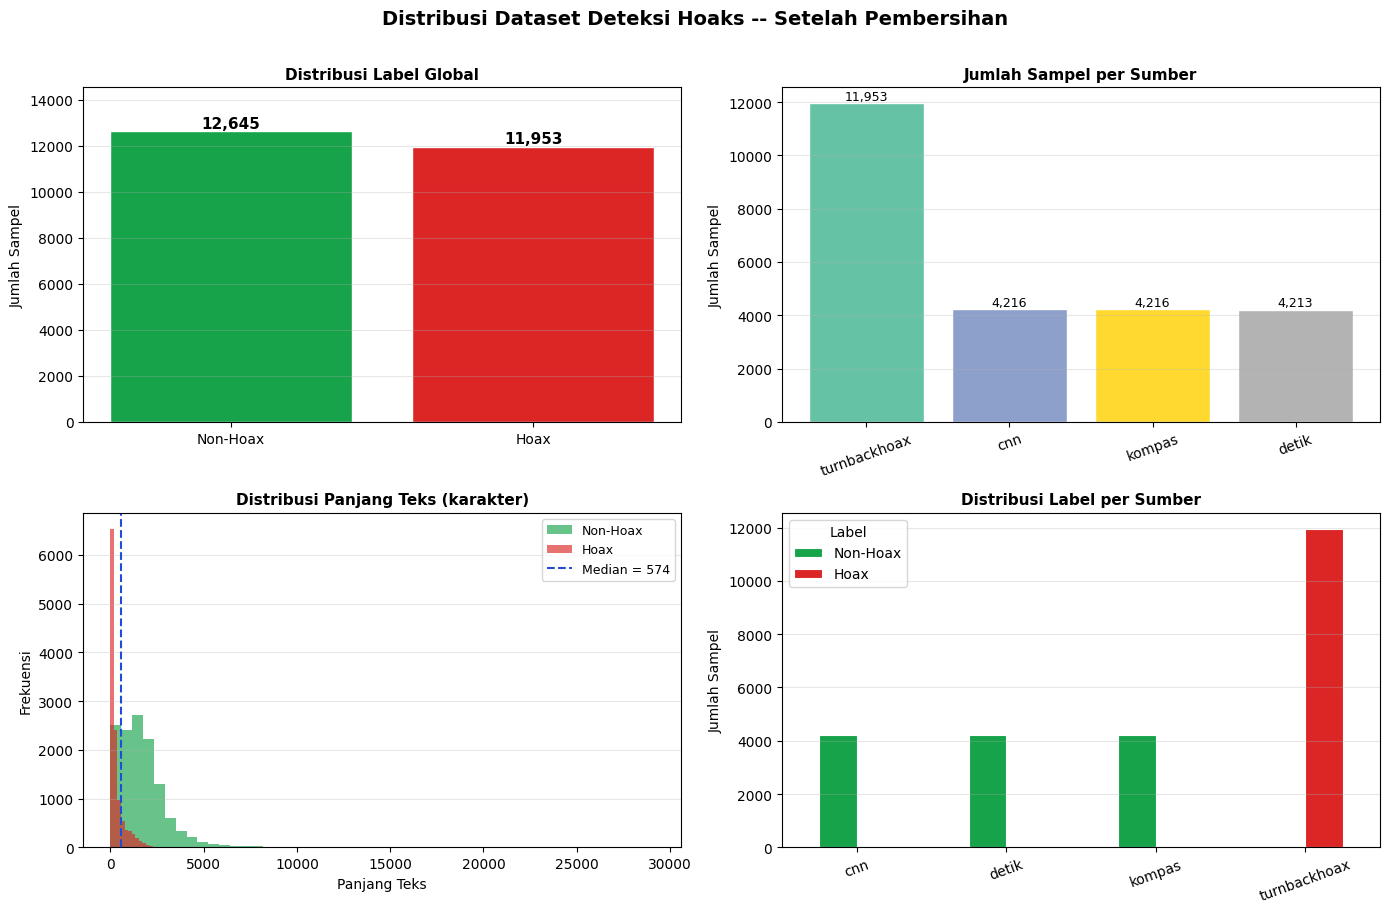

Grafik disimpan ke: distribusi_dataset.png

Statistik Panjang Teks:
count    24598.0
mean      1029.0
std       1172.7
min          1.0
25%        176.0
50%        573.5
75%       1592.0
max      29140.0

Rasio Hoax: 48.6%
  Train : 17,218 | Val : 3,690 | Test : 3,690

Corpus BERTopic: 17,218


Map:   0%|          | 0/17218 [00:00<?, ? examples/s]

Map:   0%|          | 0/3690 [00:00<?, ? examples/s]

Map:   0%|          | 0/3690 [00:00<?, ? examples/s]

Train: 17,218 | Val: 3,690 | Test: 3,690
Trainer siap  — train: 17,218  |  val: 3,690

Memulai training IndoBERT...


...


Training selesai.
   Checkpoint terbaik : indobert_hoax_model_v3/checkpoint-270
   Metrik terbaik (f1): 0.9966

Cache prediksi direset setelah training baru selesai.

Evaluasi VALIDATION SET


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Precision Weighted,Recall Weighted,F1 Weighted
0.013117,0.015156,3,0.996748,0.998880,0.994423,0.996646,0.996757,0.996748,0.996748


{'eval_loss': 0.015155795961618423, 'eval_accuracy': 0.9967479674796748, 'eval_precision': 0.9988795518207283, 'eval_recall': 0.9944227551589515, 'eval_f1': 0.9966461710452766, 'eval_precision_weighted': 0.9967569190149653, 'eval_recall_weighted': 0.9967479674796748, 'eval_f1_weighted': 0.9967477532841262}

Evaluasi TEST SET


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Precision Weighted,Recall Weighted,F1 Weighted
0.013117,0.015295,3,0.996748,0.999439,0.993865,0.996644,0.996762,0.996748,0.996748


{'eval_loss': 0.015294763259589672, 'eval_accuracy': 0.9967479674796748, 'eval_precision': 0.9994391475042064, 'eval_recall': 0.9938650306748467, 'eval_f1': 0.9966442953020134, 'eval_precision_weighted': 0.9967620795930703, 'eval_recall_weighted': 0.9967479674796748, 'eval_f1_weighted': 0.9967476949450331}


In [14]:
# ================== SEL 14 -- Pipeline End-to-End: Load → Proses → Train → Evaluasi ==================
# Menjalankan alur pipeline lengkap mulai dari pemuatan data hingga training dan evaluasi awal model IndoBERT.
# - Load & bersihkan data: memanggil muat_semua_dataset() dan bangun_dataframe_training()
# - Pembagian data: memanggil bagi_data_stratified() untuk split train/val/test
# - Tokenisasi: memanggil siapkan_dataset_hf() untuk menyiapkan dataset HuggingFace
# - Trainer: membentuk objek Trainer dan menjalankan trainer.train()
# Sel ini diakhiri dengan evaluasi model pada validation set dan test set menggunakan trainer.evaluate().
# =====================================================================================================

# Menetapkan `df_mentah` = memanggil `muat_semua_dataset(...)`
df_mentah = muat_semua_dataset(cfg)
# Menetapkan `df_bersih` = memanggil `bangun_dataframe_training(...)`
df_bersih = bangun_dataframe_training(df_mentah)

# Visualisasi distribusi dataset
# Memanggil `visualisasi_distribusi_dataset(...)`
visualisasi_distribusi_dataset(df_bersih, judul_prefix="Setelah Pembersihan")

# Menetapkan `(train_df, val_df, test_df)` = memanggil `bagi_data_stratified(...)`
train_df, val_df, test_df = bagi_data_stratified(df_bersih, seed=cfg.seed)

# Simpan corpus train untuk BERTopic (dipakai apa adanya, tanpa oversampling)
# Menetapkan `train_df_pra_oversampling` = memanggil `train_df.copy(...)`
train_df_pra_oversampling = train_df.copy()
# Memanggil `print(...)`
print(f"\nCorpus BERTopic: {len(train_df_pra_oversampling):,}")

# Menetapkan `(ds_train, ds_val, ds_test)` = memanggil `siapkan_dataset_hf(...)`
ds_train, ds_val, ds_test = siapkan_dataset_hf(train_df, val_df, test_df)

# Buat Trainer setelah dataset tersedia
# Menetapkan `trainer` = memanggil `Trainer(...)`
trainer = Trainer(
    model           = model,
    args            = argumen_training,
    train_dataset   = ds_train,
    eval_dataset    = ds_val,
    data_collator   = collator_padding,
    compute_metrics = hitung_metrik,
)
# Memanggil `print(...)`
print(f"Trainer siap  — train: {len(ds_train):,}  |  val: {len(ds_val):,}")

# Memanggil `print(...)`
print("\n" + "="*60)
# Memanggil `print(...)`
print("Memulai training IndoBERT...")
# Memanggil `print(...)`
print("="*60)
# Menetapkan `hasil_training` = memanggil `trainer.train(...)`
hasil_training = trainer.train()

# Memanggil `print(...)`
print(f"\nTraining selesai.")
# Memanggil `print(...)`
print(f"   Checkpoint terbaik : {trainer.state.best_model_checkpoint}")
# Memanggil `print(...)`
print(f"   Metrik terbaik (f1): {trainer.state.best_metric:.4f}")

# Menetapkan `log_history_training` = memanggil `list(...)`
log_history_training = list(trainer.state.log_history)

# Reset cache prediksi
# Variabel/field `_cache_prediksi` (tipe Dict[str, object]) = {}
_cache_prediksi: Dict[str, object] = {}
# Memanggil `print(...)`
print("\nCache prediksi direset setelah training baru selesai.")

# Memanggil `print(...)`
print("\n" + "="*60 + "\nEvaluasi VALIDATION SET\n" + "="*60)
# Menetapkan `metrik_val` = memanggil `trainer.evaluate(...)`
# Memanggil `print(...)`
metrik_val = trainer.evaluate(ds_val); print(metrik_val)

# Memanggil `print(...)`
print("\n" + "="*60 + "\nEvaluasi TEST SET\n" + "="*60)
# Menetapkan `metrik_test` = memanggil `trainer.evaluate(...)`
# Memanggil `print(...)`
metrik_test = trainer.evaluate(ds_test); print(metrik_test)

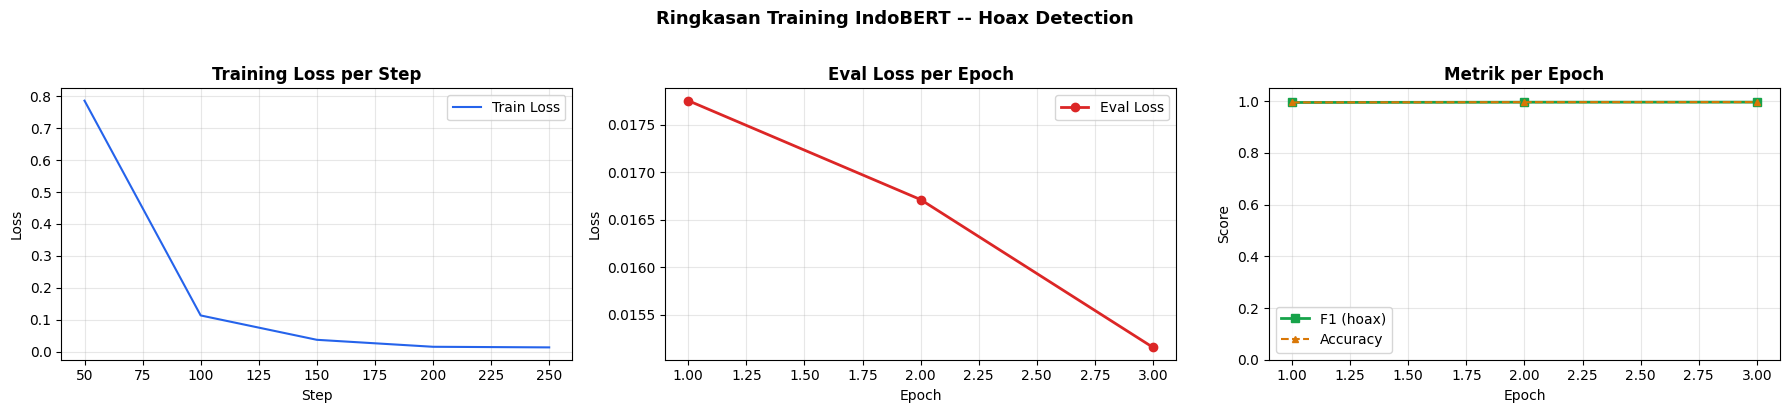

Grafik disimpan ke: kurva_training.png


In [15]:
# ================== SEL 15 -- Visualisasi Loss Curve dan Metrik per Epoch ==================
# Menganalisis proses training melalui grafik loss dan metrik yang tercatat pada log_history Trainer.
# - Training Loss per Step: memantau loss pada setiap langkah training
# - Eval Loss per Epoch: memantau loss pada data validasi di setiap epoch
# - Metrik per Epoch: menampilkan tren F1-score dan Accuracy antar-epoch
# Grafik ini membantu mendeteksi indikasi overfitting maupun underfitting selama proses training.
# ===========================================================================================
# Definisi fungsi `plot_kurva_loss(log_history: list)`
def plot_kurva_loss(log_history: list):
    # Menetapkan `(l_step, l_loss)` = ([], [])
    l_step, l_loss = [], []
    # Menetapkan `(e_step, e_loss, e_epoch, e_f1, e_acc)` = ([], [], [], [], [])
    e_step, e_loss, e_epoch, e_f1, e_acc = [], [], [], [], []
    # Perulangan: untuk setiap `entri` dalam log_history
    for entri in log_history:
        # Percabangan: jika 'loss' in entri and 'eval_loss' not in entri
        if "loss" in entri and "eval_loss" not in entri:
            # Memanggil `l_step.append(...)`
            # Memanggil `l_loss.append(...)`
            l_step.append(entri["step"]); l_loss.append(entri["loss"])
        # Percabangan: jika 'eval_loss' in entri
        if "eval_loss" in entri:
            # Memanggil `e_step.append(...)`
            # Memanggil `e_loss.append(...)`
            e_step.append(entri["step"]); e_loss.append(entri["eval_loss"])
            # Percabangan: jika 'epoch' in entri
            # Memanggil `e_epoch.append(...)`
            if "epoch"        in entri: e_epoch.append(entri["epoch"])
            # Percabangan: jika 'eval_f1' in entri
            # Memanggil `e_f1.append(...)`
            if "eval_f1"      in entri: e_f1.append(entri["eval_f1"])
            # Percabangan: jika 'eval_accuracy' in entri
            # Memanggil `e_acc.append(...)`
            if "eval_accuracy"in entri: e_acc.append(entri["eval_accuracy"])

    # Percabangan: jika not l_step and (not e_step)
    if not l_step and not e_step:
        # Memanggil `print(...)`
        # Mengembalikan None
        print("Log history kosong."); return

    # Menetapkan `n_plot` = 1 + int(bool(e_step)) + int(bool(e_f1))
    n_plot = 1 + int(bool(e_step)) + int(bool(e_f1))
    # Menetapkan `(fig, axes)` = memanggil `plt.subplots(...)`
    fig, axes = plt.subplots(1, n_plot, figsize=(6*n_plot, 4))
    # Percabangan: jika n_plot == 1
    # Menetapkan `axes` = [axes]
    if n_plot == 1: axes = [axes]

    # Percabangan: jika l_step
    if l_step:
        # Memanggil `axes[0].plot(...)`
        axes[0].plot(l_step, l_loss, color="#2563EB", lw=1.5, label="Train Loss")
        # Memanggil `axes[0].set_title(...)`
        # Memanggil `axes[0].set_xlabel(...)`
        axes[0].set_title("Training Loss per Step", fontweight="bold"); axes[0].set_xlabel("Step")
        # Memanggil `axes[0].set_ylabel(...)`
        # Memanggil `axes[0].legend(...)`
        # Memanggil `axes[0].grid(...)`
        axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Percabangan: jika e_step
    if e_step:
        # Menetapkan `(x, xl)` = ekspresi kondisional -> (e_epoch, 'Epoch') if e_epoch else (e_step, 'Step')
        x, xl = (e_epoch,"Epoch") if e_epoch else (e_step,"Step")
        # Memanggil `axes[1].plot(...)`
        axes[1].plot(x, e_loss, "o-", color="#DC2626", lw=2, ms=6, label="Eval Loss")
        # Memanggil `axes[1].set_title(...)`
        # Memanggil `axes[1].set_xlabel(...)`
        axes[1].set_title("Eval Loss per Epoch", fontweight="bold"); axes[1].set_xlabel(xl)
        # Memanggil `axes[1].set_ylabel(...)`
        # Memanggil `axes[1].legend(...)`
        # Memanggil `axes[1].grid(...)`
        axes[1].set_ylabel("Loss"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    # Percabangan: jika e_f1
    if e_f1:
        # Menetapkan `(x, xl)` = ekspresi kondisional -> (e_epoch, 'Epoch') if e_epoch else (list(range(1,
        #   len(e_f1) + 1)), 'Checkpoint')
        x, xl = (e_epoch,"Epoch") if e_epoch else (list(range(1,len(e_f1)+1)),"Checkpoint")
        # Memanggil `axes[2].plot(...)`
        axes[2].plot(x, e_f1, "s-", color="#16A34A", lw=2, ms=6, label="F1 (hoax)")
        # Percabangan: jika e_acc
        if e_acc:
            # Memanggil `axes[2].plot(...)`
            axes[2].plot(x, e_acc, "^--", color="#D97706", lw=1.5, ms=5, label="Accuracy")
        # Memanggil `axes[2].set_title(...)`
        # Memanggil `axes[2].set_xlabel(...)`
        axes[2].set_title("Metrik per Epoch", fontweight="bold"); axes[2].set_xlabel(xl)
        # Memanggil `axes[2].set_ylabel(...)`
        # Memanggil `axes[2].set_ylim(...)`
        axes[2].set_ylabel("Score"); axes[2].set_ylim(0, 1.05)
        # Memanggil `axes[2].legend(...)`
        # Memanggil `axes[2].grid(...)`
        axes[2].legend(); axes[2].grid(True, alpha=0.3)

    # Memanggil `plt.suptitle(...)`
    plt.suptitle("Ringkasan Training IndoBERT -- Hoax Detection", fontsize=13, fontweight="bold", y=1.02)
    # Memanggil `plt.tight_layout(...)`
    plt.tight_layout()
    # Memanggil `plt.savefig(...)`
    # Memanggil `plt.show(...)`
    plt.savefig("kurva_training.png", dpi=150, bbox_inches="tight"); plt.show()
    # Memanggil `print(...)`
    print("Grafik disimpan ke: kurva_training.png")


# Memanggil `plot_kurva_loss(...)`
plot_kurva_loss(log_history_training)


  Laporan Klasifikasi -- Validation (default/argmax)
Mode evaluasi: default/argmax logits, belum memakai threshold optimal.
              precision    recall  f1-score   support

    not_hoax     0.9948    0.9989    0.9968      1897
        hoax     0.9989    0.9944    0.9966      1793

    accuracy                         0.9967      3690
   macro avg     0.9968    0.9967    0.9967      3690
weighted avg     0.9968    0.9967    0.9967      3690



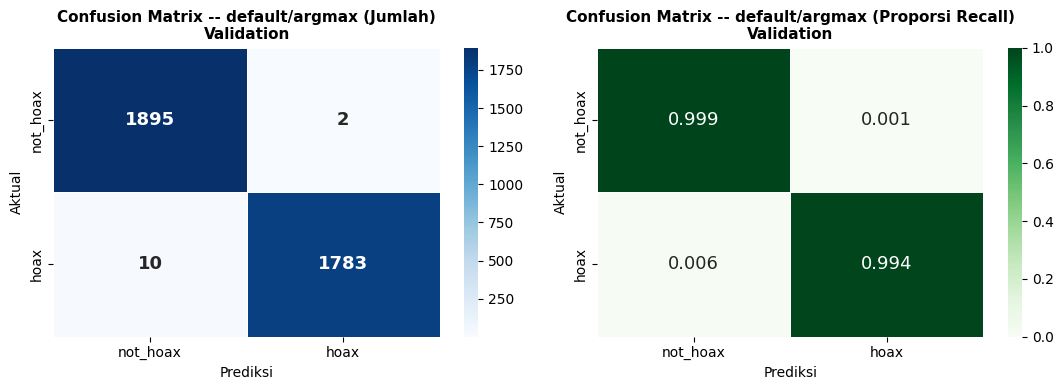

Confusion matrix default/argmax disimpan ke: confusion_matrix_validation.png



  Laporan Klasifikasi -- Test (default/argmax)
Mode evaluasi: default/argmax logits, belum memakai threshold optimal.
              precision    recall  f1-score   support

    not_hoax     0.9942    0.9995    0.9968      1897
        hoax     0.9994    0.9939    0.9966      1793

    accuracy                         0.9967      3690
   macro avg     0.9968    0.9967    0.9967      3690
weighted avg     0.9968    0.9967    0.9967      3690



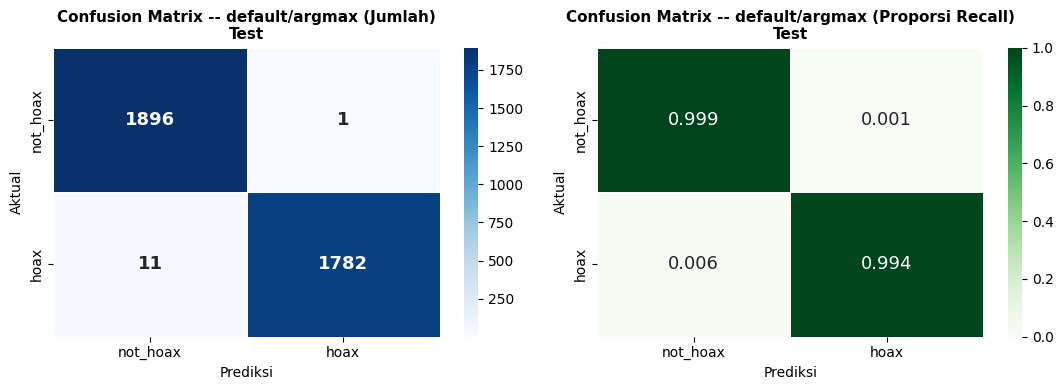

Confusion matrix default/argmax disimpan ke: confusion_matrix_test.png


In [16]:
# ================== SEL 16 -- Laporan Klasifikasi Detail dan Confusion Matrix ==================
# Menghasilkan laporan evaluasi model pada mode default/argmax, belum memakai threshold hasil kalibrasi.
# - dapatkan_prediksi(): mengambil dan menyimpan cache hasil prediksi Trainer per split
# - classification_report (sklearn): menyusun laporan precision, recall, dan F1 per kelas
# - Confusion Matrix: memvisualisasikan hasil prediksi dalam bentuk jumlah dan proporsi recall
# Hasil evaluasi default/argmax ini menjadi pembanding bagi evaluasi threshold optimal pada sel selanjutnya.
# ===============================================================================================

# Definisi fungsi `dapatkan_prediksi(trainer: Trainer, dataset: Dataset, nama_split: str)`
def dapatkan_prediksi(trainer: Trainer, dataset: Dataset, nama_split: str):
    # Percabangan: jika nama_split not in _cache_prediksi
    if nama_split not in _cache_prediksi:
        # Menetapkan `_cache_prediksi[nama_split]` = memanggil `trainer.predict(...)`
        _cache_prediksi[nama_split] = trainer.predict(dataset)
    # Mengembalikan _cache_prediksi[nama_split]
    return _cache_prediksi[nama_split]


# Definisi fungsi `_normalisasi_confusion_matrix(cm: np.ndarray)`
def _normalisasi_confusion_matrix(cm: np.ndarray) -> np.ndarray:
    # Mengembalikan memanggil `np.divide(...)`
    return np.divide(
        cm.astype(float),
        cm.sum(axis=1, keepdims=True),
        out=np.zeros_like(cm, dtype=float),
        where=cm.sum(axis=1, keepdims=True) != 0,
    )


# Definisi fungsi `_auc_dari_probabilitas(y_asli, prob_hoax)`
def _auc_dari_probabilitas(y_asli, prob_hoax):
    # Blok try: menjalankan kode di bawah dengan penanganan except
    try:
        # Menetapkan `(fpr, tpr, _)` = memanggil `roc_curve(...)`
        fpr, tpr, _ = roc_curve(y_asli, prob_hoax)
        # Mengembalikan memanggil `float(...)`
        return float(auc(fpr, tpr))
    # Penanganan except untuk Exception
    except Exception:
        # Mengembalikan 'UNKNOWN'
        return "UNKNOWN"


# Definisi fungsi `laporan_detail(trainer: Trainer, dataset: Dataset, nama_split: str)`
def laporan_detail(trainer: Trainer, dataset: Dataset, nama_split: str):
    # Menetapkan `out` = memanggil `dapatkan_prediksi(...)`
    out    = dapatkan_prediksi(trainer, dataset, nama_split)
    # Menetapkan `y_asli` = out.label_ids
    y_asli = out.label_ids
    # Menetapkan `y_pred` = memanggil `np.argmax(...)`
    y_pred = np.argmax(out.predictions, axis=-1)
    # Menetapkan `kelas` = ['not_hoax', 'hoax']
    kelas  = ["not_hoax", "hoax"]

    # Memanggil `print(...)`
    print(f"\n{'='*60}\n  Laporan Klasifikasi -- {nama_split} (default/argmax)\n{'='*60}")
    # Memanggil `print(...)`
    print("Mode evaluasi: default/argmax logits, belum memakai threshold optimal.")
    # Memanggil `print(...)`
    print(classification_report(y_asli, y_pred, target_names=kelas, digits=4))

    # Menetapkan `cm` = memanggil `confusion_matrix(...)`
    cm      = confusion_matrix(y_asli, y_pred)
    # Menetapkan `cm_norm` = memanggil `_normalisasi_confusion_matrix(...)`
    cm_norm = _normalisasi_confusion_matrix(cm)
    # Menetapkan `(fig, axes)` = memanggil `plt.subplots(...)`
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    # Memanggil `sns.heatmap(...)`
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=kelas, yticklabels=kelas, ax=axes[0],
                linewidths=0.5, annot_kws={"size":13,"weight":"bold"})
    # Memanggil `axes[0].set_title(...)`
    axes[0].set_title(f"Confusion Matrix -- default/argmax (Jumlah)\n{nama_split}", fontsize=11, fontweight="bold")
    # Memanggil `axes[0].set_xlabel(...)`
    # Memanggil `axes[0].set_ylabel(...)`
    axes[0].set_xlabel("Prediksi"); axes[0].set_ylabel("Aktual")

    # Memanggil `sns.heatmap(...)`
    sns.heatmap(cm_norm, annot=True, fmt=".3f", cmap="Greens",
                xticklabels=kelas, yticklabels=kelas, ax=axes[1],
                linewidths=0.5, vmin=0, vmax=1, annot_kws={"size":13})
    # Memanggil `axes[1].set_title(...)`
    axes[1].set_title(f"Confusion Matrix -- default/argmax (Proporsi Recall)\n{nama_split}", fontsize=11, fontweight="bold")
    # Memanggil `axes[1].set_xlabel(...)`
    # Memanggil `axes[1].set_ylabel(...)`
    axes[1].set_xlabel("Prediksi"); axes[1].set_ylabel("Aktual")

    # Memanggil `plt.tight_layout(...)`
    plt.tight_layout()
    # Menetapkan `fname` = f'confusion_matrix_{nama_split.lower().replace(' ', '_')}.png'
    fname = f"confusion_matrix_{nama_split.lower().replace(' ','_')}.png"
    # Memanggil `plt.savefig(...)`
    # Memanggil `plt.show(...)`
    plt.savefig(fname, dpi=150, bbox_inches="tight"); plt.show()
    # Memanggil `print(...)`
    print(f"Confusion matrix default/argmax disimpan ke: {fname}")

    # Menetapkan `probs` = memanggil `torch.softmax(torch.tensor(out.predictions, dtype=torch.f...(...)`
    probs = torch.softmax(torch.tensor(out.predictions, dtype=torch.float32), dim=-1).numpy()
    # Menetapkan `p_hoax` = probs[:, 1]
    p_hoax = probs[:, 1]
    # Mengembalikan literal dict berisi 11 pasangan key-value
    return {
        "split": nama_split,
        "mode": "default_argmax",
        "y_true": y_asli,
        "y_pred": y_pred,
        "prob_hoax": p_hoax,
        "confusion_matrix": cm,
        "accuracy": float(accuracy_score(y_asli, y_pred)),
        "precision": float(precision_score(y_asli, y_pred, pos_label=1, zero_division=0)),
        "recall": float(recall_score(y_asli, y_pred, pos_label=1, zero_division=0)),
        "f1": float(f1_score(y_asli, y_pred, pos_label=1, zero_division=0)),
        "auc": _auc_dari_probabilitas(y_asli, p_hoax),
    }


# Menetapkan `hasil_argmax_val` = memanggil `laporan_detail(...)`
hasil_argmax_val  = laporan_detail(trainer, ds_val,  "Validation")
# Menetapkan `hasil_argmax_test` = memanggil `laporan_detail(...)`
hasil_argmax_test = laporan_detail(trainer, ds_test, "Test")

# Menetapkan `ringkasan_argmax` = memanggil `pd.DataFrame(...)`
ringkasan_argmax = pd.DataFrame([
    {"Split": r["split"], "Mode": "default/argmax", "Accuracy": r["accuracy"],
     "Precision": r["precision"], "Recall": r["recall"], "F1": r["f1"], "AUC": r["auc"]}
    for r in [hasil_argmax_val, hasil_argmax_test]
])


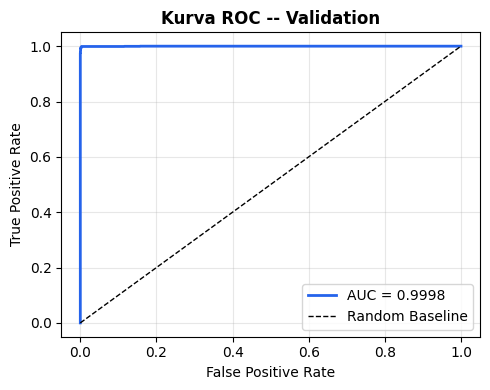

ROC curve disimpan ke: roc_curve_validation.png  |  AUC = 0.9998


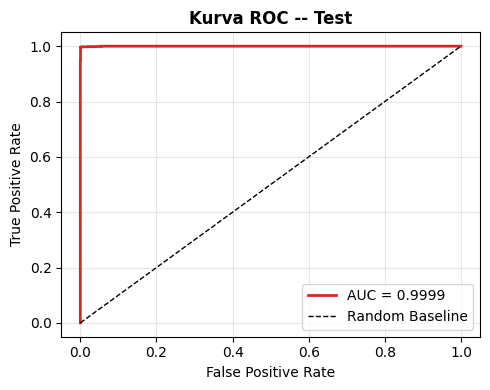

ROC curve disimpan ke: roc_curve_test.png  |  AUC = 0.9999


In [17]:
# ================== SEL 17 -- Kurva ROC dan Perhitungan AUC ==================
# Menampilkan Receiver Operating Characteristic (ROC) curve untuk menilai kemampuan model memisahkan kelas.
# - roc_curve (sklearn): menghitung True Positive Rate dan False Positive Rate pada berbagai threshold
# - auc (sklearn): menghitung luas area di bawah kurva ROC sebagai ukuran pemisahan kelas
# Kurva ROC dihasilkan untuk validation set dan test set guna membandingkan konsistensi performa model.
# =============================================================================
# Definisi fungsi `plot_kurva_roc(trainer, dataset, nama_split, warna='#2563EB')`
def plot_kurva_roc(trainer, dataset, nama_split, warna="#2563EB"):
    # Menetapkan `out` = memanggil `dapatkan_prediksi(...)`
    out   = dapatkan_prediksi(trainer, dataset, nama_split)
    # Menetapkan `probs` = memanggil `torch.softmax(torch.tensor(out.predictions, dtype=torch.f...(...)`
    probs = torch.softmax(torch.tensor(out.predictions, dtype=torch.float32), dim=-1).numpy()
    # Menetapkan `(fpr, tpr, _)` = memanggil `roc_curve(...)`
    fpr, tpr, _ = roc_curve(out.label_ids, probs[:,1], pos_label=1)
    # Menetapkan `nilai_auc` = memanggil `auc(...)`
    nilai_auc = auc(fpr, tpr)

    # Memanggil `plt.figure(...)`
    plt.figure(figsize=(5, 4))
    # Memanggil `plt.plot(...)`
    plt.plot(fpr, tpr, color=warna, lw=2, label=f"AUC = {nilai_auc:.4f}")
    # Memanggil `plt.plot(...)`
    plt.plot([0,1],[0,1],"k--", lw=1, label="Random Baseline")
    # Memanggil `plt.xlabel(...)`
    # Memanggil `plt.ylabel(...)`
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    # Memanggil `plt.title(...)`
    plt.title(f"Kurva ROC -- {nama_split}", fontsize=12, fontweight="bold")
    # Memanggil `plt.legend(...)`
    # Memanggil `plt.grid(...)`
    # Memanggil `plt.tight_layout(...)`
    plt.legend(loc="lower right"); plt.grid(True, alpha=0.3); plt.tight_layout()
    # Menetapkan `fname` = f'roc_curve_{nama_split.lower().replace(' ', '_')}.png'
    fname = f"roc_curve_{nama_split.lower().replace(' ','_')}.png"
    # Memanggil `plt.savefig(...)`
    # Memanggil `plt.show(...)`
    plt.savefig(fname, dpi=150, bbox_inches="tight"); plt.show()
    # Memanggil `print(...)`
    print(f"ROC curve disimpan ke: {fname}  |  AUC = {nilai_auc:.4f}")
    # Mengembalikan nilai_auc
    return nilai_auc


# Menetapkan `auc_val` = memanggil `plot_kurva_roc(...)`
auc_val  = plot_kurva_roc(trainer, ds_val,  "Validation", warna="#2563EB")
# Menetapkan `auc_test` = memanggil `plot_kurva_roc(...)`
auc_test = plot_kurva_roc(trainer, ds_test, "Test",       warna="#DC2626")

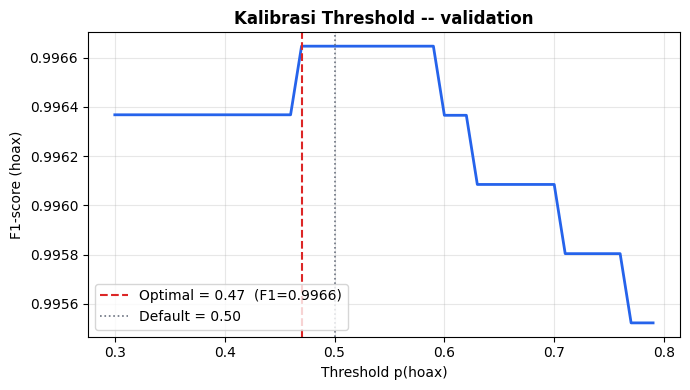

[validation] Threshold optimal : 0.47
[validation] F1 hoax @optimal  : 0.9966
[validation] F1 hoax @default  : 0.9966 (threshold=0.50)


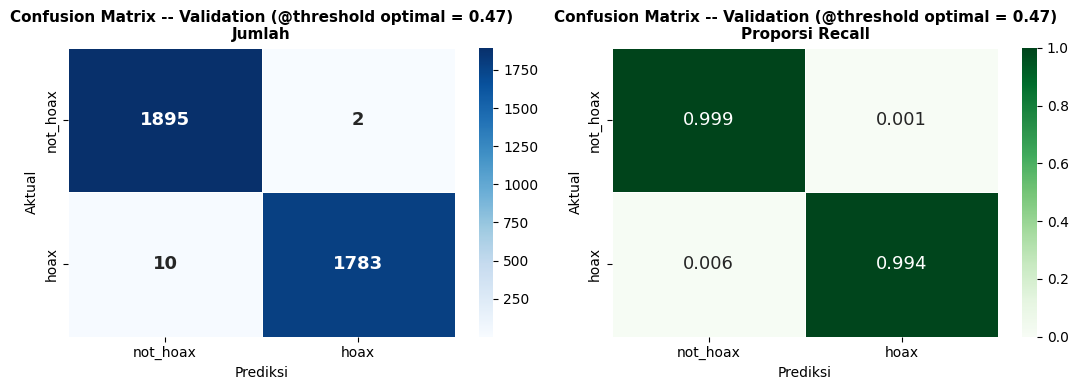


[Validation] Evaluasi threshold optimal = 0.47
{'Split': 'Validation', 'Mode': 'threshold_optimal', 'Threshold': 0.47000000000000014, 'Accuracy': 0.9967479674796748, 'Precision': 0.9988795518207283, 'Recall': 0.9944227551589515, 'F1': 0.9966461710452766, 'AUC': 0.9998230099423135, 'TP': 1783, 'FP': 2, 'FN': 10, 'TN': 1895, 'file_confusion_matrix': 'confusion_matrix_threshold_optimal_validation.png'}


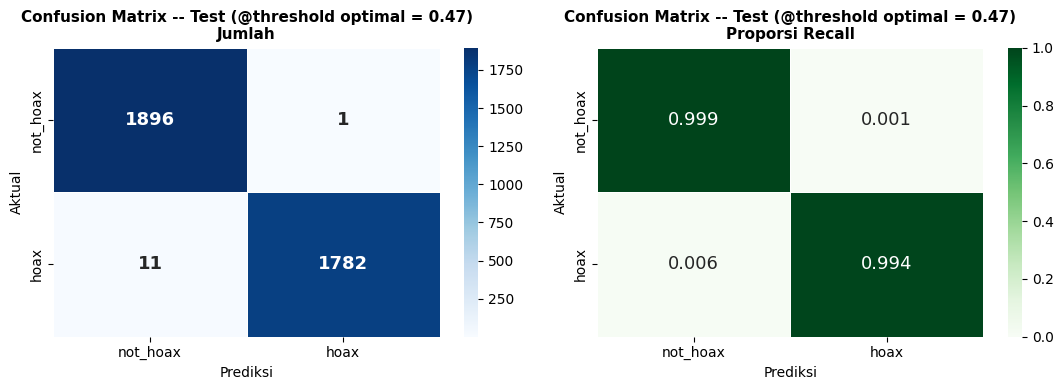


[Test] Evaluasi threshold optimal = 0.47
{'Split': 'Test', 'Mode': 'threshold_optimal', 'Threshold': 0.47000000000000014, 'Accuracy': 0.9967479674796748, 'Precision': 0.9994391475042064, 'Recall': 0.9938650306748467, 'F1': 0.9966442953020134, 'AUC': 0.999874019535351, 'TP': 1782, 'FP': 1, 'FN': 11, 'TN': 1896, 'file_confusion_matrix': 'confusion_matrix_threshold_optimal_test.png'}

THRESHOLD_DEFAULT = 0.50
THRESHOLD_OPTIMAL = 0.47


,Split,Mode,Threshold,Accuracy,Precision,Recall,F1,AUC,TP,FP,FN,TN
0,Validation,threshold_optimal,0.47,0.996748,0.998880,0.994423,0.996646,0.999823,1783,2,10,1895
1,Test,threshold_optimal,0.47,0.996748,0.999439,0.993865,0.996644,0.999874,1782,1,11,1896


In [18]:
# ================== SEL 18 -- Kalibrasi Threshold Probabilitas Optimal ==================
# Mencari threshold probabilitas klasifikasi yang mengoptimalkan F1-score pada validation set.
# - kalibrasi_threshold(): melakukan sweep threshold probabilitas hoax dan memilih F1-score tertinggi
# - evaluasi_threshold_optimal(): mengevaluasi validation dan test set menggunakan threshold hasil kalibrasi
# Threshold hasil kalibrasi disimpan pada variabel THRESHOLD_OPTIMAL untuk dipakai pada tahap inferensi dan penyimpanan metadata model.
# ========================================================================================

# Definisi fungsi `_threshold_default_runtime()`
def _threshold_default_runtime() -> float:
    # Percabangan: jika 'THRESHOLD_DEFAULT' in globals()
    if "THRESHOLD_DEFAULT" in globals():
        # Mengembalikan memanggil `float(...)`
        return float(THRESHOLD_DEFAULT)
    # Mengembalikan memanggil `float(...)`
    return float(getattr(cfg, "threshold_default"))


# Definisi fungsi `_probabilitas_hoax(trainer, dataset, nama_split: str)`
def _probabilitas_hoax(trainer, dataset, nama_split: str):
    # Menetapkan `out` = memanggil `dapatkan_prediksi(...)`
    out = dapatkan_prediksi(trainer, dataset, nama_split)
    # Menetapkan `probs` = memanggil `torch.softmax(torch.tensor(out.predictions, dtype=torch.f...(...)`
    probs = torch.softmax(torch.tensor(out.predictions, dtype=torch.float32), dim=-1).numpy()
    # Mengembalikan (out.label_ids, probs[:, 1])
    return out.label_ids, probs[:, 1]


# Definisi fungsi `kalibrasi_threshold(trainer, dataset, nama_split='val')`
def kalibrasi_threshold(trainer, dataset, nama_split="val") -> float:
    # Menetapkan `threshold_default` = memanggil `_threshold_default_runtime(...)`
    threshold_default = _threshold_default_runtime()
    # Menetapkan `(y_asli, p_hoax)` = memanggil `_probabilitas_hoax(...)`
    y_asli, p_hoax = _probabilitas_hoax(trainer, dataset, nama_split)

    # Menetapkan `sweep` = memanggil `np.arange(...)`
    sweep    = np.arange(0.30, 0.80, 0.01)
    # Menetapkan `riwayat` = hasil komprehensi -> [(float(t), float(f1_score(y_asli, (p_hoax >=
    #   t).astype(int), pos_label=1, ze...
    riwayat  = [(float(t), float(f1_score(y_asli,(p_hoax>=t).astype(int),
                                           pos_label=1, zero_division=0)))
                for t in sweep]
    # Menetapkan `(t_best, f1_best)` = memanggil `max(...)`
    t_best, f1_best = max(riwayat, key=lambda x: x[1])

    # Menetapkan `(tv, fv)` = memanggil `zip(...)`
    tv, fv = zip(*riwayat)
    # Memanggil `plt.figure(...)`
    plt.figure(figsize=(7, 4))
    # Memanggil `plt.plot(...)`
    plt.plot(tv, fv, color="#2563EB", lw=2)
    # Memanggil `plt.axvline(...)`
    plt.axvline(t_best, color="#DC2626", ls="--", lw=1.5,
                label=f"Optimal = {t_best:.2f}  (F1={f1_best:.4f})")
    # Memanggil `plt.axvline(...)`
    plt.axvline(threshold_default, color="#6B7280", ls=":", lw=1.2,
                label=f"Default = {threshold_default:.2f}")
    # Memanggil `plt.xlabel(...)`
    # Memanggil `plt.ylabel(...)`
    plt.xlabel("Threshold p(hoax)"); plt.ylabel("F1-score (hoax)")
    # Memanggil `plt.title(...)`
    plt.title(f"Kalibrasi Threshold -- {nama_split}", fontsize=12, fontweight="bold")
    # Memanggil `plt.legend(...)`
    # Memanggil `plt.grid(...)`
    # Memanggil `plt.tight_layout(...)`
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
    # Memanggil `plt.savefig(...)`
    plt.savefig(f"kalibrasi_threshold_{nama_split}.png", dpi=150, bbox_inches="tight")
    # Memanggil `plt.show(...)`
    plt.show()

    # Menetapkan `f1_def` = memanggil `f1_score(...)`
    f1_def = f1_score(y_asli, (p_hoax>=threshold_default).astype(int), pos_label=1, zero_division=0)
    # Memanggil `print(...)`
    print(f"[{nama_split}] Threshold optimal : {t_best:.2f}")
    # Memanggil `print(...)`
    print(f"[{nama_split}] F1 hoax @optimal  : {f1_best:.4f}")
    # Memanggil `print(...)`
    print(f"[{nama_split}] F1 hoax @default  : {f1_def:.4f} (threshold={threshold_default:.2f})")
    # Mengembalikan memanggil `float(...)`
    return float(t_best)


# Definisi fungsi `evaluasi_threshold_optimal(trainer, dataset, nama_split: str, threshold_optimal:
#   float)`
def evaluasi_threshold_optimal(trainer, dataset, nama_split: str, threshold_optimal: float) -> Dict[str, object]:
    # Menetapkan `(y_asli, p_hoax)` = memanggil `_probabilitas_hoax(...)`
    y_asli, p_hoax = _probabilitas_hoax(trainer, dataset, nama_split)
    # Menetapkan `pred` = memanggil `(p_hoax >= threshold_optimal).astype(...)`
    pred = (p_hoax >= threshold_optimal).astype(int)
    # Menetapkan `cm` = memanggil `confusion_matrix(...)`
    cm = confusion_matrix(y_asli, pred)
    # Menetapkan `cm_norm` = memanggil `_normalisasi_confusion_matrix(...)`
    cm_norm = _normalisasi_confusion_matrix(cm)
    # Menetapkan `kelas` = ['not_hoax', 'hoax']
    kelas = ["not_hoax", "hoax"]

    # Menetapkan `(fig, axes)` = memanggil `plt.subplots(...)`
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    # Memanggil `sns.heatmap(...)`
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=kelas, yticklabels=kelas, ax=axes[0],
                linewidths=0.5, annot_kws={"size":13,"weight":"bold"})
    # Memanggil `axes[0].set_title(...)`
    axes[0].set_title(
        f"Confusion Matrix -- {nama_split} (@threshold optimal = {threshold_optimal:.2f})\nJumlah",
        fontsize=11, fontweight="bold",
    )
    # Memanggil `axes[0].set_xlabel(...)`
    # Memanggil `axes[0].set_ylabel(...)`
    axes[0].set_xlabel("Prediksi"); axes[0].set_ylabel("Aktual")

    # Memanggil `sns.heatmap(...)`
    sns.heatmap(cm_norm, annot=True, fmt=".3f", cmap="Greens",
                xticklabels=kelas, yticklabels=kelas, ax=axes[1],
                linewidths=0.5, vmin=0, vmax=1, annot_kws={"size":13})
    # Memanggil `axes[1].set_title(...)`
    axes[1].set_title(
        f"Confusion Matrix -- {nama_split} (@threshold optimal = {threshold_optimal:.2f})\nProporsi Recall",
        fontsize=11, fontweight="bold",
    )
    # Memanggil `axes[1].set_xlabel(...)`
    # Memanggil `axes[1].set_ylabel(...)`
    axes[1].set_xlabel("Prediksi"); axes[1].set_ylabel("Aktual")

    # Memanggil `plt.tight_layout(...)`
    plt.tight_layout()
    # Menetapkan `fname` = f'confusion_matrix_threshold_optimal_{nama_split.lower().replace(' ',
    #   '_')}.png'
    fname = f"confusion_matrix_threshold_optimal_{nama_split.lower().replace(' ','_')}.png"
    # Memanggil `plt.savefig(...)`
    # Memanggil `plt.show(...)`
    plt.savefig(fname, dpi=150, bbox_inches="tight"); plt.show()

    # Menetapkan `hasil` = literal dict berisi 14 pasangan key-value
    hasil = {
        "Split": nama_split,
        "Mode": "threshold_optimal",
        "Threshold": float(threshold_optimal),
        "Accuracy": float(accuracy_score(y_asli, pred)),
        "Precision": float(precision_score(y_asli, pred, pos_label=1, zero_division=0)),
        "Recall": float(recall_score(y_asli, pred, pos_label=1, zero_division=0)),
        "F1": float(f1_score(y_asli, pred, pos_label=1, zero_division=0)),
        "AUC": _auc_dari_probabilitas(y_asli, p_hoax),
        "TP": int(((pred == 1) & (y_asli == 1)).sum()),
        "FP": int(((pred == 1) & (y_asli == 0)).sum()),
        "FN": int(((pred == 0) & (y_asli == 1)).sum()),
        "TN": int(((pred == 0) & (y_asli == 0)).sum()),
        "confusion_matrix": cm,
        "file_confusion_matrix": fname,
    }
    # Memanggil `print(...)`
    print(f"\n[{nama_split}] Evaluasi threshold optimal = {threshold_optimal:.2f}")
    # Memanggil `print(...)`
    print({k: v for k, v in hasil.items() if k not in {"confusion_matrix"}})
    # Mengembalikan hasil
    return hasil


# Menetapkan `THRESHOLD_DEFAULT` = memanggil `_threshold_default_runtime(...)`
THRESHOLD_DEFAULT = _threshold_default_runtime()
# Menetapkan `THRESHOLD_OPTIMAL` = memanggil `kalibrasi_threshold(...)`
THRESHOLD_OPTIMAL = kalibrasi_threshold(trainer, ds_val, "validation")

# Menetapkan `hasil_threshold_optimal_val` = memanggil `evaluasi_threshold_optimal(...)`
hasil_threshold_optimal_val = evaluasi_threshold_optimal(trainer, ds_val, "Validation", THRESHOLD_OPTIMAL)
# Menetapkan `hasil_threshold_optimal_test` = memanggil `evaluasi_threshold_optimal(...)`
hasil_threshold_optimal_test = evaluasi_threshold_optimal(trainer, ds_test, "Test", THRESHOLD_OPTIMAL)

# Menetapkan `ringkasan_threshold_optimal` = memanggil `pd.DataFrame(...)`
ringkasan_threshold_optimal = pd.DataFrame([
    {k: v for k, v in hasil.items() if k not in {"confusion_matrix"}}
    for hasil in [hasil_threshold_optimal_val, hasil_threshold_optimal_test]
])

# Memanggil `print(...)`
print(f"\nTHRESHOLD_DEFAULT = {THRESHOLD_DEFAULT:.2f}")
# Memanggil `print(...)`
print(f"THRESHOLD_OPTIMAL = {THRESHOLD_OPTIMAL:.2f}")
# Memanggil `display(...)`
display(ringkasan_threshold_optimal.drop(columns=["file_confusion_matrix"], errors="ignore"))


## Tabel Perbandingan Multi-Threshold [A2]

Tabel Precision/Recall/F1 pada berbagai threshold untuk memilih trade-off false positive vs. false negative.

In [19]:
# ================== SEL 19 -- Tabel Perbandingan Multi-Threshold ==================
# Menyusun tabel perbandingan metrik klasifikasi pada beberapa nilai threshold berbeda.
# - tabel_perbandingan_threshold(): menghitung precision, recall, F1, dan komponen confusion matrix (TP/FP/FN) di setiap threshold
# Tabel ini membantu memahami trade-off precision-recall saat threshold digeser dari nilai default menuju nilai optimal.
# ==================================================================================
# Definisi fungsi `tabel_perbandingan_threshold(trainer, dataset, nama_split, threshold_optimal,
#   threshold_list=None)`
def tabel_perbandingan_threshold(trainer, dataset, nama_split, threshold_optimal,
                                  threshold_list=None):
    # Menetapkan `threshold_default` = memanggil `float(...)`
    threshold_default = float(globals().get("THRESHOLD_DEFAULT", getattr(cfg, "threshold_default")))
    # Percabangan: jika threshold_list is None
    if threshold_list is None:
        # Menetapkan `threshold_list` = literal list berisi 10 elemen
        threshold_list = [0.30, 0.35, 0.40, 0.45, threshold_default,
                          0.55, 0.60, 0.65, 0.70, threshold_optimal]
    # Menetapkan `threshold_list` = memanggil `sorted(...)`
    threshold_list = sorted(set(round(t, 2) for t in threshold_list))

    # Menetapkan `out` = memanggil `dapatkan_prediksi(...)`
    out   = dapatkan_prediksi(trainer, dataset, nama_split)
    # Menetapkan `y` = out.label_ids
    y     = out.label_ids
    # Menetapkan `probs` = memanggil `torch.softmax(torch.tensor(out.predictions, dtype=torch.f...(...)`
    probs = torch.softmax(torch.tensor(out.predictions, dtype=torch.float32), dim=-1).numpy()
    # Menetapkan `p_h` = probs[:, 1]
    p_h   = probs[:,1]

    # Menetapkan `baris` = []
    baris = []
    # Perulangan: untuk setiap `t` dalam threshold_list
    for t in threshold_list:
        # Menetapkan `pred` = memanggil `(p_h >= t).astype(...)`
        pred = (p_h >= t).astype(int)
        # Menetapkan `prec` = memanggil `precision_score(...)`
        prec = precision_score(y, pred, pos_label=1, zero_division=0)
        # Menetapkan `rec` = memanggil `recall_score(...)`
        rec  = recall_score(y, pred,    pos_label=1, zero_division=0)
        # Menetapkan `f1` = memanggil `f1_score(...)`
        f1   = f1_score(y, pred,        pos_label=1, zero_division=0)
        # Menetapkan `tp` = memanggil `int(...)`
        tp   = int(((pred==1)&(y==1)).sum())
        # Menetapkan `fp` = memanggil `int(...)`
        fp   = int(((pred==1)&(y==0)).sum())
        # Menetapkan `fn` = memanggil `int(...)`
        fn   = int(((pred==0)&(y==1)).sum())
        # Menetapkan `ket` = ''
        ket  = ""
        # Percabangan: jika abs(t - threshold_default) < 0.005
        # Menetapkan `ket` = '<- default'
        if abs(t - threshold_default) < 0.005: ket = "<- default"
        # Percabangan: jika abs(t - threshold_optimal) < 0.005
        # Menetapkan `ket` = '<- OPTIMAL'
        if abs(t - threshold_optimal) < 0.005: ket = "<- OPTIMAL"
        # Memanggil `baris.append(...)`
        baris.append({"Threshold": f"{t:.2f}", "Precision": f"{prec:.4f}",
                       "Recall": f"{rec:.4f}", "F1-Hoax": f"{f1:.4f}",
                       "TP": tp, "FP": fp, "FN": fn, "Keterangan": ket})

    # Menetapkan `df_t` = memanggil `pd.DataFrame(...)`
    df_t = pd.DataFrame(baris)
    # Memanggil `print(...)`
    print(f"\n{'='*70}\n  Tabel Perbandingan Threshold -- {nama_split}\n{'='*70}")
    # Memanggil `print(...)`
    print(df_t.to_string(index=False))
    # Memanggil `print(...)`
    print("="*70)
    # Mengembalikan df_t
    return df_t


# Menetapkan `tabel_val` = memanggil `tabel_perbandingan_threshold(...)`
tabel_val  = tabel_perbandingan_threshold(trainer, ds_val,  "Validation", THRESHOLD_OPTIMAL)
# Menetapkan `tabel_test` = memanggil `tabel_perbandingan_threshold(...)`
tabel_test = tabel_perbandingan_threshold(trainer, ds_test, "Test",       THRESHOLD_OPTIMAL)


  Tabel Perbandingan Threshold -- Validation
Threshold Precision Recall F1-Hoax   TP  FP  FN Keterangan
     0.30    0.9983 0.9944  0.9964 1783   3  10           
     0.35    0.9983 0.9944  0.9964 1783   3  10           
     0.40    0.9983 0.9944  0.9964 1783   3  10           
     0.45    0.9983 0.9944  0.9964 1783   3  10           
     0.47    0.9989 0.9944  0.9966 1783   2  10 <- OPTIMAL
     0.50    0.9989 0.9944  0.9966 1783   2  10 <- default
     0.55    0.9989 0.9944  0.9966 1783   2  10           
     0.60    0.9989 0.9939  0.9964 1782   2  11           
     0.65    0.9989 0.9933  0.9961 1781   2  12           
     0.70    0.9989 0.9933  0.9961 1781   2  12           

  Tabel Perbandingan Threshold -- Test
Threshold Precision Recall F1-Hoax   TP  FP  FN Keterangan
     0.30    0.9994 0.9955  0.9975 1785   1   8           
     0.35    0.9994 0.9950  0.9972 1784   1   9           
     0.40    0.9994 0.9939  0.9966 1782   1  11           
     0.45    0.9994 0.9939  0

In [20]:
# ================== SEL 20 -- Simpan Model IndoBERT dan Metadata ==================
# Menyimpan model IndoBERT terlatih beserta tokenizer dan metadata konfigurasi inferensi ke disk.
# - trainer.model.save_pretrained() & tokenizer.save_pretrained(): menyimpan bobot model dan file tokenizer
# - inference_config.json: menyimpan threshold optimal, threshold default, serta informasi versi library dan label
# Berkas hasil sel ini menjadi artefak model yang siap dipakai untuk proses inferensi maupun integrasi FastAPI.
# ==================================================================================
# Memanggil `os.makedirs(...)`
os.makedirs(cfg.output_dir, exist_ok=True)
# Memanggil `trainer.model.save_pretrained(...)`
trainer.model.save_pretrained(cfg.output_dir)
# Memanggil `tokenizer.save_pretrained(...)`
tokenizer.save_pretrained(cfg.output_dir)

# Menetapkan `metadata_inferensi` = literal dict berisi 10 pasangan key-value
metadata_inferensi = {
    "threshold_optimal":     float(THRESHOLD_OPTIMAL),
    "threshold_default":     float(THRESHOLD_DEFAULT),
    "metric_for_best_model": "f1",
    "model_name":            cfg.model_name,
    "max_length":            cfg.max_length,
    "label2id":              label_ke_id,
    "id2label":              {str(k): v for k, v in id_ke_label.items()},
    "transformers_version":  transformers.__version__,
    "torch_version":         torch.__version__,
    "training_date":         pd.Timestamp.now().strftime("%Y-%m-%d"),
}
# Blok with menggunakan open(os.path.join(cfg.output_dir, 'inference_co...
with open(os.path.join(cfg.output_dir, "inference_config.json"), "w",
          encoding="utf-8") as _f:
    # Memanggil `_json.dump(...)`
    _json.dump(metadata_inferensi, _f, indent=2, ensure_ascii=False)

# Memanggil `print(...)`
print(f"Model & metadata disimpan ke: {cfg.output_dir}/")
# Memanggil `print(...)`
print(f"   Best checkpoint      : {trainer.state.best_model_checkpoint}")
# Memanggil `print(...)`
print(f"   THRESHOLD_OPTIMAL    : {THRESHOLD_OPTIMAL:.2f}")
# Memanggil `print(...)`
print(f"   transformers_version : {transformers.__version__}")
# Memanggil `print(...)`
print(f"   training_date        : {metadata_inferensi['training_date']}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model & metadata disimpan ke: indobert_hoax_model_v3/
   Best checkpoint      : indobert_hoax_model_v3/checkpoint-270
   THRESHOLD_OPTIMAL    : 0.47
   transformers_version : 5.12.1
   training_date        : 2026-07-03


## Inferensi Multi-Paragraf (Sentence-Level + Topic)

**Tidak mengubah training classifier IndoBERT.** Semua proses adalah post-processing: memisahkan teks menjadi paragraf dan kalimat, mengklasifikasikan setiap kalimat, mengagregasi label, dan mengekstraksi topik TF-IDF ringan.

- Menggunakan `THRESHOLD_OPTIMAL` dari validation set; threshold default diambil dari konfigurasi runtime sebagai pembanding.
- `torch.inference_mode()` digunakan untuk inference yang lebih efisien.


In [21]:
# ================== SEL 21 -- Utilitas Inferensi Multi-Paragraf dan Topic Extraction ==================
# Menyediakan fungsi-fungsi pendukung inferensi teks panjang pada level dokumen, paragraf, dan kalimat.
# - prediksi_batch(): melakukan prediksi hoax/non-hoax secara batch menggunakan threshold aktif
# - pisahkan_paragraf() & pisahkan_kalimat(): memecah teks menjadi satuan paragraf dan kalimat
# - ekstrak_topik_tfidf(): mengekstraksi kata kunci topik per paragraf menggunakan TF-IDF
# - analisis_multi_paragraf(): menggabungkan hasil klasifikasi dan topik menjadi struktur JSON bertingkat
# Fungsi-fungsi ini menjadi dasar bagi demo inferensi pada sel berikutnya maupun potensi integrasi ke layanan FastAPI.
# ======================================================================================================
# Impor modul: re
import re
# Impor dari `collections`: defaultdict
from collections import defaultdict
# Impor dari `sklearn.feature_extraction.text`: TfidfVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Menetapkan `REGEX_PISAH_PARAGRAF` = memanggil `re.compile(...)`
REGEX_PISAH_PARAGRAF = re.compile(r"(?:\r?\n){2,}")
# Menetapkan `REGEX_PISAH_KALIMAT` = memanggil `re.compile(...)`
REGEX_PISAH_KALIMAT  = re.compile(r'[^.!?]+(?:[.!?]+(?:[")\]]+)?)|[^.!?]+$')
# Menetapkan `REGEX_SPASI` = memanggil `re.compile(...)`
REGEX_SPASI          = re.compile(r"\s+")
# Menetapkan `REGEX_TOKEN` = memanggil `re.compile(...)`
REGEX_TOKEN          = re.compile(r"[a-zA-Z]{3,}")

# Menetapkan `STOPWORDS_ID` = literal set berisi 40 elemen
STOPWORDS_ID = {
    "yang","dan","atau","di","ke","dari","untuk","dengan","pada",
    "adalah","itu","ini","dalam","sebagai","karena","juga","agar",
    "oleh","saat","akan","telah","sudah","tidak","iya","ya","kita",
    "mereka","kami","anda","hingga","lebih","masih","dapat","bisa",
    "setelah","sebelum","tersebut","terhadap","disebut","menurut",
}


# Definisi fungsi `normalisasi_teks(teks: str)`
def normalisasi_teks(teks: str) -> str:
    # Mengembalikan memanggil `REGEX_SPASI.sub(' ', str(teks)).strip(...)`
    return REGEX_SPASI.sub(" ", str(teks)).strip()


# Definisi fungsi `pisahkan_paragraf(teks: str)`
def pisahkan_paragraf(teks: str) -> List[str]:
    # Menetapkan `mentah` = memanggil `str(teks).strip(...)`
    mentah = str(teks).strip()
    # Percabangan: jika not mentah
    # Mengembalikan []
    if not mentah: return []
    # Menetapkan `par` = hasil komprehensi -> [p.strip() for p in REGEX_PISAH_PARAGRAF.split(mentah) if
    #   p.strip()]
    par = [p.strip() for p in REGEX_PISAH_PARAGRAF.split(mentah) if p.strip()]
    # Mengembalikan ekspresi kondisional -> par if par else [mentah]
    return par if par else [mentah]


# Definisi fungsi `pisahkan_kalimat(paragraf: str)`
def pisahkan_kalimat(paragraf: str) -> List[str]:
    # Menetapkan `d` = memanggil `normalisasi_teks(...)`
    d = normalisasi_teks(paragraf)
    # Percabangan: jika not d
    # Mengembalikan []
    if not d: return []
    # Menetapkan `kal` = hasil komprehensi -> [m.group(0).strip() for m in
    #   REGEX_PISAH_KALIMAT.finditer(d)]
    kal = [m.group(0).strip() for m in REGEX_PISAH_KALIMAT.finditer(d)]
    # Mengembalikan [k for k in kal if k] or [d]
    return [k for k in kal if k] or [d]


# Definisi fungsi `prediksi_batch(teks_list: List[str], ukuran_batch: int=64)`
def prediksi_batch(teks_list: List[str], ukuran_batch: int = 64) -> List[Dict]:
    # Percabangan: jika not teks_list
    # Mengembalikan []
    if not teks_list: return []
    # Menetapkan `th` = ekspresi kondisional -> THRESHOLD_OPTIMAL if 'THRESHOLD_OPTIMAL' in globals() else
    #   THRESHOLD_DEFAULT
    th = THRESHOLD_OPTIMAL if "THRESHOLD_OPTIMAL" in globals() else THRESHOLD_DEFAULT
    # Menetapkan `semua_probs` = []
    semua_probs = []
    # Memanggil `model.eval(...)`
    model.eval()
    # Perulangan: untuk setiap `i` dalam range(0, len(teks_list), ukuran_batch)
    for i in range(0, len(teks_list), ukuran_batch):
        # Menetapkan `potongan` = hasil komprehensi -> [normalisasi_teks(t) or '[EMPTY]' for t in
        #   teks_list[i:i + ukuran_batch]]
        potongan = [normalisasi_teks(t) or "[EMPTY]" for t in teks_list[i:i+ukuran_batch]]
        # Menetapkan `enc` = memanggil `tokenizer(...)`
        enc = tokenizer(potongan, truncation=True, max_length=cfg.max_length,
                        padding=True, return_tensors="pt")
        # Menetapkan `enc` = hasil komprehensi -> {k: v.to(device) for k, v in enc.items()}
        enc = {k: v.to(device) for k, v in enc.items()}
        # Blok with menggunakan torch.inference_mode()
        with torch.inference_mode():
            # Menetapkan `probs` = memanggil `torch.softmax(model(**enc).logits, dim=-1).cpu().numpy(...)`
            probs = torch.softmax(model(**enc).logits, dim=-1).cpu().numpy()
        # Memanggil `semua_probs.extend(...)`
        semua_probs.extend(probs)

    # Menetapkan `hasil` = []
    hasil = []
    # Perulangan: untuk setiap `baris` dalam semua_probs
    for baris in semua_probs:
        # Menetapkan `(p_n, p_h)` = (float(baris[0]), float(baris[1]))
        p_n, p_h = float(baris[0]), float(baris[1])
        # Menetapkan `label` = ekspresi kondisional -> 'hoax' if p_h >= th else 'not_hoax'
        label = "hoax" if p_h >= th else "not_hoax"
        # Menetapkan `conf` = memanggil `max(...)`
        conf  = max(p_h, p_n)
        # Menetapkan `warna` = ekspresi kondisional -> 'red' if label == 'hoax' else 'amber' if conf < 0.7
        #   else 'green'
        warna = "red" if label=="hoax" else ("amber" if conf<0.70 else "green")
        # Memanggil `hasil.append(...)`
        hasil.append({
            "label": label,
            "probabilities": {"not_hoax": round(p_n,6), "hoax": round(p_h,6)},
            "hoax_probability": round(p_h, 6),
            "confidence":       round(conf, 6),
            "color":            warna,
            "threshold_used":   round(th, 2),
        })
    # Mengembalikan hasil
    return hasil


# Definisi fungsi `ekstrak_topik_tfidf(teks_par: List[str], top_k: int=3, maks_fitur: int=1500)`
def ekstrak_topik_tfidf(teks_par: List[str], top_k: int = 3, maks_fitur: int = 1500) -> List[Dict]:
    # Percabangan: jika not teks_par
    # Mengembalikan []
    if not teks_par: return []
    # Menetapkan `vec` = memanggil `TfidfVectorizer(...)`
    vec = TfidfVectorizer(lowercase=True, ngram_range=(1,2), max_features=maks_fitur,
                           token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b",
                           stop_words=list(STOPWORDS_ID))
    # Menetapkan `out_t` = []
    out_t = []
    # Blok try: menjalankan kode di bawah dengan penanganan except
    try:
        # Menetapkan `M` = memanggil `vec.fit_transform(...)`
        # Menetapkan `F` = memanggil `vec.get_feature_names_out(...)`
        M = vec.fit_transform(teks_par); F = vec.get_feature_names_out()
        # Perulangan: untuk setiap `i` dalam range(M.shape[0])
        for i in range(M.shape[0]):
            # Menetapkan `br` = memanggil `M.getrow(...)`
            br = M.getrow(i)
            # Percabangan: jika br.nnz == 0
            if br.nnz == 0:
                # Menetapkan `tok` = hasil komprehensi -> [t for t in REGEX_TOKEN.findall(teks_par[i].lower()) if t
                #   not in STOPWORDS_ID]
                tok = [t for t in REGEX_TOKEN.findall(teks_par[i].lower()) if t not in STOPWORDS_ID]
                # Menetapkan `kk` = list(dict.fromkeys(tok))[:top_k] or ['topik_umum']
                kk  = list(dict.fromkeys(tok))[:top_k] or ["topik_umum"]
                # Menetapkan `skor` = 0.0
                skor = 0.0
            else:
                # Menetapkan `pas` = sorted(zip(br.indices, br.data), key=lambda x: (-x[1], F[x[0]]))[:top_k]
                pas  = sorted(zip(br.indices, br.data), key=lambda x:(-x[1],F[x[0]]))[:top_k]
                # Menetapkan `kk` = hasil komprehensi -> [F[idx] for idx, _ in pas]
                kk   = [F[idx] for idx,_ in pas]
                # Menetapkan `skor` = ekspresi kondisional -> float(np.mean([v for _, v in pas])) if pas else 0.0
                skor = float(np.mean([v for _,v in pas])) if pas else 0.0
            # Memanggil `out_t.append(...)`
            out_t.append({"label": " / ".join(kk[:2]) if kk else "topik_umum",
                           "score": round(skor,6), "keywords": kk[:top_k]})
    # Penanganan except untuk Exception
    except Exception:
        # Perulangan: untuk setiap `t` dalam teks_par
        for t in teks_par:
            # Menetapkan `tok` = hasil komprehensi -> [x for x in REGEX_TOKEN.findall(t.lower()) if x not in
            #   STOPWORDS_ID]
            tok = [x for x in REGEX_TOKEN.findall(t.lower()) if x not in STOPWORDS_ID]
            # Menetapkan `kk` = list(dict.fromkeys(tok))[:top_k] or ['topik_umum']
            kk  = list(dict.fromkeys(tok))[:top_k] or ["topik_umum"]
            # Memanggil `out_t.append(...)`
            out_t.append({"label": " / ".join(kk[:2]) if kk else "topik_umum",
                           "score": 0.0, "keywords": kk[:top_k]})
    # Mengembalikan out_t
    return out_t


# Definisi fungsi `analisis_multi_paragraf(teks: str, ukuran_batch_kalimat: int=64)`
def analisis_multi_paragraf(teks: str, ukuran_batch_kalimat: int = 64) -> Dict[str,Any]:
    # Menetapkan `teks_m` = memanggil `str(teks).strip(...)`
    teks_m = str(teks).strip()
    # Menetapkan `th` = ekspresi kondisional -> THRESHOLD_OPTIMAL if 'THRESHOLD_OPTIMAL' in globals() else
    #   THRESHOLD_DEFAULT
    th = THRESHOLD_OPTIMAL if "THRESHOLD_OPTIMAL" in globals() else THRESHOLD_DEFAULT
    # Percabangan: jika not teks_m
    if not teks_m:
        # Mengembalikan {'document': {'label': 'not_hoax', 'hoax_probability': 0.0, 'confidence': 0.0,
        #   'risk_le...
        return {"document":{"label":"not_hoax","hoax_probability":0.0,"confidence":0.0,
                             "risk_level":"low","sentence_aggregate_label":"not_hoax",
                             "threshold_used":th,
                             "summary":{"paragraph_count":0,"sentence_count":0,
                                        "hoax_sentence_count":0,"not_hoax_sentence_count":0}},
                "paragraphs":[],"shared_topics":[]}

    # Menetapkan `pred_doc` = prediksi_batch([teks_m], ukuran_batch=1)[0]
    pred_doc = prediksi_batch([teks_m], ukuran_batch=1)[0]
    # Menetapkan `par_list` = memanggil `pisahkan_paragraf(...)`
    par_list = pisahkan_paragraf(teks_m)
    # Menetapkan `(t_kal, p_kal)` = ([], [])
    t_kal, p_kal = [], []
    # Perulangan: untuk setiap `(pi, par)` dalam enumerate(par_list)
    for pi, par in enumerate(par_list):
        # Perulangan: untuk setiap `(si, k)` dalam enumerate(pisahkan_kalimat(par))
        for si, k in enumerate(pisahkan_kalimat(par)):
            # Memanggil `t_kal.append(...)`
            # Memanggil `p_kal.append(...)`
            t_kal.append(k); p_kal.append((pi,si))

    # Menetapkan `pred_kal` = memanggil `prediksi_batch(...)`
    pred_kal = prediksi_batch(t_kal, ukuran_batch=ukuran_batch_kalimat)
    # Menetapkan `obj_par` = hasil komprehensi -> [{'paragraph_index': i, 'text': p, 'sentences': []} for
    #   i, p in enumerate(par...
    obj_par  = [{"paragraph_index":i,"text":p,"sentences":[]} for i,p in enumerate(par_list)]
    # Perulangan: untuk setiap `((pi, si), tk, pred)` dalam zip(p_kal, t_kal, pred_kal)
    for (pi,si),tk,pred in zip(p_kal,t_kal,pred_kal):
        # Memanggil `obj_par[pi]['sentences'].append(...)`
        obj_par[pi]["sentences"].append({"sentence_index":si,"text":tk,**pred})

    # Menetapkan `topik_list` = memanggil `ekstrak_topik_tfidf(...)`
    topik_list = ekstrak_topik_tfidf([p["text"] for p in obj_par])
    # Menetapkan `jh, jnh` = 0
    jh = jnh = 0
    # Perulangan: untuk setiap `(i, op)` dalam enumerate(obj_par)
    for i,op in enumerate(obj_par):
        # Menetapkan `kal` = op['sentences']
        kal = op["sentences"]
        # Percabangan: jika not kal
        if not kal:
            # Memanggil `op.update(...)`
            op.update({"label":"not_hoax","hoax_probability":0.0,"confidence":0.0})
        else:
            # Menetapkan `op['label']` = ekspresi kondisional -> 'hoax' if any((k['label'] == 'hoax' for k in
            #   kal)) else 'not_hoax'
            op["label"]            = "hoax" if any(k["label"]=="hoax" for k in kal) else "not_hoax"
            # Menetapkan `op['hoax_probability']` = memanggil `round(...)`
            op["hoax_probability"] = round(max(k["hoax_probability"] for k in kal),6)
            # Menetapkan `op['confidence']` = memanggil `round(...)`
            op["confidence"]       = round(max(k["confidence"]       for k in kal),6)
            # Memperbarui `jh` (operator Add=) dengan memanggil `sum(...)`
            jh  += sum(1 for k in kal if k["label"]=="hoax")
            # Memperbarui `jnh` (operator Add=) dengan memanggil `sum(...)`
            jnh += sum(1 for k in kal if k["label"]!="hoax")
        # Menetapkan `op['topic']` = topik_list[i]
        op["topic"] = topik_list[i]

    # Menetapkan `tmap` = memanggil `defaultdict(...)`
    tmap = defaultdict(list)
    # Perulangan: untuk setiap `p` dalam obj_par
    # Memanggil `tmap[p['topic']['label']].append(...)`
    for p in obj_par: tmap[p["topic"]["label"]].append(p["paragraph_index"])
    # Menetapkan `topik_bersama` = memanggil `sorted(...)`
    topik_bersama = sorted([{"label":l,"paragraph_indices":v} for l,v in tmap.items() if len(v)>1],
                            key=lambda x:(x["paragraph_indices"][0],x["label"]))

    # Mengembalikan {'document': {'label': pred_doc['label'], 'hoax_probability':
    #   pred_doc['hoax_probabilit...
    return {
        "document": {
            "label":                    pred_doc["label"],
            "hoax_probability":         pred_doc["hoax_probability"],
            "confidence":               pred_doc["confidence"],
            "threshold_used":           pred_doc["threshold_used"],
            "risk_level": ("high" if pred_doc["hoax_probability"]>0.98 else
                           "medium" if pred_doc["hoax_probability"]>0.60 else "low"),
            "sentence_aggregate_label": "hoax" if jh>0 else "not_hoax",
            "summary":{"paragraph_count":len(obj_par),"sentence_count":len(pred_kal),
                        "hoax_sentence_count":jh,"not_hoax_sentence_count":jnh},
        },
        "paragraphs":obj_par, "shared_topics":topik_bersama,
    }


# Memanggil `print(...)`
print("Utilitas inferensi multi-paragraf siap.")
# Memanggil `print(...)`
print(f"   Threshold aktif  : {THRESHOLD_OPTIMAL:.2f}")

Utilitas inferensi multi-paragraf siap.
   Threshold aktif  : 0.47


## Demo Inferensi V1

Deteksi multi-paragraf dengan threshold yang sudah dikalibrasi.

In [22]:
# ================== SEL 22 -- Demo Inferensi Multi-Paragraf ==================
# Mendemonstrasikan penggunaan fungsi analisis_multi_paragraf() pada contoh teks berita multi-paragraf.
# - Parsing struktur teks: memecah contoh teks menjadi paragraf dan kalimat
# - Klasifikasi bertingkat: menampilkan label dan probabilitas pada level kalimat serta agregasi per paragraf
# - Ekstraksi topik: menampilkan topik dominan dan topik yang muncul bersama antar-paragraf
# Sel ini murni bersifat demonstrasi dan tidak memengaruhi state model atau tokenizer yang sudah tersimpan.
# =============================================================================
# Menetapkan `contoh_teks` = '\nBeredar unggahan media sosial yang menyebut pemerintah membagikan
#   bantuan tunai lang...
contoh_teks = """
Beredar unggahan media sosial yang menyebut pemerintah membagikan bantuan tunai langsung tanpa syarat lewat tautan tertentu. Banyak akun meminta warga mengisi data pribadi dan OTP agar dana cair hari itu juga.

Kementerian terkait kemudian merilis klarifikasi bahwa informasi tersebut tidak benar dan meminta masyarakat tidak membagikan tautan yang tidak berasal dari kanal resmi. Warga diminta cek pengumuman hanya lewat situs resmi pemerintah.

Sejumlah komentar pengguna juga menuliskan pengalaman bahwa tautan serupa berujung pada permintaan data rekening. Pakar keamanan digital menyarankan verifikasi sumber sebelum menyebarkan pesan berantai.
"""

# Menetapkan `hasil` = memanggil `analisis_multi_paragraf(...)`
hasil = analisis_multi_paragraf(contoh_teks, ukuran_batch_kalimat=64)

# Memanggil `print(...)`
print("=" * 60 + "\nHASIL DOKUMEN:")
# Perulangan: untuk setiap `(k, v)` dalam hasil['document'].items()
for k, v in hasil["document"].items():
    # Percabangan: jika k != 'summary'
    # Memanggil `print(...)`
    if k != "summary": print(f"  {k:30s}: {v}")
# Memanggil `print(...)`
print(f"  {'summary':30s}: {hasil['document']['summary']}")
# Memanggil `print(...)`
print("=" * 60)

# Perulangan: untuk setiap `par` dalam hasil['paragraphs']
for par in hasil["paragraphs"]:
    # Memanggil `print(...)`
    print(f"\n[Paragraf {par['paragraph_index']}]  label={par['label']}")
    # Memanggil `print(...)`
    print(f"  Topik : {par['topic']['label']} (score={par['topic']['score']})")
    # Perulangan: untuk setiap `k` dalam par['sentences']
    for k in par["sentences"]:
        # Memanggil `print(...)`
        print(f"  . ({k['sentence_index']}) {k['label']} | p_hoax={k['hoax_probability']:.4f} | conf={k['confidence']:.4f}")

# Percabangan: jika hasil['shared_topics']
if hasil["shared_topics"]:
    # Memanggil `print(...)`
    print("\nTopik Bersama:", hasil["shared_topics"])

HASIL DOKUMEN:
  label                         : hoax
  hoax_probability              : 0.956145
  confidence                    : 0.956145
  threshold_used                : 0.47
  risk_level                    : medium
  sentence_aggregate_label      : hoax
  summary                       : {'paragraph_count': 3, 'sentence_count': 6, 'hoax_sentence_count': 6, 'not_hoax_sentence_count': 0}

[Paragraf 0]  label=hoax
  Topik : akun / akun meminta (score=0.14461)
  . (0) hoax | p_hoax=0.9992 | conf=0.9992
  . (1) hoax | p_hoax=0.9994 | conf=0.9994

[Paragraf 1]  label=hoax
  Topik : resmi / bahwa informasi (score=0.196977)
  . (0) hoax | p_hoax=0.9990 | conf=0.9990
  . (1) hoax | p_hoax=0.9994 | conf=0.9994

[Paragraf 2]  label=hoax
  Topik : bahwa tautan / berantai (score=0.1591)
  . (0) hoax | p_hoax=0.9973 | conf=0.9973
  . (1) hoax | p_hoax=0.9988 | conf=0.9988


## No-Regression Guarantee

1. **Training core tidak diubah secara semantik** -- alur `70/15/15 split -> balancing hanya di train -> classifier biner IndoBERT` dipertahankan.
2. **BERTopic murni post-training** -- tidak menyentuh bobot model classifier, tokenizer, checkpoint, threshold, atau evaluasi classifier.
3. **Perbaikan BERTopic bersifat lokal** -- hanya preprocessing khusus topik, stopword artefak, evaluasi topik, dan seleksi strategi outlier.
4. **Threshold dikalibrasi dari validation set** -- test set tetap digunakan untuk evaluasi akhir.


## BERTopic Topic Modeling (Post-Training)

Berjalan **setelah** training classifier selesai. Tidak masuk ke loop training dan tidak mengubah bobot IndoBERT.

**Konfigurasi aktif:**
- Corpus = `train_df_pra_oversampling` (sebelum oversampling)
- Embedding = `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2`
- UMAP + HDBSCAN dipakai untuk reduksi dimensi dan clustering berbasis densitas
- `NR_TOPIK = 80` sebagai target topic reduction BERTopic; nilai ini tidak dapat menambah cluster jika HDBSCAN hanya membentuk sedikit cluster
- `calculate_probabilities=True` untuk mendukung evaluasi strategi reduksi outlier
- Guided topic modeling dimatikan; kategori dihitung pada evaluasi topik
- Topic `-1` adalah outlier BERTopic; Topic `0` adalah topik valid
- Outlier tidak ditargetkan menjadi 0% karena HDBSCAN dapat mempertahankan dokumen ambigu sebagai outlier

Evaluasi tambahan memakai DBCV sebagai pengganti elbow method untuk clustering berbasis densitas. DBCV final masih negatif tipis, tetapi merupakan nilai paling mendekati nol dibanding kandidat lain, sehingga strategi final dipilih sebagai kompromi terbaik.


In [23]:
# ================== SEL 23 -- Import Library BERTopic dan Dependensi ==================
# Mengimpor pustaka dan menyiapkan resource pendukung untuk proses topic modeling BERTopic.
# - BERTopic, SentenceTransformer, UMAP, HDBSCAN, CountVectorizer: komponen inti pipeline topic modeling
# - Stopword & boilerplate: daftar kata umum dan frasa artefak yang dibersihkan dari corpus
# - siapkan_corpus_bertopic(): membangun corpus teks bersih dari kolom summary/isi_berita untuk BERTopic
# Seluruh utilitas ini dipersiapkan sebelum proses fit BERTopic dijalankan pada sel selanjutnya.
# ======================================================================================
# Impor dari `bertopic`: BERTopic
from bertopic import BERTopic
# Impor dari `sentence_transformers`: SentenceTransformer
from sentence_transformers import SentenceTransformer
# Impor dari `umap`: UMAP
from umap import UMAP
# Impor dari `hdbscan`: HDBSCAN
from hdbscan import HDBSCAN
# Impor dari `sklearn.feature_extraction.text`: CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer
# Impor modul: re sebagai _re
import re as _re

# Menetapkan `STOPWORDS_BERTOPIC_ID` = literal set berisi 55 elemen
STOPWORDS_BERTOPIC_ID = {
    "yang", "dan", "atau", "di", "ke", "dari", "untuk", "dengan", "pada",
    "adalah", "itu", "ini", "dalam", "sebagai", "karena", "juga", "agar",
    "oleh", "saat", "akan", "telah", "sudah", "tidak", "iya", "ya", "kita",
    "mereka", "kami", "anda", "hingga", "lebih", "masih", "dapat", "bisa",
    "setelah", "sebelum", "tersebut", "terhadap", "disebut", "menurut",
    "para", "dalam", "pihak", "bagi", "jadi", "kata", "ujar", "ungkap",
    "yakni", "serta", "karena", "sudah", "belum", "akan", "langsung",
}

# Menetapkan `STOPWORDS_BERTOPIC_EN` = literal set berisi 47 elemen
STOPWORDS_BERTOPIC_EN = {
    "the", "and", "or", "of", "to", "in", "on", "for", "with", "by",
    "from", "at", "as", "is", "are", "was", "were", "be", "been", "being",
    "this", "that", "these", "those", "it", "its", "into", "about", "than",
    "after", "before", "not", "no", "yes", "you", "your", "their", "they",
    "we", "our", "us", "more", "most", "can", "could", "would", "should",
}

# Menetapkan `STOPWORDS_BERTOPIC` = STOPWORDS_BERTOPIC_ID | STOPWORDS_BERTOPIC_EN
STOPWORDS_BERTOPIC = STOPWORDS_BERTOPIC_ID | STOPWORDS_BERTOPIC_EN
# Menetapkan `CUSTOM_NOISE_WORDS` = literal set berisi 41 elemen
CUSTOM_NOISE_WORDS = {
    "extra", "com", "news", "gra", "bahasa", "saja", "baru", "per",
    "get", "day", "war", "red", "tbk", "archive", "arsip",
    "ada", "hari", "jakarta", "indonesia", "presiden", "saya", "orang",
    "tahun", "korban", "warga", "jokowi", "prabowo",
    "ditampilkan", "breaking", "traduction", "traduit", "par", "sic",
    "turnbackhoax", "mafindo", "pemeriksaan", "pemeriksa", "fakta",
    "terdapat", "terjemahan", "berikut",
}
# Menetapkan `STOPWORDS_BERTOPIC` = STOPWORDS_BERTOPIC | CUSTOM_NOISE_WORDS
STOPWORDS_BERTOPIC = STOPWORDS_BERTOPIC | CUSTOM_NOISE_WORDS

# Menetapkan `KATEGORI_TAMBAHAN_BERTOPIC` = literal dict berisi 13 pasangan key-value
KATEGORI_TAMBAHAN_BERTOPIC = {
    "Agama & Sosial": {
        "muslim", "islam", "masjid", "allah", "umat", "halal", "salat", "arab", "saudi",
        "puasa", "ibadah", "zakat", "gereja", "katedral", "paskah", "kristen",
    },
    "Klaim & Pemeriksaan Fakta": {
        "hoax", "klaim", "narasi", "video", "gambar", "unggahan", "akun", "facebook",
        "whatsapp", "tautan", "otp", "phishing", "cek fakta", "klarifikasi",
    },
    "Politik": {"anies", "gibran", "paslon", "pramono", "megawati", "capres", "cawapres"},
    "Olahraga": {"timnas", "megawati", "sparks", "pink", "spiders", "liverpool", "city", "manchester", "arsenal", "motogp", "marquez", "bagnaia", "voli"},
    "Ekonomi & Bisnis": {"uang", "triliun", "juta", "bank", "transfer", "pajak", "bni", "dana", "donasi", "taspen", "lowongan", "karyawan"},
    "Kesehatan": {"dokter", "ppds", "masker", "sanitizer", "rokok", "vape", "bpjs", "bergizi", "daging"},
    "Bencana & Cuaca": {"kebakaran", "terbakar", "api", "tabung", "pohon", "tumbang", "banjir", "gempa"},
    "Internasional": {"yoon", "suk", "yeol", "jepang", "korea", "china", "saudi", "arab", "visa"},
    "Teknologi & Sains": {"iphone", "apple", "telkom", "telkomsel", "sim", "ponsel", "samsung", "technology"},
    "Transportasi & Infrastruktur": {"sepeda", "motor", "kendaraan", "bersepeda", "bandara", "kereta"},
    "Hiburan & Gaya Hidup": {"wisata", "tmii", "taman", "libur", "tradisi", "sirkus", "circus", "selebritas"},
    "Kriminal & Hukum": {"tewas", "kerangka", "korupsi", "gratifikasi", "seksual", "tersangka", "polisi"},
    "Lingkungan & Energi": {"ular", "serangga", "pohon", "penanaman", "hutan", "sampah"},
}

# Menetapkan `BOILERPLATE_BERTOPIC` = literal list berisi 31 elemen
BOILERPLATE_BERTOPIC = [
    "ditampilkan ditampilkan",
    "breaking breaking",
    "traduction traduction",
    "traduit par",
    "par traduit",
    "sic sic",
    "pemeriksaan fakta",
    "pemeriksa fakta",
    "fakta mafindo",
    "mafindo turnbackhoax",
    "fakta tim pemeriksa",
    "tim pemeriksa fakta",
    "turnbackhoax mafindo",
    "terdapat narasi",
    "terdapat gambar",
    "baca berita sedikit iklan klik sini",
    "scroll bawah melanjutkan membaca",
    "baca berita",
    "klik di sini",
    "klik disini",
    "klik sini",
    "scroll bawah",
    "melanjutkan membaca",
    "selengkapnya",
    "lihat juga",
    "baca juga",
    "simak juga",
    "pilihan editor",
    "artikel selengkapnya",
    "baca selengkapnya",
    "sedikit iklan",
]

# Menetapkan `REGEX_URL_BERTOPIC` = memanggil `_re.compile(...)`
REGEX_URL_BERTOPIC = _re.compile(r"https?://\S+|www\.\S+")
# Menetapkan `REGEX_ANGKA_BERTOPIC` = memanggil `_re.compile(...)`
REGEX_ANGKA_BERTOPIC = _re.compile(r"\b\d+(?:[\.,:/-]\d+)*\b")
# Menetapkan `REGEX_SIMBOL_BERTOPIC` = memanggil `_re.compile(...)`
REGEX_SIMBOL_BERTOPIC = _re.compile(r"[^a-z\s]")
# Menetapkan `REGEX_SPASI_BERTOPIC` = memanggil `_re.compile(...)`
REGEX_SPASI_BERTOPIC = _re.compile(r"\s+")


# Definisi fungsi `kandidat_teks_bertopic(baris: pd.Series)`
def kandidat_teks_bertopic(baris: pd.Series) -> List[str]:
    # Variabel/field `kandidat` (tipe List[str]) = []
    kandidat: List[str] = []
    # Perulangan: untuk setiap `kol` dalam ['summary', 'isi_berita']
    for kol in ["summary", "isi_berita"]:
        # Menetapkan `nilai` = memanggil `baris.get(...)`
        nilai = baris.get(kol, "")
        # Percabangan: jika isinstance(nilai, str) and nilai.strip()
        if isinstance(nilai, str) and nilai.strip():
            # Memanggil `kandidat.append(...)`
            kandidat.append(nilai.strip())
    # Mengembalikan kandidat
    return kandidat


# Definisi fungsi `preprocess_teks_bertopic(teks: str)`
def preprocess_teks_bertopic(teks: str) -> str:
    # Menetapkan `teks` = memanggil `str(teks or '').lower().strip(...)`
    teks = str(teks or "").lower().strip()
    # Percabangan: jika not teks
    if not teks:
        # Mengembalikan ''
        return ""

    # Menetapkan `teks` = memanggil `REGEX_URL_BERTOPIC.sub(...)`
    teks = REGEX_URL_BERTOPIC.sub(" ", teks)
    # Perulangan: untuk setiap `frase` dalam BOILERPLATE_BERTOPIC
    for frase in BOILERPLATE_BERTOPIC:
        # Menetapkan `teks` = memanggil `teks.replace(...)`
        teks = teks.replace(frase, " ")

    # Menetapkan `teks` = memanggil `REGEX_ANGKA_BERTOPIC.sub(...)`
    teks = REGEX_ANGKA_BERTOPIC.sub(" ", teks)
    # Menetapkan `teks` = memanggil `REGEX_SIMBOL_BERTOPIC.sub(...)`
    teks = REGEX_SIMBOL_BERTOPIC.sub(" ", teks)
    # Menetapkan `teks` = memanggil `REGEX_SPASI_BERTOPIC.sub(' ', teks).strip(...)`
    teks = REGEX_SPASI_BERTOPIC.sub(" ", teks).strip()
    # Percabangan: jika not teks
    if not teks:
        # Mengembalikan ''
        return ""

    # Menetapkan `token_bersih` = hasil komprehensi -> [tok for tok in teks.split(' ') if tok and tok not
    #   in STOPWORDS_BERTOPIC and ...
    token_bersih = [
        tok for tok in teks.split(" ")
        if tok and tok not in STOPWORDS_BERTOPIC and len(tok) > 2
    ]
    # Mengembalikan memanggil `' '.join(token_bersih).strip(...)`
    return " ".join(token_bersih).strip()


# Definisi fungsi `siapkan_corpus_bertopic(df_sumber: pd.DataFrame)`
def siapkan_corpus_bertopic(df_sumber: pd.DataFrame) -> List[str]:
    # Variabel/field `corpus` (tipe List[str]) = []
    corpus: List[str] = []
    # Perulangan: untuk setiap `(_, baris)` dalam df_sumber.iterrows()
    for _, baris in df_sumber.iterrows():
        # Menetapkan `teks_final` = ''
        teks_final = ""
        # Perulangan: untuk setiap `teks_sumber` dalam kandidat_teks_bertopic(baris)
        for teks_sumber in kandidat_teks_bertopic(baris):
            # Menetapkan `teks_final` = memanggil `preprocess_teks_bertopic(...)`
            teks_final = preprocess_teks_bertopic(teks_sumber)
            # Percabangan: jika teks_final
            if teks_final:
                # Menghentikan perulangan (break)
                break
        # Memanggil `corpus.append(...)`
        corpus.append(teks_final if teks_final else "topik umum")
    # Mengembalikan corpus
    return corpus

# Memanggil `print(...)`
print("Import BERTopic stack selesai.")

Import BERTopic stack selesai.


In [24]:
# ================== SEL 24 -- Fit BERTopic pada Corpus Training (Post-Training) ==================
# Menjalankan proses fit BERTopic pada corpus training serta memilih strategi penanganan outlier terbaik.
# - SentenceTransformer: menghasilkan embedding dokumen menggunakan model multilingual
# - UMAP: mereduksi dimensi embedding sebelum proses clustering
# - HDBSCAN: mengelompokkan dokumen menjadi topik berbasis densitas
# - Evaluasi kandidat outlier: membandingkan strategi reduce_outliers berdasarkan DBCV, coherence, dan keyword coverage
# Model, id topik final, dan probabilitas topik hasil sel ini menjadi dasar bagi visualisasi dan evaluasi BERTopic pada sel-sel berikutnya.
# =================================================================================================

# Percabangan: jika not AKTIFKAN_BERTOPIC
if not AKTIFKAN_BERTOPIC:
    # Menetapkan `model_topik` = None
    # Menetapkan `dokumen_topik` = []
    # Menetapkan `id_topik` = []
    # Menetapkan `prob_topik` = None
    model_topik = None; dokumen_topik = []; id_topik = []; prob_topik = None
    # Memanggil `print(...)`
    print("AKTIFKAN_BERTOPIC=False, proses BERTopic dilewati.")
else:
    # Gunakan corpus khusus BERTopic: summary -> isi_berita, lalu preprocessing terpisah
    # Menetapkan `dokumen_topik` = memanggil `siapkan_corpus_bertopic(...)`
    dokumen_topik = siapkan_corpus_bertopic(train_df_pra_oversampling)
    # Percabangan: jika MAKS_DOKUMEN_BERTOPIC and len(dokumen_topik) > MAKS_DOKUMEN_BERTOPIC
    if MAKS_DOKUMEN_BERTOPIC and len(dokumen_topik) > MAKS_DOKUMEN_BERTOPIC:
        # Menetapkan `rng` = memanggil `random.Random(...)`
        rng = random.Random(SEED_BERTOPIC)
        # Menetapkan `dokumen_topik` = memanggil `rng.sample(...)`
        dokumen_topik = rng.sample(dokumen_topik, MAKS_DOKUMEN_BERTOPIC)

    # Memanggil `print(...)`
    print(f"Dokumen BERTopic (pra-oversampling): {len(dokumen_topik):,}")
    # Menetapkan `dev` = ekspresi kondisional -> 'cuda' if torch.cuda.is_available() else 'cpu'
    dev = "cuda" if torch.cuda.is_available() else "cpu"
    # Percabangan: jika torch.cuda.is_available()
    if torch.cuda.is_available():
        # Memanggil `print(...)`
        print(f"VRAM sebelum encode: {torch.cuda.memory_allocated()/1e6:.1f} MB")

    # Normalize ringan setelah preprocessing untuk menjaga konsistensi input embedding
    # Menetapkan `dokumen_topik_clean` = hasil komprehensi -> [REGEX_SPASI_BERTOPIC.sub(' ',
    #   str(d)).strip() for d in dokumen_topik]
    dokumen_topik_clean = [
        REGEX_SPASI_BERTOPIC.sub(" ", str(d)).strip() for d in dokumen_topik
    ]

    # Menetapkan `embedder` = memanggil `SentenceTransformer(...)`
    embedder = SentenceTransformer(MODEL_EMBEDDING_BERTOPIC, device=dev)
    # Blok try: menjalankan kode di bawah dengan penanganan except
    try:
        # Menetapkan `emb` = memanggil `embedder.encode(...)`
        emb = embedder.encode(
            dokumen_topik_clean, batch_size=UKURAN_BATCH_EMBED,
            show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=True,
        )
    # Penanganan except untuk ValueError sebagai `_e`
    except ValueError as _e:
        # Memanggil `print(...)`
        print(f"[WARN] Encoding error: {_e}, retry dengan escape mode...")
        # Menetapkan `dokumen_topik_clean` = hasil komprehensi -> [REGEX_SPASI_BERTOPIC.sub(' ',
        #   str(d)).strip() for d in dokumen_topik]
        dokumen_topik_clean = [REGEX_SPASI_BERTOPIC.sub(" ", str(d)).strip() for d in dokumen_topik]
        # Menetapkan `emb` = memanggil `embedder.encode(...)`
        emb = embedder.encode(
            dokumen_topik_clean, batch_size=UKURAN_BATCH_EMBED,
            show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=True,
        )
    # Memanggil `print(...)`
    print(f"Shape embeddings: {emb.shape}")

    # Hapus embedder segera setelah encoding untuk menghemat VRAM
    # Menghapus embedder
    # Memanggil `gc.collect(...)`
    del embedder; gc.collect()
    # Percabangan: jika torch.cuda.is_available()
    if torch.cuda.is_available():
        # Memanggil `torch.cuda.empty_cache(...)`
        torch.cuda.empty_cache()
        # Memanggil `print(...)`
        print(f"VRAM setelah hapus embedder: {torch.cuda.memory_allocated()/1e6:.1f} MB")

    # Menetapkan `umap_m` = memanggil `UMAP(...)`
    umap_m = UMAP(n_neighbors=BERTOPIC_UMAP_N_NEIGHBORS, n_components=BERTOPIC_UMAP_N_COMPONENTS, min_dist=BERTOPIC_UMAP_MIN_DIST, metric="cosine",
                   random_state=SEED_BERTOPIC, low_memory=True)
    # Menetapkan `hdb_m` = memanggil `HDBSCAN(...)`
    hdb_m  = HDBSCAN(min_cluster_size=BERTOPIC_HDBSCAN_MIN_CLUSTER_SIZE, min_samples=BERTOPIC_HDBSCAN_MIN_SAMPLES, metric="euclidean",
                      cluster_selection_method=BERTOPIC_HDBSCAN_SELECTION, prediction_data=True, gen_min_span_tree=True)
    # Menetapkan `vec_m` = memanggil `CountVectorizer(...)`
    vec_m  = CountVectorizer(
        ngram_range=(1,2),
        min_df=BERTOPIC_VECTORIZER_MIN_DF,
        max_df=BERTOPIC_VECTORIZER_MAX_DF,
        max_features=20000,
        stop_words=sorted(STOPWORDS_BERTOPIC),
    )

    # Fit BERTopic; seed_topic_list hanya dikirim jika AKTIFKAN_GUIDED=True
    # Menetapkan `model_topik` = memanggil `BERTopic(...)`
    model_topik = BERTopic(
        language                 = "multilingual",
        calculate_probabilities  = BERTOPIC_HITUNG_PROB,
        nr_topics                = NR_TOPIK,
        seed_topic_list          = daftar_tema_utama if AKTIFKAN_GUIDED else None,
        verbose                  = True,
        embedding_model          = None,
        umap_model               = umap_m,
        hdbscan_model            = hdb_m,
        vectorizer_model         = vec_m,
    )
    # Menetapkan `(id_topik, prob_topik)` = memanggil `model_topik.fit_transform(...)`
    id_topik, prob_topik = model_topik.fit_transform(dokumen_topik_clean, emb)
    # Menetapkan `id_topik_fit_awal` = memanggil `list(...)`
    id_topik_fit_awal = list(id_topik)


    # Definisi fungsi `_ambil_relative_validity_bertopic()`
    def _ambil_relative_validity_bertopic() -> object:
        # Menetapkan `hdbscan_model_tmp` = memanggil `getattr(...)`
        hdbscan_model_tmp = getattr(model_topik, "hdbscan_model", None)
        # Blok try: menjalankan kode di bawah dengan penanganan except
        try:
            # Mengembalikan memanggil `float(...)`
            return float(getattr(hdbscan_model_tmp, "relative_validity_"))
        # Penanganan except untuk Exception sebagai `exc`
        except Exception as exc:
            # Mengembalikan f'UNKNOWN: {exc}'
            return f"UNKNOWN: {exc}"

    # Definisi fungsi `_angka_kandidat(nilai, default=np.nan)`
    def _angka_kandidat(nilai, default=np.nan) -> float:
        # Blok try: menjalankan kode di bawah dengan penanganan except
        try:
            # Percabangan: jika isinstance(nilai, str)
            if isinstance(nilai, str):
                # Mengembalikan default
                return default
            # Mengembalikan memanggil `float(...)`
            return float(nilai)
        # Penanganan except untuk Exception
        except Exception:
            # Mengembalikan default
            return default

    # Definisi fungsi `_pasangan_kategori_bertopic()`
    def _pasangan_kategori_bertopic() -> List[tuple]:
        # Menetapkan `pasangan` = hasil komprehensi -> [(nama, set(keywords)) for nama, keywords in
        #   PETA_KATEGORI_SHARED]
        pasangan = [(nama, set(keywords)) for nama, keywords in PETA_KATEGORI_SHARED]
        # Perulangan: untuk setiap `(nama, keywords)` dalam globals().get('KATEGORI_TAMBAHAN_BERTOPIC',
        #   {}).items()
        for nama, keywords in globals().get("KATEGORI_TAMBAHAN_BERTOPIC", {}).items():
            # Perulangan: untuk setiap `(idx, (nama_existing, keyword_existing))` dalam enumerate(pasangan)
            for idx, (nama_existing, keyword_existing) in enumerate(pasangan):
                # Percabangan: jika nama_existing == nama
                if nama_existing == nama:
                    # Menetapkan `pasangan[idx]` = (nama_existing, set(keyword_existing) | set(keywords))
                    pasangan[idx] = (nama_existing, set(keyword_existing) | set(keywords))
                    # Menghentikan perulangan (break)
                    break
            else:
                # Memanggil `pasangan.append(...)`
                pasangan.append((nama, set(keywords)))
        # Mengembalikan pasangan
        return pasangan

    # Definisi fungsi `_mapping_kategori_kandidat(info_valid: pd.DataFrame, top_n_words: int=20)`
    def _mapping_kategori_kandidat(info_valid: pd.DataFrame, top_n_words: int = 20) -> Dict[int, str]:
        # Menetapkan `lexicon_per_kategori` = []
        lexicon_per_kategori = []
        # Perulangan: untuk setiap `(nama_kategori, seed_keywords)` dalam _pasangan_kategori_bertopic()
        for nama_kategori, seed_keywords in _pasangan_kategori_bertopic():
            # Menetapkan `seed_set` = hasil komprehensi -> {kw.lower().strip() for kw in seed_keywords if
            #   str(kw).strip()}
            seed_set = {kw.lower().strip() for kw in seed_keywords if str(kw).strip()}
            # Menetapkan `token_set` = hasil komprehensi -> {token for kw in seed_set for token in kw.split() if
            #   token}
            token_set = {token for kw in seed_set for token in kw.split() if token}
            # Memanggil `lexicon_per_kategori.append(...)`
            lexicon_per_kategori.append({"nama": nama_kategori, "seed_set": seed_set, "token_set": token_set})

        # Menetapkan `mapping` = {}
        mapping = {}
        # Perulangan: untuk setiap `(_, row)` dalam info_valid.iterrows()
        for _, row in info_valid.iterrows():
            # Menetapkan `topic_id` = memanggil `int(...)`
            topic_id = int(row["Topic"])
            # Menetapkan `top_words` = model_topik.get_topic(topic_id) or []
            top_words = model_topik.get_topic(topic_id) or []
            # Menetapkan `topic_terms` = hasil komprehensi -> [(str(w).lower().strip(), float(score)) for w, score
            #   in top_words[:top_n_word...
            topic_terms = [
                (str(w).lower().strip(), float(score))
                for w, score in top_words[:top_n_words]
                if str(w).strip()
            ]
            # Percabangan: jika not topic_terms
            if not topic_terms:
                # Menetapkan `mapping[topic_id]` = 'Topik Umum'
                mapping[topic_id] = "Topik Umum"
                # Melanjutkan ke iterasi berikutnya (continue)
                continue

            # Menetapkan `best_idx` = -1
            best_idx = -1
            # Menetapkan `best_exact` = 0
            best_exact = 0
            # Menetapkan `best_score` = 0.0
            best_score = 0.0
            # Perulangan: untuk setiap `(idx, lexicon)` dalam enumerate(lexicon_per_kategori)
            for idx, lexicon in enumerate(lexicon_per_kategori):
                # Menetapkan `exact` = 0
                exact = 0
                # Menetapkan `skor` = 0.0
                skor = 0.0
                # Perulangan: untuk setiap `(term, score)` dalam topic_terms
                for term, score in topic_terms:
                    # Menetapkan `tokens` = hasil komprehensi -> [token for token in term.split() if token]
                    tokens = [token for token in term.split() if token]
                    # Percabangan: jika term in lexicon['seed_set']
                    if term in lexicon["seed_set"]:
                        # Memperbarui `exact` (operator Add=) dengan 1
                        exact += 1
                        # Memperbarui `skor` (operator Add=) dengan score
                        skor += score
                    # Menetapkan `token_hits` = memanggil `sum(...)`
                    token_hits = sum(1 for token in tokens if token in lexicon["token_set"])
                    # Percabangan: jika token_hits
                    if token_hits:
                        # Memperbarui `skor` (operator Add=) dengan score * token_hits
                        skor += score * token_hits
                # Percabangan: jika exact > best_exact or (exact == best_exact and skor > best_score)
                if exact > best_exact or (exact == best_exact and skor > best_score):
                    # Menetapkan `best_idx` = idx
                    best_idx = idx
                    # Menetapkan `best_exact` = exact
                    best_exact = exact
                    # Menetapkan `best_score` = skor
                    best_score = skor

            # Percabangan: jika best_idx != -1 and (best_exact >= 1 or best_score >= 0.02)
            if best_idx != -1 and (best_exact >= 1 or best_score >= 0.02):
                # Menetapkan `mapping[topic_id]` = lexicon_per_kategori[best_idx]['nama']
                mapping[topic_id] = lexicon_per_kategori[best_idx]["nama"]
            else:
                # Menetapkan `mapping[topic_id]` = 'Topik Umum'
                mapping[topic_id] = "Topik Umum"
        # Mengembalikan mapping
        return mapping

    # Definisi fungsi `_stat_keyword_kandidat(info_valid: pd.DataFrame, kategori_mapping: Dict[int, str])`
    def _stat_keyword_kandidat(info_valid: pd.DataFrame, kategori_mapping: Dict[int, str]) -> Dict[str, object]:
        # Menetapkan `peta_kategori_keywords` = hasil komprehensi -> {nama: set(keywords) for nama, keywords
        #   in PETA_KATEGORI_SHARED}
        peta_kategori_keywords = {nama: set(keywords) for nama, keywords in PETA_KATEGORI_SHARED}
        # Perulangan: untuk setiap `(nama, keywords)` dalam globals().get('KATEGORI_TAMBAHAN_BERTOPIC',
        #   {}).items()
        for nama, keywords in globals().get("KATEGORI_TAMBAHAN_BERTOPIC", {}).items():
            # Memanggil `peta_kategori_keywords.setdefault(nama, set()).update(...)`
            peta_kategori_keywords.setdefault(nama, set()).update(set(keywords))

        # Menetapkan `rows` = []
        rows = []
        # Menetapkan `coverage_values` = []
        coverage_values = []
        # Perulangan: untuk setiap `(_, row)` dalam info_valid.iterrows()
        for _, row in info_valid.iterrows():
            # Menetapkan `topic_id` = memanggil `int(...)`
            topic_id = int(row["Topic"])
            # Menetapkan `kategori` = memanggil `kategori_mapping.get(...)`
            kategori = kategori_mapping.get(topic_id, "Topik Umum")
            # Menetapkan `kata_skor` = model_topik.get_topic(topic_id) or []
            kata_skor = model_topik.get_topic(topic_id) or []
            # Menetapkan `kategori_keywords` = hasil komprehensi -> {kw.lower() for kw in
            #   peta_kategori_keywords.get(kategori, set())}
            kategori_keywords = {kw.lower() for kw in peta_kategori_keywords.get(kategori, set())}
            # Menetapkan `top_words` = hasil komprehensi -> [str(kata).lower().strip() for kata, _ in
            #   kata_skor[:10]]
            top_words = [str(kata).lower().strip() for kata, _ in kata_skor[:10]]
            # Menetapkan `top_tokens` = hasil komprehensi -> {token for kata in top_words for token in
            #   kata.split() if token}
            top_tokens = {token for kata in top_words for token in kata.split() if token}
            # Menetapkan `keyword_ditemukan` = hasil komprehensi -> {keyword for keyword in kategori_keywords if
            #   keyword in top_words or any((tok...
            keyword_ditemukan = {
                keyword for keyword in kategori_keywords
                if keyword in top_words or any(token in top_tokens for token in keyword.split())
            }
            # Percabangan: jika kategori_keywords
            if kategori_keywords:
                # Memanggil `coverage_values.append(...)`
                coverage_values.append(len(keyword_ditemukan) / len(kategori_keywords))
            # Perulangan: untuk setiap `(rank, (kata, skor))` dalam enumerate(kata_skor[:10], start=1)
            for rank, (kata, skor) in enumerate(kata_skor[:10], start=1):
                # Memanggil `rows.append(...)`
                rows.append({"Topik_ID": topic_id, "Kata": str(kata), "Rank": rank, "Skor_cTFIDF": float(skor), "Kategori": kategori})

        # Menetapkan `df_tmp` = memanggil `pd.DataFrame(...)`
        df_tmp = pd.DataFrame(rows)
        # Percabangan: jika len(df_tmp) > 0
        if len(df_tmp) > 0:
            # Menetapkan `kata_per_topik` = memanggil `df_tmp.groupby('Kata')['Topik_ID'].nunique(...)`
            kata_per_topik = df_tmp.groupby("Kata")["Topik_ID"].nunique()
            # Menetapkan `topic_exclusivity` = memanggil `float(...)`
            topic_exclusivity = float((kata_per_topik == 1).mean())
        else:
            # Menetapkan `topic_exclusivity` = 'UNKNOWN'
            topic_exclusivity = "UNKNOWN"

        # Mengembalikan {'topic_exclusivity': topic_exclusivity, 'keyword_coverage':
        #   float(np.nanmean(coverage_...
        return {
            "topic_exclusivity": topic_exclusivity,
            "keyword_coverage": float(np.nanmean(coverage_values)) if coverage_values else "UNKNOWN",
            "jumlah_topik_umum": int(sum(1 for kategori in kategori_mapping.values() if kategori == "Topik Umum")),
        }

    # Blok try: menjalankan kode di bawah dengan penanganan except
    try:
        # Impor dari `gensim.corpora`: Dictionary sebagai _DictionaryBertopic
        from gensim.corpora import Dictionary as _DictionaryBertopic
        # Impor dari `gensim.models`: CoherenceModel sebagai _CoherenceModelBertopic
        from gensim.models import CoherenceModel as _CoherenceModelBertopic
        # Menetapkan `docs_coherence_kandidat` = hasil komprehensi -> [str(d).split() for d in
        #   dokumen_topik_clean if str(d).strip()]
        docs_coherence_kandidat = [str(d).split() for d in dokumen_topik_clean if str(d).strip()]
        # Menetapkan `docs_coherence_kandidat` = hasil komprehensi -> [d for d in docs_coherence_kandidat if
        #   d]
        docs_coherence_kandidat = [d for d in docs_coherence_kandidat if d]
        # Percabangan: jika len(docs_coherence_kandidat) > 8000
        if len(docs_coherence_kandidat) > 8000:
            # Menetapkan `rng_coh_kandidat` = memanggil `random.Random(...)`
            rng_coh_kandidat = random.Random(SEED_BERTOPIC)
            # Menetapkan `idx_coh` = memanggil `sorted(...)`
            idx_coh = sorted(rng_coh_kandidat.sample(range(len(docs_coherence_kandidat)), 8000))
            # Menetapkan `docs_coherence_kandidat` = hasil komprehensi -> [docs_coherence_kandidat[i] for i in
            #   idx_coh]
            docs_coherence_kandidat = [docs_coherence_kandidat[i] for i in idx_coh]
        # Menetapkan `dictionary_coh_kandidat` = memanggil `_DictionaryBertopic(...)`
        dictionary_coh_kandidat = _DictionaryBertopic(docs_coherence_kandidat)
    # Penanganan except untuk Exception sebagai `exc`
    except Exception as exc:
        # Menetapkan `_CoherenceModelBertopic` = None
        _CoherenceModelBertopic = None
        # Menetapkan `dictionary_coh_kandidat` = None
        dictionary_coh_kandidat = None
        # Menetapkan `docs_coherence_kandidat` = []
        docs_coherence_kandidat = []
        # Memanggil `print(...)`
        print(f"[WARN] Coherence kandidat tidak tersedia: {exc}")

    # Definisi fungsi `_coherence_kandidat(info_valid: pd.DataFrame)`
    def _coherence_kandidat(info_valid: pd.DataFrame) -> object:
        # Percabangan: jika _CoherenceModelBertopic is None or dictionary_coh_kandidat is None
        if _CoherenceModelBertopic is None or dictionary_coh_kandidat is None:
            # Mengembalikan 'UNKNOWN'
            return "UNKNOWN"
        # Blok try: menjalankan kode di bawah dengan penanganan except
        try:
            # Menetapkan `topic_word_lists` = []
            topic_word_lists = []
            # Perulangan: untuk setiap `topic_id` dalam info_valid['Topic'].tolist()
            for topic_id in info_valid["Topic"].tolist():
                # Menetapkan `kandidat_kata` = []
                kandidat_kata = []
                # Perulangan: untuk setiap `(kata, _)` dalam (model_topik.get_topic(int(topic_id)) or [])[:15]
                for kata, _ in (model_topik.get_topic(int(topic_id)) or [])[:15]:
                    # Menetapkan `kata` = memanggil `str(kata).strip().lower(...)`
                    kata = str(kata).strip().lower()
                    # Percabangan: jika kata and ' ' not in kata and (kata in dictionary_coh_kandidat.token...
                    if kata and " " not in kata and kata in dictionary_coh_kandidat.token2id:
                        # Memanggil `kandidat_kata.append(...)`
                        kandidat_kata.append(kata)
                # Percabangan: jika len(kandidat_kata) >= 2
                if len(kandidat_kata) >= 2:
                    # Memanggil `topic_word_lists.append(...)`
                    topic_word_lists.append(kandidat_kata[:10])
            # Percabangan: jika len(topic_word_lists) < 2
            if len(topic_word_lists) < 2:
                # Mengembalikan 'UNKNOWN'
                return "UNKNOWN"
            # Menetapkan `coherence_model` = memanggil `_CoherenceModelBertopic(...)`
            coherence_model = _CoherenceModelBertopic(
                topics=topic_word_lists,
                texts=docs_coherence_kandidat,
                dictionary=dictionary_coh_kandidat,
                coherence="c_v",
            )
            # Mengembalikan memanggil `float(...)`
            return float(coherence_model.get_coherence())
        # Penanganan except untuk Exception sebagai `exc`
        except Exception as exc:
            # Mengembalikan f'UNKNOWN: {exc}'
            return f"UNKNOWN: {exc}"

    # Definisi fungsi `_dbcv_kandidat(topik: List[int])`
    def _dbcv_kandidat(topik: List[int]) -> object:
        # Blok try: menjalankan kode di bawah dengan penanganan except
        try:
            # Impor dari `hdbscan.validity`: validity_index
            from hdbscan.validity import validity_index
            # Percabangan: jika not hasattr(umap_m, 'embedding_')
            if not hasattr(umap_m, "embedding_"):
                # Mengembalikan 'UNKNOWN: UMAP embedding tidak tersedia'
                return "UNKNOWN: UMAP embedding tidak tersedia"
            # Menetapkan `X` = memanggil `np.asarray(...)`
            X = np.asarray(umap_m.embedding_)
            # Menetapkan `y` = memanggil `np.asarray(...)`
            y = np.asarray(topik)
            # Percabangan: jika len(X) != len(y)
            if len(X) != len(y):
                # Mengembalikan 'UNKNOWN: jumlah embedding dan label tidak sama'
                return "UNKNOWN: jumlah embedding dan label tidak sama"

            # Menetapkan `maks_sample` = 3000
            maks_sample = 3000
            # Menetapkan `idx_eval` = memanggil `np.arange(...)`
            idx_eval = np.arange(len(y))
            # Percabangan: jika len(y) > maks_sample
            if len(y) > maks_sample:
                # Menetapkan `rng_eval` = memanggil `np.random.default_rng(...)`
                rng_eval = np.random.default_rng(SEED_BERTOPIC)
                # Menetapkan `pilihan` = []
                pilihan = []
                # Menetapkan `cluster_labels` = hasil komprehensi -> [lab for lab in np.unique(y) if lab != -1]
                cluster_labels = [lab for lab in np.unique(y) if lab != -1]
                # Menetapkan `per_cluster` = memanggil `max(...)`
                per_cluster = max(5, maks_sample // max(len(cluster_labels), 1))
                # Perulangan: untuk setiap `lab` dalam cluster_labels
                for lab in cluster_labels:
                    # Menetapkan `idx_lab` = memanggil `np.flatnonzero(...)`
                    idx_lab = np.flatnonzero(y == lab)
                    # Menetapkan `ambil` = memanggil `min(...)`
                    ambil = min(len(idx_lab), per_cluster)
                    # Percabangan: jika ambil
                    if ambil:
                        # Memanggil `pilihan.extend(...)`
                        pilihan.extend(rng_eval.choice(idx_lab, size=ambil, replace=False).tolist())
                # Menetapkan `sisa` = maks_sample - len(pilihan)
                sisa = maks_sample - len(pilihan)
                # Menetapkan `idx_noise` = memanggil `np.flatnonzero(...)`
                idx_noise = np.flatnonzero(y == -1)
                # Percabangan: jika sisa > 0 and len(idx_noise) > 0
                if sisa > 0 and len(idx_noise) > 0:
                    # Memanggil `pilihan.extend(...)`
                    pilihan.extend(rng_eval.choice(idx_noise, size=min(len(idx_noise), sisa), replace=False).tolist())
                # Menetapkan `idx_eval` = memanggil `np.array(...)`
                idx_eval = np.array(sorted(set(pilihan)), dtype=int)
                # Percabangan: jika len(idx_eval) > maks_sample
                if len(idx_eval) > maks_sample:
                    # Menetapkan `idx_eval` = memanggil `np.sort(...)`
                    idx_eval = np.sort(rng_eval.choice(idx_eval, size=maks_sample, replace=False))

            # Menetapkan `y_raw` = y[idx_eval]
            y_raw = y[idx_eval]
            # Menetapkan `valid_labels` = hasil komprehensi -> [lab for lab in np.unique(y_raw) if lab != -1]
            valid_labels = [lab for lab in np.unique(y_raw) if lab != -1]
            # Percabangan: jika len(valid_labels) < 2
            if len(valid_labels) < 2:
                # Mengembalikan 'UNKNOWN: cluster valid kurang dari 2'
                return "UNKNOWN: cluster valid kurang dari 2"
            # Menetapkan `label_map` = hasil komprehensi -> {lab: idx for idx, lab in
            #   enumerate(sorted(valid_labels))}
            label_map = {lab: idx for idx, lab in enumerate(sorted(valid_labels))}
            # Menetapkan `y_eval` = memanggil `np.array(...)`
            y_eval = np.array([label_map.get(lab, -1) for lab in y_raw], dtype=int)
            # Mengembalikan memanggil `float(...)`
            return float(validity_index(np.asarray(X[idx_eval], dtype=np.float64), y_eval, metric="euclidean"))
        # Penanganan except untuk Exception sebagai `exc`
        except Exception as exc:
            # Mengembalikan f'UNKNOWN: {exc}'
            return f"UNKNOWN: {exc}"

    # Definisi fungsi `_ringkas_kandidat_bertopic(nama: str, topik: List[int])`
    def _ringkas_kandidat_bertopic(nama: str, topik: List[int]) -> Dict[str, object]:
        # Menetapkan `topik` = hasil komprehensi -> [int(t) for t in topik]
        topik = [int(t) for t in topik]
        # Menetapkan `arr` = memanggil `np.asarray(...)`
        arr = np.asarray(topik)
        # Menetapkan `valid` = arr[arr != -1]
        valid = arr[arr != -1]
        # Menetapkan `vc` = ekspresi kondisional -> pd.Series(valid).value_counts() if len(valid) else
        #   pd.Series(dtype=int)
        vc = pd.Series(valid).value_counts() if len(valid) else pd.Series(dtype=int)
        # Menetapkan `topik_terbesar_id` = ekspresi kondisional -> int(vc.index[0]) if len(vc) else 'UNKNOWN'
        topik_terbesar_id = int(vc.index[0]) if len(vc) else "UNKNOWN"
        # Menetapkan `topik_terbesar_count` = ekspresi kondisional -> int(vc.iloc[0]) if len(vc) else 0
        topik_terbesar_count = int(vc.iloc[0]) if len(vc) else 0

        # Memanggil `model_topik.update_topics(...)`
        model_topik.update_topics(dokumen_topik_clean, topics=topik, vectorizer_model=vec_m)
        # Percabangan: jika hasattr(model_topik, 'topics_')
        if hasattr(model_topik, "topics_"):
            # Menetapkan `model_topik.topics_` = topik
            model_topik.topics_ = topik
        # Menetapkan `info_kandidat` = memanggil `model_topik.get_topic_info().copy(...)`
        info_kandidat = model_topik.get_topic_info().copy()
        # Menetapkan `info_valid_kandidat` = memanggil `info_kandidat[info_kandidat['Topic'] != -1].copy(...)`
        info_valid_kandidat = info_kandidat[info_kandidat["Topic"] != -1].copy()
        # Menetapkan `kategori_mapping_kandidat` = memanggil `_mapping_kategori_kandidat(...)`
        kategori_mapping_kandidat = _mapping_kategori_kandidat(info_valid_kandidat)
        # Menetapkan `keyword_stats` = memanggil `_stat_keyword_kandidat(...)`
        keyword_stats = _stat_keyword_kandidat(info_valid_kandidat, kategori_mapping_kandidat)
        # Menetapkan `top_words_terbesar` = ''
        top_words_terbesar = ""
        # Percabangan: jika topik_terbesar_id != 'UNKNOWN'
        if topik_terbesar_id != "UNKNOWN":
            # Menetapkan `top_words_terbesar` = memanggil `', '.join(...)`
            top_words_terbesar = ", ".join([w for w, _ in (model_topik.get_topic(int(topik_terbesar_id)) or [])[:8]])

        # Mengembalikan literal dict berisi 14 pasangan key-value
        return {
            "nama_konfigurasi": nama,
            "jumlah_topik_valid": int(pd.Series(valid).nunique()) if len(valid) else 0,
            "jumlah_outlier": int((arr == -1).sum()),
            "outlier_rate": float((arr == -1).mean()) if len(arr) else np.nan,
            "topik_terbesar_id": topik_terbesar_id,
            "topik_terbesar_count": topik_terbesar_count,
            "persentase_topik_terbesar": float(topik_terbesar_count / len(arr)) if len(arr) else np.nan,
            "coherence_c_v": _coherence_kandidat(info_valid_kandidat),
            "DBCV": _dbcv_kandidat(topik),
            "hdbscan_relative_validity": _ambil_relative_validity_bertopic(),
            "topic_exclusivity": keyword_stats["topic_exclusivity"],
            "keyword_coverage": keyword_stats["keyword_coverage"],
            "jumlah_topik_umum": keyword_stats["jumlah_topik_umum"],
            "top_words_topik_terbesar": top_words_terbesar,
        }

    # Menetapkan `kandidat_topik_bertopic` = {'fit_awal_hdbscan': id_topik_fit_awal}
    kandidat_topik_bertopic = {"fit_awal_hdbscan": id_topik_fit_awal}

    # Percabangan: jika BERTOPIC_REDUCE_OUTLIERS
    if BERTOPIC_REDUCE_OUTLIERS:
        # Percabangan: jika prob_topik is not None
        if prob_topik is not None:
            # Blok try: menjalankan kode di bawah dengan penanganan except
            try:
                # Menetapkan `topik_prob` = memanggil `model_topik.reduce_outliers(...)`
                topik_prob = model_topik.reduce_outliers(
                    dokumen_topik_clean,
                    id_topik_fit_awal,
                    probabilities=prob_topik,
                    strategy="probabilities",
                    threshold=BERTOPIC_REDUCE_OUTLIERS_THRESHOLD,
                )
                # Menetapkan `kandidat_topik_bertopic['reduce_probabilities']` = memanggil `list(...)`
                kandidat_topik_bertopic["reduce_probabilities"] = list(topik_prob)
            # Penanganan except untuk Exception sebagai `exc`
            except Exception as exc:
                # Memanggil `print(...)`
                print(f"[WARN] reduce_outliers probabilities dilewati: {exc}")

        # Blok try: menjalankan kode di bawah dengan penanganan except
        try:
            # Menetapkan `topik_emb` = memanggil `model_topik.reduce_outliers(...)`
            topik_emb = model_topik.reduce_outliers(
                dokumen_topik_clean,
                id_topik_fit_awal,
                embeddings=emb,
                strategy="embeddings",
                threshold=BERTOPIC_REDUCE_OUTLIERS_THRESHOLD,
            )
            # Menetapkan `kandidat_topik_bertopic['reduce_embeddings']` = memanggil `list(...)`
            kandidat_topik_bertopic["reduce_embeddings"] = list(topik_emb)
        # Penanganan except untuk Exception sebagai `exc`
        except Exception as exc:
            # Memanggil `print(...)`
            print(f"[WARN] reduce_outliers embeddings dilewati: {exc}")

    # Menetapkan `ringkasan_kandidat_rows` = hasil komprehensi -> [_ringkas_kandidat_bertopic(nama, topik)
    #   for nama, topik in kandidat_topik_be...
    ringkasan_kandidat_rows = [
        _ringkas_kandidat_bertopic(nama, topik)
        for nama, topik in kandidat_topik_bertopic.items()
    ]

    # Menetapkan `baseline_ringkas` = ringkasan_kandidat_rows[0]
    baseline_ringkas = ringkasan_kandidat_rows[0]
    # Menetapkan `baseline_valid` = memanggil `max(...)`
    baseline_valid = max(1, int(baseline_ringkas["jumlah_topik_valid"]))
    # Menetapkan `ada_dbcv_ge_0` = memanggil `any(...)`
    ada_dbcv_ge_0 = any(_angka_kandidat(r.get("DBCV")) >= 0 for r in ringkasan_kandidat_rows)

    # Definisi fungsi `_skor_kandidat(r: Dict[str, object])`
    def _skor_kandidat(r: Dict[str, object]) -> float:
        # Menetapkan `outlier_rate` = memanggil `_angka_kandidat(...)`
        outlier_rate = _angka_kandidat(r.get("outlier_rate"), 1.0)
        # Menetapkan `dbcv` = memanggil `_angka_kandidat(...)`
        dbcv = _angka_kandidat(r.get("DBCV"), -1.0)
        # Menetapkan `coherence` = memanggil `_angka_kandidat(...)`
        coherence = _angka_kandidat(r.get("coherence_c_v"), 0.0)
        # Menetapkan `exclusivity` = memanggil `_angka_kandidat(...)`
        exclusivity = _angka_kandidat(r.get("topic_exclusivity"), 0.0)
        # Menetapkan `coverage` = memanggil `_angka_kandidat(...)`
        coverage = _angka_kandidat(r.get("keyword_coverage"), 0.0)
        # Menetapkan `topik_umum` = memanggil `_angka_kandidat(...)`
        topik_umum = _angka_kandidat(r.get("jumlah_topik_umum"), baseline_valid)
        # Menetapkan `topik_valid` = memanggil `max(...)`
        topik_valid = max(1.0, _angka_kandidat(r.get("jumlah_topik_valid"), 1.0))
        # Menetapkan `topik_terbesar` = memanggil `_angka_kandidat(...)`
        topik_terbesar = _angka_kandidat(r.get("persentase_topik_terbesar"), 1.0)

        # Menetapkan `skor` = 0.0
        skor = 0.0
        # Memperbarui `skor` (operator Add=) dengan ekspresi kondisional -> 6.0 if 0.05 <= outlier_rate <= 0.3
        #   else -min(abs(outlier_rate - 0.18) * 12.0, 6.0)
        skor += 6.0 if 0.05 <= outlier_rate <= 0.30 else -min(abs(outlier_rate - 0.18) * 12.0, 6.0)
        # Percabangan: jika outlier_rate == 0
        if outlier_rate == 0:
            # Memperbarui `skor` (operator Sub=) dengan 10.0
            skor -= 10.0
        # Memperbarui `skor` (operator Add=) dengan ekspresi kondisional -> 5.0 + dbcv * 4.0 if dbcv >= 0 else
        #   -7.0 + dbcv * 4.0
        skor += (5.0 + dbcv * 4.0) if dbcv >= 0 else (-7.0 + dbcv * 4.0)
        # Memperbarui `skor` (operator Add=) dengan coherence * 2.0
        skor += coherence * 2.0
        # Memperbarui `skor` (operator Add=) dengan exclusivity * 1.5
        skor += exclusivity * 1.5
        # Memperbarui `skor` (operator Add=) dengan coverage * 10.0
        skor += coverage * 10.0
        # Memperbarui `skor` (operator Sub=) dengan topik_umum / topik_valid * 2.5
        skor -= (topik_umum / topik_valid) * 2.5
        # Percabangan: jika topik_terbesar > 0.2
        if topik_terbesar > 0.20:
            # Memperbarui `skor` (operator Sub=) dengan 4.0 + (topik_terbesar - 0.2) * 12.0
            skor -= 4.0 + (topik_terbesar - 0.20) * 12.0
        # Percabangan: jika topik_valid < max(20, baseline_valid * 0.8)
        if topik_valid < max(20, baseline_valid * 0.80):
            # Memperbarui `skor` (operator Sub=) dengan 5.0
            skor -= 5.0
        # Mengembalikan memanggil `float(...)`
        return float(skor)

    # Perulangan: untuk setiap `row` dalam ringkasan_kandidat_rows
    for row in ringkasan_kandidat_rows:
        # Menetapkan `row['skor_seleksi']` = memanggil `_skor_kandidat(...)`
        row["skor_seleksi"] = _skor_kandidat(row)
        # Menetapkan `alasan` = []
        alasan = []
        # Menetapkan `outlier_rate` = memanggil `_angka_kandidat(...)`
        outlier_rate = _angka_kandidat(row.get("outlier_rate"), 1.0)
        # Menetapkan `dbcv` = memanggil `_angka_kandidat(...)`
        dbcv = _angka_kandidat(row.get("DBCV"), -1.0)
        # Menetapkan `topik_terbesar` = memanggil `_angka_kandidat(...)`
        topik_terbesar = _angka_kandidat(row.get("persentase_topik_terbesar"), 1.0)
        # Percabangan: jika 0.05 <= outlier_rate <= 0.3
        if 0.05 <= outlier_rate <= 0.30:
            # Memanggil `alasan.append(...)`
            alasan.append("outlier_wajar")
        # Percabangan: jika outlier_rate == 0
        if outlier_rate == 0:
            # Memanggil `alasan.append(...)`
            alasan.append("penalti_outlier_0")
        # Percabangan: jika dbcv < 0
        if dbcv < 0:
            # Memanggil `alasan.append(...)`
            alasan.append("DBCV_negatif_tipis_mendekati_nol" if dbcv > -0.05 else "penalti_dbcv_sangat_negatif")
        # Percabangan: jika topik_terbesar > 0.2
        if topik_terbesar > 0.20:
            # Memanggil `alasan.append(...)`
            alasan.append("penalti_topik_terbesar_dominan")
        # Menetapkan `row['catatan_seleksi']` = ekspresi kondisional -> '; '.join(alasan) if alasan else 'OK'
        row["catatan_seleksi"] = "; ".join(alasan) if alasan else "OK"

    # Menetapkan `kandidat_primer` = hasil komprehensi -> [r for r in ringkasan_kandidat_rows if 0.05 <=
    #   _angka_kandidat(r.get('outlier...
    kandidat_primer = [
        r for r in ringkasan_kandidat_rows
        if 0.05 <= _angka_kandidat(r.get("outlier_rate"), 1.0) <= 0.30
        and _angka_kandidat(r.get("DBCV"), -1.0) >= 0
        and _angka_kandidat(r.get("persentase_topik_terbesar"), 1.0) <= 0.20
        and _angka_kandidat(r.get("jumlah_topik_valid"), 0.0) >= max(20, baseline_valid * 0.80)
    ]
    # Menetapkan `kandidat_sekunder` = hasil komprehensi -> [r for r in ringkasan_kandidat_rows if
    #   _angka_kandidat(r.get('outlier_rate'),...
    kandidat_sekunder = [
        r for r in ringkasan_kandidat_rows
        if _angka_kandidat(r.get("outlier_rate"), 1.0) > 0
        and (_angka_kandidat(r.get("DBCV"), -1.0) >= 0 or not ada_dbcv_ge_0)
        and _angka_kandidat(r.get("jumlah_topik_valid"), 0.0) >= max(20, baseline_valid * 0.80)
    ]
    # Menetapkan `kandidat_fallback` = hasil komprehensi -> [r for r in ringkasan_kandidat_rows if not
    #   (_angka_kandidat(r.get('outlier_ra...
    kandidat_fallback = [
        r for r in ringkasan_kandidat_rows
        if not (
            _angka_kandidat(r.get("outlier_rate"), 1.0) == 0
            and _angka_kandidat(r.get("DBCV"), -1.0) < 0
            and len(ringkasan_kandidat_rows) > 1
        )
    ]
    # Menetapkan `pool_kandidat` = kandidat_primer or kandidat_sekunder or kandidat_fallback or
    #   ringkasan_kandidat_rows
    pool_kandidat = kandidat_primer or kandidat_sekunder or kandidat_fallback or ringkasan_kandidat_rows
    # Menetapkan `kandidat_final` = memanggil `max(...)`
    kandidat_final = max(pool_kandidat, key=lambda r: r["skor_seleksi"])
    # Menetapkan `BERTOPIC_OUTLIER_STRATEGY_TERPILIH` = kandidat_final['nama_konfigurasi']
    BERTOPIC_OUTLIER_STRATEGY_TERPILIH = kandidat_final["nama_konfigurasi"]
    # Percabangan: jika BERTOPIC_OUTLIER_STRATEGY_TERPILIH == 'reduce_probabilities'
    if BERTOPIC_OUTLIER_STRATEGY_TERPILIH == "reduce_probabilities":
        # Menetapkan `BERTOPIC_ALASAN_STRATEGI_FINAL` = 'Semua kandidat memiliki DBCV negatif atau mendekati
        #   nol; strategi reduce_probabilities...
        BERTOPIC_ALASAN_STRATEGI_FINAL = (
            "Semua kandidat memiliki DBCV negatif atau mendekati nol; strategi reduce_probabilities dipilih karena memberikan kompromi terbaik: "
            "outlier berada pada rentang wajar, coherence tertinggi, DBCV paling mendekati nol dibanding kandidat lain, "
            "dan tidak memaksa seluruh outlier menjadi topik valid. Strategi final dipilih bukan karena DBCV sudah ideal secara absolut, "
            "tetapi karena secara komparatif reduce_probabilities memiliki kombinasi terbaik antara outlier rate, coherence, DBCV, "
            "keyword coverage, dan distribusi topik. DBCV bernilai negatif tipis menunjukkan struktur density cluster belum ideal, "
            "tetapi kandidat ini tetap dipilih karena menjadi kompromi terbaik dibanding kandidat lain dan tidak menyebabkan outlier 0%."
        )
    # Percabangan: jika kandidat_primer
    elif kandidat_primer:
        # Menetapkan `BERTOPIC_ALASAN_STRATEGI_FINAL` = 'primer: outlier 5-30%, DBCV layak secara komparatif,
        #   topik terbesar tidak dominan'
        BERTOPIC_ALASAN_STRATEGI_FINAL = "primer: outlier 5-30%, DBCV layak secara komparatif, topik terbesar tidak dominan"
    # Percabangan: jika kandidat_sekunder
    elif kandidat_sekunder:
        # Menetapkan `BERTOPIC_ALASAN_STRATEGI_FINAL` = 'sekunder: kandidat terbaik secara komparatif dengan
        #   outlier tidak nol'
        BERTOPIC_ALASAN_STRATEGI_FINAL = "sekunder: kandidat terbaik secara komparatif dengan outlier tidak nol"
    else:
        # Menetapkan `BERTOPIC_ALASAN_STRATEGI_FINAL` = 'fallback: kandidat terbaik setelah penalti outlier
        #   0/DBCV negatif'
        BERTOPIC_ALASAN_STRATEGI_FINAL = "fallback: kandidat terbaik setelah penalti outlier 0/DBCV negatif"

    # Perulangan: untuk setiap `row` dalam ringkasan_kandidat_rows
    for row in ringkasan_kandidat_rows:
        # Menetapkan `row['status_seleksi']` = ekspresi kondisional -> 'TERPILIH' if row['nama_konfigurasi']
        #   == BERTOPIC_OUTLIER_STRATEGY_TERPILIH else 'tidak...
        row["status_seleksi"] = "TERPILIH" if row["nama_konfigurasi"] == BERTOPIC_OUTLIER_STRATEGY_TERPILIH else "tidak_dipilih"

    # Menetapkan `id_topik` = hasil komprehensi -> [int(t) for t in
    #   kandidat_topik_bertopic[BERTOPIC_OUTLIER_STRATEGY_TERPILIH]]
    id_topik = [int(t) for t in kandidat_topik_bertopic[BERTOPIC_OUTLIER_STRATEGY_TERPILIH]]
    # Memanggil `model_topik.update_topics(...)`
    model_topik.update_topics(dokumen_topik_clean, topics=id_topik, vectorizer_model=vec_m)
    # Percabangan: jika hasattr(model_topik, 'topics_')
    if hasattr(model_topik, "topics_"):
        # Menetapkan `model_topik.topics_` = id_topik
        model_topik.topics_ = id_topik
    # Memanggil `print(...)`
    print(f"[INFO] Outlier strategy terpilih: {BERTOPIC_OUTLIER_STRATEGY_TERPILIH}")
    # Memanggil `print(...)`
    print(f"[INFO] Alasan seleksi: {BERTOPIC_ALASAN_STRATEGI_FINAL}")

    # Menetapkan `tabel_perbandingan_bertopic` = memanggil `pd.DataFrame(...)`
    tabel_perbandingan_bertopic = pd.DataFrame(ringkasan_kandidat_rows)
    # Memanggil `display(...)`
    display(tabel_perbandingan_bertopic)
    # Menetapkan `jumlah_topic_sebelum_merge` = memanggil `len(...)`
    jumlah_topic_sebelum_merge = len(model_topik.get_topics())
    # Memanggil `print(...)`
    print("Jumlah topic sebelum merge:", jumlah_topic_sebelum_merge)

    # ================== MERGE TOPIC MANUAL OPSIONAL (DINONAKTIFKAN DEFAULT) ==================
    # Menetapkan `topics_to_merge` = [[3, 19], [20, 65], [10, 68], [27, 67]]
    topics_to_merge = [
        [3, 19],   # contoh pasangan topik lama; hanya dipakai jika keduanya tersedia
        [20, 65],  # contoh pasangan topik lama; hanya dipakai jika keduanya tersedia
        [10, 68],  # contoh pasangan topik lama; hanya dipakai jika keduanya tersedia
        [27, 67],  # contoh pasangan topik lama; hanya dipakai jika keduanya tersedia
    ]

    # Percabangan: jika BERTOPIC_AKTIFKAN_MERGE_MANUAL
    if BERTOPIC_AKTIFKAN_MERGE_MANUAL:
        # Menetapkan `topic_tersedia` = memanggil `set(...)`
        topic_tersedia = set(model_topik.get_topic_info()["Topic"].astype(int).tolist())
        # Menetapkan `topics_to_merge` = hasil komprehensi -> [grp for grp in topics_to_merge if all((t in
        #   topic_tersedia for t in grp))]
        topics_to_merge = [grp for grp in topics_to_merge if all(t in topic_tersedia for t in grp)]
        # Percabangan: jika topics_to_merge
        if topics_to_merge:
            # Memanggil `print(...)`
            print("\n[INFO] Melakukan merge topic konservatif...")
            # Memanggil `model_topik.merge_topics(...)`
            model_topik.merge_topics(dokumen_topik_clean, topics_to_merge=topics_to_merge)
            # Percabangan: jika hasattr(model_topik, 'topics_') and model_topik.topics_ is not None
            if hasattr(model_topik, "topics_") and model_topik.topics_ is not None:
                # Menetapkan `id_topik` = memanggil `list(...)`
                id_topik = list(model_topik.topics_)
            # Memanggil `print(...)`
            print("[SUCCESS] Merge topic berhasil dilakukan.")
        else:
            # Memanggil `print(...)`
            print("\n[INFO] Merge topic dilewati: tidak ada pasangan topic ID yang valid.")
    else:
        # Memanggil `print(...)`
        print("\n[INFO] Merge topic manual dinonaktifkan.")

    # Menetapkan `jumlah_topic_setelah_merge` = memanggil `len(...)`
    jumlah_topic_setelah_merge = len(model_topik.get_topics())
    # Memanggil `print(...)`
    print("Jumlah topic setelah merge:", jumlah_topic_setelah_merge)

    # Menetapkan `info` = memanggil `model_topik.get_topic_info(...)`
    info = model_topik.get_topic_info()
    # Menetapkan `n_valid` = memanggil `len(...)`
    n_valid = len(info[info["Topic"] != -1])
    # Memanggil `print(...)`
    print(f"\nBERTopic selesai.")
    # Memanggil `print(...)`
    print(f"   Topik valid : {n_valid}")
    # Memanggil `print(...)`
    print(f"   Outlier (-1): {sum(1 for t in id_topik if t==-1):,}")
    # Memanggil `print(...)`
    print("\n10 topik teratas:")
    # Memanggil `print(...)`
    print(info.head(10).to_string(index=False))


Dokumen BERTopic (pra-oversampling): 17,218
VRAM sebelum encode: 1347.6 MB


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

VRAM setelah hapus embedder: 1347.6 MB


2026-07-03 11:18:04,374 - BERTopic - Dimensionality - Completed ✓
2026-07-03 11:18:04,375 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-03 11:19:35,190 - BERTopic - Cluster - Completed ✓
2026-07-03 11:19:35,192 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-07-03 11:19:36,768 - BERTopic - Representation - Completed ✓
2026-07-03 11:19:36,770 - BERTopic - Topic reduction - Reducing number of topics
2026-07-03 11:19:36,820 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-03 11:19:38,420 - BERTopic - Representation - Completed ✓
2026-07-03 11:19:38,424 - BERTopic - Topic reduction - Reduced number of topics from 357 to 80
2026-07-03 11:19:40,030 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be

[INFO] Outlier strategy terpilih: reduce_probabilities
[INFO] Alasan seleksi: Semua kandidat memiliki DBCV negatif atau mendekati nol; strategi reduce_probabilities dipilih karena memberikan kompromi terbaik: outlier berada pada rentang wajar, coherence tertinggi, DBCV paling mendekati nol dibanding kandidat lain, dan tidak memaksa seluruh outlier menjadi topik valid. Strategi final dipilih bukan karena DBCV sudah ideal secara absolut, tetapi karena secara komparatif reduce_probabilities memiliki kombinasi terbaik antara outlier rate, coherence, DBCV, keyword coverage, dan distribusi topik. DBCV bernilai negatif tipis menunjukkan struktur density cluster belum ideal, tetapi kandidat ini tetap dipilih karena menjadi kompromi terbaik dibanding kandidat lain dan tidak menyebabkan outlier 0%.


,nama_konfigurasi,jumlah_topik_valid,jumlah_outlier,outlier_rate,topik_terbesar_id,topik_terbesar_count,persentase_topik_terbesar,coherence_c_v,DBCV,hdbscan_relative_validity,topic_exclusivity,keyword_coverage,jumlah_topik_umum,top_words_topik_terbesar,skor_seleksi,catatan_seleksi,status_seleksi
0,fit_awal_hdbscan,79,7658,0.444767,0,1087,0.063132,0.512869,-0.039258,0.21855,0.919890,0.068254,2,"amin, anies, semoga, trending, semua, pak, cir...",-7.309411,DBCV_negatif_tipis_mendekati_nol,tidak_dipilih
1,reduce_probabilities,79,3771,0.219015,0,2787,0.161865,0.520257,-0.013278,0.21855,0.913889,0.068779,2,"anies, pak, apa, amin, semoga, ganjar, gibran,...",1.982729,outlier_wajar; DBCV_negatif_tipis_mendekati_nol,TERPILIH
2,reduce_embeddings,79,0,0.000000,0,2502,0.145313,0.503777,-0.748805,0.21855,0.895184,0.073368,2,"anies, semoga, pak, amin, gibran, ganjar, raky...",-19.134503,penalti_outlier_0; penalti_dbcv_sangat_negatif,tidak_dipilih


Jumlah topic sebelum merge: 80

[INFO] Merge topic manual dinonaktifkan.
Jumlah topic setelah merge: 80

BERTopic selesai.
   Topik valid : 79
   Outlier (-1): 3,771

10 topik teratas:
 Topic  Count                                   Name                                                                                                   Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          


[Visualisasi Topik] Total dokumen analisis utama: 13,447
  Dokumen outlier (-1): 3,771 [tidak divisualisasikan]
Sampling 2500 dokumen (stratified by label)...
  Setelah sampling: 2,500 dokumen
    - Hoax: 1,250
    - Non-Hoax: 1,250


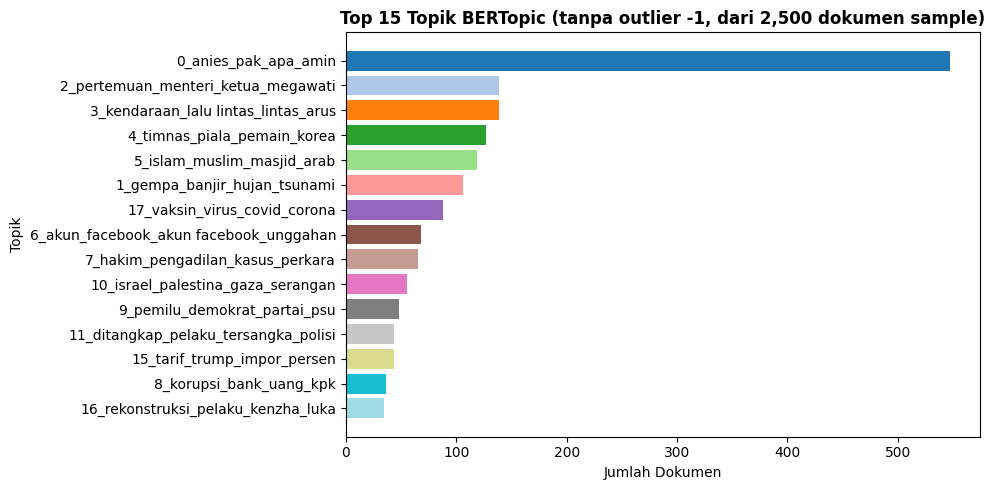

✓ Grafik distribusi topik disimpan: distribusi_topik_bertopic.png


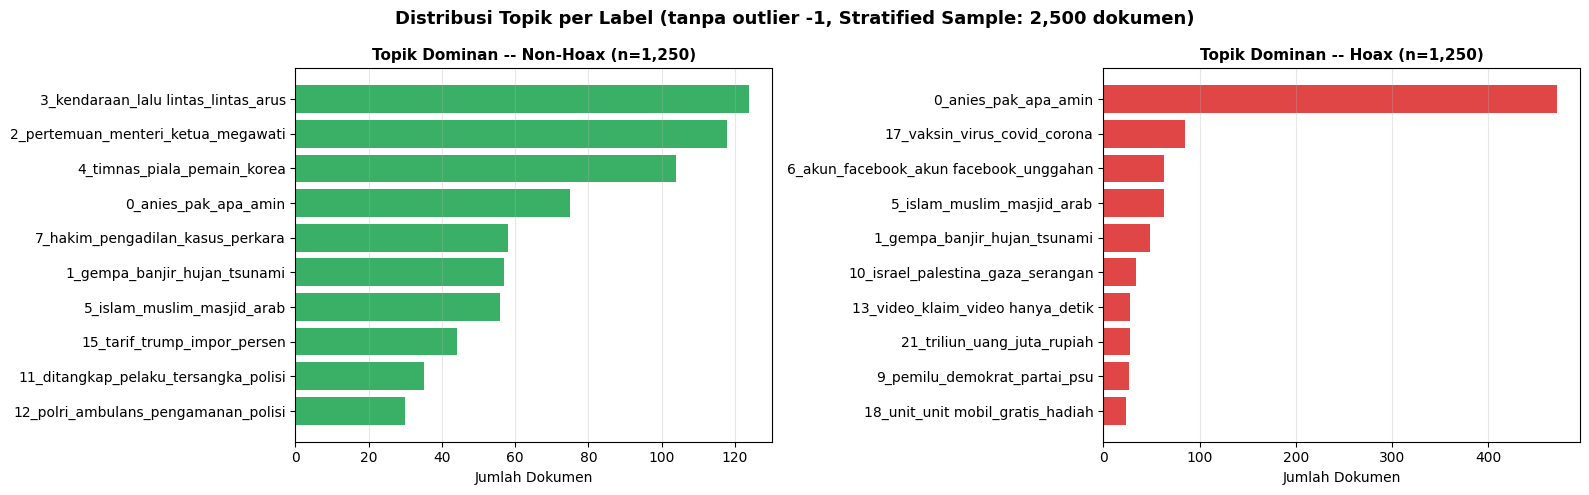

✓ Analisis topik per label disimpan: topik_per_label.png


In [25]:
# ================== SEL 25 -- Visualisasi Topik dan Analisis per Label ==================
# Membuat visualisasi distribusi topik final BERTopic setelah seleksi strategi outlier.
# - Distribusi topik: menampilkan Top-N topik valid berdasarkan jumlah dokumen (outlier -1 dikecualikan)
# - Analisis topik per label: membandingkan topik dominan pada dokumen hoax dan non-hoax
# - Stratified sampling: membatasi jumlah dokumen yang divisualisasikan dengan mempertahankan proporsi label
# Visualisasi ini memberikan gambaran keterkaitan topik dengan kategori hoax maupun non-hoax.
# ========================================================================================
# Percabangan: jika AKTIFKAN_BERTOPIC and model_topik is not None
if AKTIFKAN_BERTOPIC and model_topik is not None:
    # Menetapkan `info_viz` = memanggil `model_topik.get_topic_info().copy(...)`
    info_viz   = model_topik.get_topic_info().copy()
    # Menetapkan `info_valid` = memanggil `info_viz[info_viz['Topic'] != -1].copy(...)`
    info_valid = info_viz[info_viz["Topic"] != -1].copy()
    # Menetapkan `info_valid_main` = memanggil `info_valid.copy(...)`
    info_valid_main = info_valid.copy()

    # Siapkan data untuk visualisasi dengan batasan 2500 dokumen
    # Menetapkan `df_analisis` = memanggil `train_df_pra_oversampling[['text', 'label']].copy(...)`
    df_analisis = train_df_pra_oversampling[["text","label"]].copy()
    # Menetapkan `n_cocok` = memanggil `min(...)`
    n_cocok = min(len(df_analisis), len(id_topik))
    # Menetapkan `df_analisis` = memanggil `df_analisis.iloc[:n_cocok].copy(...)`
    df_analisis = df_analisis.iloc[:n_cocok].copy()
    # Menetapkan `df_analisis['topic_id']` = id_topik[:n_cocok]
    df_analisis["topic_id"] = id_topik[:n_cocok]
    # Menetapkan `jumlah_outlier_dokumen` = memanggil `int(...)`
    jumlah_outlier_dokumen = int((df_analisis["topic_id"] == -1).sum())
    # Menetapkan `df_analisis` = memanggil `df_analisis[df_analisis['topic_id'] != -1].copy(...)`
    df_analisis = df_analisis[df_analisis["topic_id"] != -1].copy()
    # Menetapkan `peta_nama_semua` = memanggil `dict(...)`
    peta_nama_semua = dict(zip(info_valid["Topic"], info_valid["Name"]))
    # Menetapkan `df_analisis['topic_name']` = memanggil `df_analisis['topic_id'].map(...)`
    df_analisis["topic_name"] = df_analisis["topic_id"].map(peta_nama_semua)

    # Stratified sampling untuk visualisasi (max 2500 dokumen)
    # Menetapkan `MAKS_DOKUMEN_VIZ` = 2500
    MAKS_DOKUMEN_VIZ = 2500
    # Memanggil `print(...)`
    print(f"\n[Visualisasi Topik] Total dokumen analisis utama: {len(df_analisis):,}")
    # Memanggil `print(...)`
    print(f"  Dokumen outlier (-1): {jumlah_outlier_dokumen:,} [tidak divisualisasikan]")
    # Percabangan: jika len(df_analisis) > MAKS_DOKUMEN_VIZ
    if len(df_analisis) > MAKS_DOKUMEN_VIZ:
        # Memanggil `print(...)`
        print(f"Sampling {MAKS_DOKUMEN_VIZ} dokumen (stratified by label)...")
        # Stratified sampling: pertahankan proporsi hoax:non-hoax menggunakan groupby
        # Menetapkan `sample_hoax` = memanggil `df_analisis[df_analisis['label'] == 1].sample(...)`
        sample_hoax = df_analisis[df_analisis["label"] == 1].sample(
            n=min(len(df_analisis[df_analisis["label"] == 1]), MAKS_DOKUMEN_VIZ // 2),
            random_state=42
        )
        # Menetapkan `sample_non_hoax` = memanggil `df_analisis[df_analisis['label'] == 0].sample(...)`
        sample_non_hoax = df_analisis[df_analisis["label"] == 0].sample(
            n=min(len(df_analisis[df_analisis["label"] == 0]), MAKS_DOKUMEN_VIZ // 2),
            random_state=42
        )
        # Menetapkan `df_analisis` = memanggil `pd.concat(...)`
        df_analisis = pd.concat([sample_hoax, sample_non_hoax], ignore_index=True)
        # Memanggil `print(...)`
        print(f"  Setelah sampling: {len(df_analisis):,} dokumen")
        # Memanggil `print(...)`
        print(f"    - Hoax: {len(df_analisis[df_analisis['label'] == 1]):,}")
        # Memanggil `print(...)`
        print(f"    - Non-Hoax: {len(df_analisis[df_analisis['label'] == 0]):,}")

    # Plot 1: Top-N topik berdasarkan jumlah dokumen (dari sample)
    # Percabangan: jika len(df_analisis) > 0 and len(info_valid_main) > 0
    if len(df_analisis) > 0 and len(info_valid_main) > 0:
        # Menetapkan `peta_nama` = memanggil `dict(...)`
        peta_nama = dict(zip(info_valid_main["Topic"], info_valid_main["Name"]))
        # Menetapkan `df_analisis['topic_name']` = memanggil `df_analisis['topic_id'].map(...)`
        df_analisis["topic_name"] = df_analisis["topic_id"].map(peta_nama)

        # Hitung distribusi topik dari sample
        # Menetapkan `topic_counts` = memanggil `df_analisis['topic_name'].value_counts(...)`
        topic_counts = df_analisis["topic_name"].value_counts()
        # Menetapkan `top_n` = memanggil `min(...)`
        top_n = min(15, len(topic_counts))
        # Menetapkan `top_topics` = memanggil `topic_counts.head(...)`
        top_topics = topic_counts.head(top_n)

        # Memanggil `plt.figure(...)`
        plt.figure(figsize=(10, max(5, top_n * 0.3)))
        # Memanggil `plt.barh(...)`
        plt.barh(top_topics.index.str[:45], top_topics.values,
                  color=plt.cm.tab20(np.linspace(0,1,len(top_topics))))
        # Memanggil `plt.xlabel(...)`
        # Memanggil `plt.ylabel(...)`
        plt.xlabel("Jumlah Dokumen"); plt.ylabel("Topik")
        # Memanggil `plt.title(...)`
        plt.title(f"Top {top_n} Topik BERTopic (tanpa outlier -1, dari {len(df_analisis):,} dokumen sample)",
                  fontsize=12, fontweight="bold")
        # Memanggil `plt.gca().invert_yaxis(...)`
        # Memanggil `plt.tight_layout(...)`
        plt.gca().invert_yaxis(); plt.tight_layout()
        # Memanggil `plt.savefig(...)`
        plt.savefig("distribusi_topik_bertopic.png", dpi=150, bbox_inches="tight")
        # Memanggil `plt.show(...)`
        plt.show()
        # Memanggil `print(...)`
        print(f"✓ Grafik distribusi topik disimpan: distribusi_topik_bertopic.png")

        # Plot 2: Analisis topik per label hoax/non-hoax
        # Menetapkan `top_k_a` = memanggil `min(...)`
        top_k_a = min(10, len(info_valid_main))
        # Menetapkan `(fig, axes)` = memanggil `plt.subplots(...)`
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        # Memanggil `fig.suptitle(...)`
        fig.suptitle(f"Distribusi Topik per Label (tanpa outlier -1, Stratified Sample: {len(df_analisis):,} dokumen)",
                     fontsize=13, fontweight="bold")

        # Perulangan: untuk setiap `(ax, lbl, judul, warna)` dalam [(axes[0], 0, 'Topik Dominan -- Non-Hoax',
        #   '#16A34A'), (a...
        for ax, lbl, judul, warna in [
            (axes[0], 0, "Topik Dominan -- Non-Hoax", "#16A34A"),
            (axes[1], 1, "Topik Dominan -- Hoax",     "#DC2626"),
        ]:
            # Menetapkan `subset` = df_analisis[df_analisis['label'] == lbl]
            subset = df_analisis[df_analisis["label"]==lbl]
            # Percabangan: jika len(subset) == 0
            if len(subset) == 0:
                # Memanggil `ax.text(...)`
                # Melanjutkan ke iterasi berikutnya (continue)
                ax.text(0.5, 0.5, "Tidak ada data", ha="center"); continue
            # Menetapkan `hitung` = memanggil `subset['topic_name'].value_counts().head(...)`
            hitung = subset["topic_name"].value_counts().head(top_k_a)
            # Memanggil `ax.barh(...)`
            ax.barh(hitung.index.str[:40], hitung.values, color=warna, alpha=0.85)
            # Memanggil `ax.set_title(...)`
            ax.set_title(f"{judul} (n={len(subset):,})", fontsize=11, fontweight="bold")
            # Memanggil `ax.set_xlabel(...)`
            ax.set_xlabel("Jumlah Dokumen")
            # Memanggil `ax.invert_yaxis(...)`
            # Memanggil `ax.grid(...)`
            ax.invert_yaxis(); ax.grid(axis="x", alpha=0.3)

        # Memanggil `plt.tight_layout(...)`
        plt.tight_layout()
        # Memanggil `plt.savefig(...)`
        plt.savefig("topik_per_label.png", dpi=150, bbox_inches="tight")
        # Memanggil `plt.show(...)`
        plt.show()
        # Memanggil `print(...)`
        print(f"✓ Analisis topik per label disimpan: topik_per_label.png")
else:
    # Memanggil `print(...)`
    print("Model BERTopic belum tersedia, visualisasi dilewati.")

## Evaluasi BERTopic dan c-TF-IDF [SEL 25b]

Menampilkan hasil kuantitatif topic modeling:
- Jumlah topik valid, jumlah outlier `-1`, dan outlier rate
- Topic `0` diperlakukan sebagai topik valid, bukan noise
- Distribusi dokumen per topik
- Top-10 kata per topik beserta skor c-TF-IDF
- Mapping kategori topik berdasarkan keyword overlap dan fallback scoring
- Coherence score sebagai pelengkap kualitas representasi kata topik
- DBCV dan `hdbscan_relative_validity` untuk membaca kualitas cluster berbasis densitas
- Topic exclusivity, category exclusivity, dan keyword coverage dari hasil c-TF-IDF
- Ekspor CSV/grafik untuk analisis dan dokumentasi hasil

Elbow method klasik tidak digunakan karena pipeline memakai BERTopic + UMAP + HDBSCAN, bukan KMeans/inertia. DBCV lebih sesuai untuk mengevaluasi cluster berbasis densitas; coherence tetap dipakai untuk membaca kualitas representasi kata topik.


  Evaluasi c-TF-IDF BERTopic
Topik valid utama : 79
Total dokumen     : 17,218
Dokumen outlier   : 3,771  (21.9%)

Distribusi Dokumen per Topik (analisis utama)
 Topic  Count                                                    Name
     0   2787                                    0_anies_pak_apa_amin
     1    541                            1_gempa_banjir_hujan_tsunami
     2    663                      2_pertemuan_menteri_ketua_megawati
     3    752                     3_kendaraan_lalu lintas_lintas_arus
     4    658                             4_timnas_piala_pemain_korea
     5    587                              5_islam_muslim_masjid_arab
     6    419                  6_akun_facebook_akun facebook_unggahan
     7    373                        7_hakim_pengadilan_kasus_perkara
     8    237                                 8_korupsi_bank_uang_kpk
     9    226                            9_pemilu_demokrat_partai_psu
    10    290                       10_israel_palestina_gaza_serangan

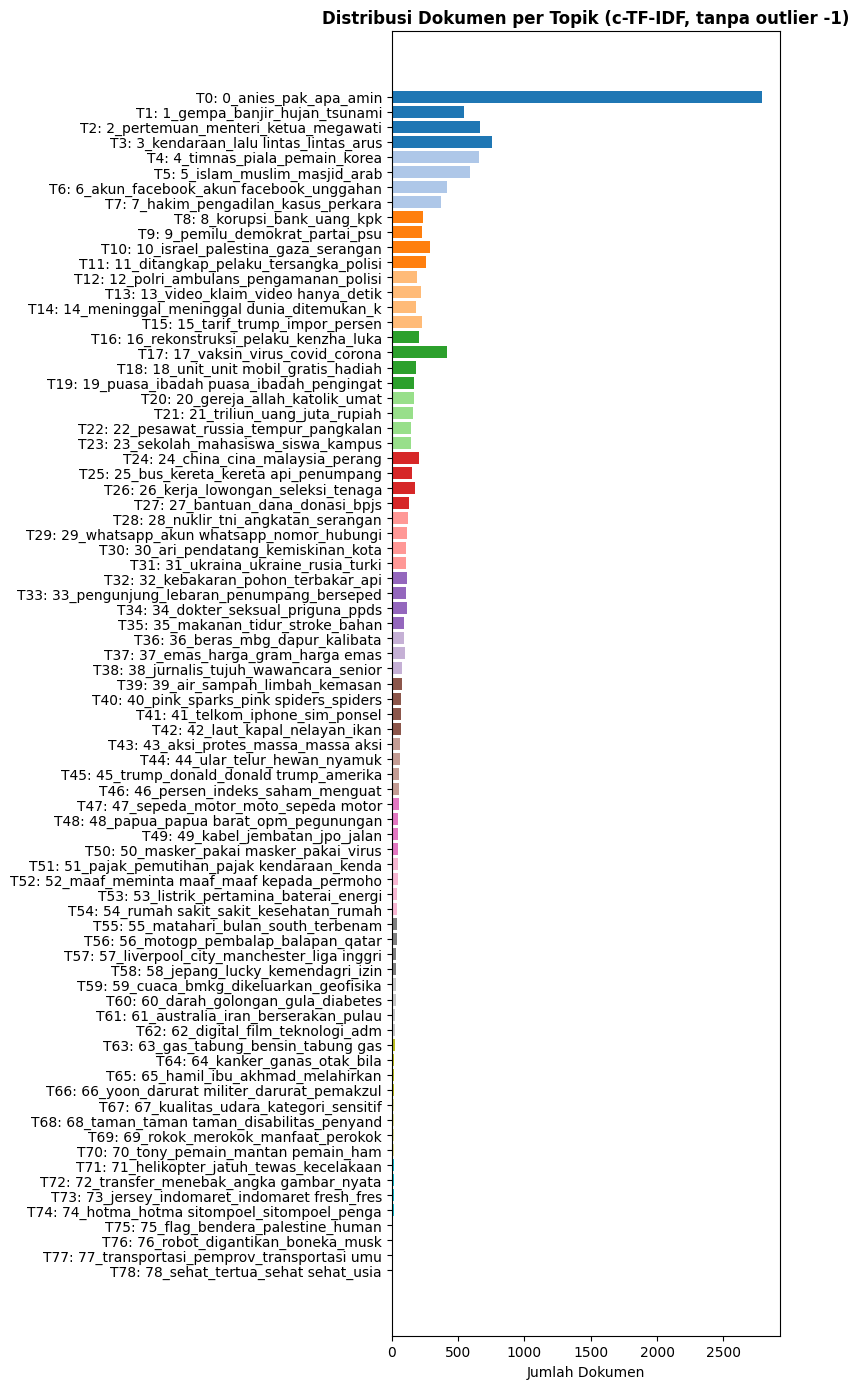

Grafik disimpan: ctfidf_distribusi_topik.png
Topik berlabel Topik Umum: 3/79

  MAPPING: Topic ID → Kategori
  Topic  0 → Politik                             | Top words: anies, pak, apa, amin, semoga
  Topic  1 → Bencana & Cuaca                     | Top words: gempa, banjir, hujan, tsunami, wilayah
  Topic  2 → Nasional & Pemerintahan             | Top words: pertemuan, menteri, ketua, megawati, wakil
  Topic  3 → Transportasi & Infrastruktur        | Top words: kendaraan, lalu lintas, lintas, arus, tol
  Topic  4 → Olahraga                            | Top words: timnas, piala, pemain, korea, megawati
  Topic  5 → Agama & Sosial                      | Top words: islam, muslim, masjid, arab, saudi
  Topic  6 → Klaim & Pemeriksaan Fakta           | Top words: akun, facebook, akun facebook, unggahan, tautan
  Topic  7 → Kriminal & Hukum                    | Top words: hakim, pengadilan, kasus, perkara, suap
  Topic  8 → Kriminal & Hukum                    | Top words: korupsi, bank, ua

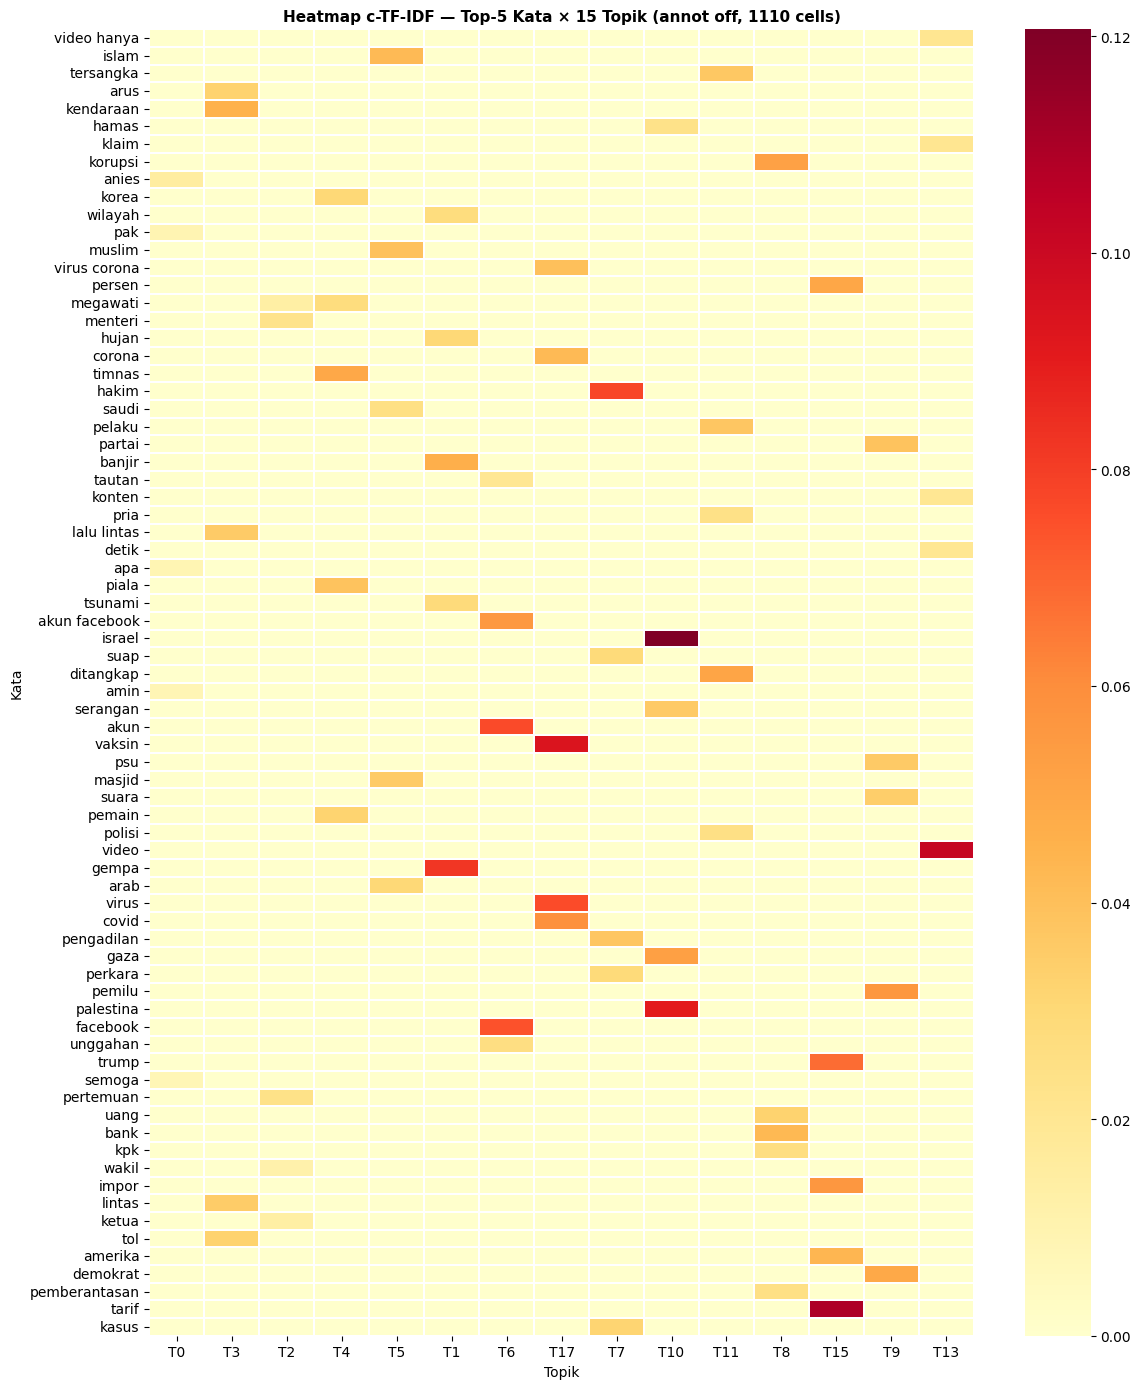

Heatmap c-TF-IDF disimpan: ctfidf_heatmap.png


In [26]:
# ================== SEL 26 -- Evaluasi c-TF-IDF BERTopic (OOM-Safe) ==================
# Menampilkan evaluasi kuantitatif hasil topic modeling secara OOM-safe.
# - Statistik topik: menghitung jumlah topik valid dan outlier, dengan Topic 0 tetap dihitung sebagai topik valid
# - Mapping kategori: memetakan setiap topik ke kategori tematik berdasarkan keyword overlap dan fallback scoring
# - Kata penting per topik: menampilkan kata dengan skor c-TF-IDF tertinggi tiap topik
# - Ekspor hasil: menyimpan tabel evaluasi ke CSV dan heatmap c-TF-IDF ke file gambar
# Kategori mapping pada sel ini menggunakan gabungan PETA_KATEGORI_SHARED dan KATEGORI_TAMBAHAN_BERTOPIC.
# =====================================================================================
# Percabangan: jika AKTIFKAN_BERTOPIC and model_topik is not None
if AKTIFKAN_BERTOPIC and model_topik is not None:
    # Menetapkan `info_topik` = memanggil `model_topik.get_topic_info().copy(...)`
    info_topik      = model_topik.get_topic_info().copy()
    # Menetapkan `id_topik_arr` = memanggil `np.array(...)`
    id_topik_arr    = np.array(id_topik)
    # Menetapkan `info_valid_eval` = memanggil `info_topik[info_topik['Topic'] != -1].copy(...)`
    info_valid_eval = info_topik[info_topik["Topic"] != -1].copy()
    # Menetapkan `info_valid_eval_main` = memanggil `info_valid_eval.copy(...)`
    info_valid_eval_main = info_valid_eval.copy()
    # Menetapkan `jumlah_topik_valid` = memanggil `len(...)`
    jumlah_topik_valid = len(info_valid_eval_main)
    # Menetapkan `jumlah_outlier` = memanggil `int(...)`
    jumlah_outlier     = int((id_topik_arr == -1).sum())

    # Memanggil `print(...)`
    print("=" * 65)
    # Memanggil `print(...)`
    print("  Evaluasi c-TF-IDF BERTopic")
    # Memanggil `print(...)`
    print("=" * 65)
    # Memanggil `print(...)`
    print(f"Topik valid utama : {jumlah_topik_valid}")
    # Memanggil `print(...)`
    print(f"Total dokumen     : {len(dokumen_topik):,}")
    # Memanggil `print(...)`
    print(f"Dokumen outlier   : {jumlah_outlier:,}  ({jumlah_outlier/len(dokumen_topik)*100:.1f}%)")

    # Distribusi dokumen per topik
    # Memanggil `print(...)`
    print("\nDistribusi Dokumen per Topik (analisis utama)")
    # Memanggil `print(...)`
    print(info_valid_eval_main[["Topic", "Count", "Name"]].to_string(index=False))

    # Menetapkan `tinggi_bar` = memanggil `min(...)`
    tinggi_bar = min(max(4, jumlah_topik_valid * 0.4), 14)
    # Menetapkan `(fig, ax)` = memanggil `plt.subplots(...)`
    fig, ax = plt.subplots(figsize=(8, tinggi_bar))
    # Menetapkan `bar_colors` = memanggil `plt.cm.tab20(...)`
    bar_colors = plt.cm.tab20(np.linspace(0, 1, len(info_valid_eval_main)))
    # Memanggil `ax.barh(...)`
    ax.barh(
        [f"T{r['Topic']}: {str(r['Name'])[:40]}" for _, r in info_valid_eval_main.iterrows()],
        info_valid_eval_main["Count"].values,
        color=bar_colors,
    )
    # Memanggil `ax.set_xlabel(...)`
    ax.set_xlabel("Jumlah Dokumen")
    # Memanggil `ax.set_title(...)`
    ax.set_title("Distribusi Dokumen per Topik (c-TF-IDF, tanpa outlier -1)", fontweight="bold")
    # Memanggil `ax.invert_yaxis(...)`
    # Memanggil `plt.tight_layout(...)`
    ax.invert_yaxis(); plt.tight_layout()
    # Memanggil `plt.savefig(...)`
    plt.savefig("ctfidf_distribusi_topik.png", dpi=120, bbox_inches="tight")
    # Memanggil `plt.show(...)`
    # Memanggil `plt.close(...)`
    # Memanggil `gc.collect(...)`
    plt.show(); plt.close(); gc.collect()
    # Memanggil `print(...)`
    print("Grafik disimpan: ctfidf_distribusi_topik.png")

    # Mapping Topic ID ke Kategori berdasarkan keyword overlap + fallback scoring ringan
    # Definisi fungsi `buat_mapping_topic_ke_kategori(model_topik, kategori_nama_list: List[str],
    #   daftar_tema_utama: List...)`
    def buat_mapping_topic_ke_kategori(
        model_topik,
        kategori_nama_list: List[str],
        daftar_tema_utama: List[List[str]],
        min_overlap: int = 1,
        top_n_words: int = 20,
        min_fallback_score: float = 0.02,
        tie_tolerance: float = 1e-9,
    ) -> Dict[int, str]:
        """Map BERTopic topic_id ke kategori terdekat dengan overlap exact + fallback scoring ringan.

        Decision rule:
        1. Exact overlap tetap prioritas utama.
        2. Mapping exact hanya valid jika overlap minimal 2 keyword.
        3. Jika overlap lemah (0 atau 1), gunakan fallback token scoring.
        4. Fallback hanya valid jika skornya cukup kuat; jika tidak, jatuh ke Topik Umum.
        5. Jika kandidat terbaik imbang/ambigu, jatuh ke Topik Umum agar tidak forced mapping.
        """
        # Menetapkan `info` = memanggil `model_topik.get_topic_info(...)`
        info = model_topik.get_topic_info()
        # Menetapkan `info_valid` = memanggil `info[info['Topic'] != -1].copy(...)`
        info_valid = info[info["Topic"] != -1].copy()
        # Menetapkan `overlap_floor` = memanggil `max(...)`
        overlap_floor = max(1, int(min_overlap))

        # Menetapkan `kategori_pairs` = hasil komprehensi -> [(nama, set(keywords)) for nama, keywords in
        #   zip(kategori_nama_list, daftar_t...
        kategori_pairs = [
            (nama, set(keywords))
            for nama, keywords in zip(kategori_nama_list, daftar_tema_utama)
        ]
        # Perulangan: untuk setiap `(nama, keywords)` dalam globals().get('KATEGORI_TAMBAHAN_BERTOPIC',
        #   {}).items()
        for nama, keywords in globals().get("KATEGORI_TAMBAHAN_BERTOPIC", {}).items():
            # Perulangan: untuk setiap `(idx, (nama_existing, keyword_existing))` dalam enumerate(kategori_pairs)
            for idx, (nama_existing, keyword_existing) in enumerate(kategori_pairs):
                # Percabangan: jika nama_existing == nama
                if nama_existing == nama:
                    # Menetapkan `kategori_pairs[idx]` = (nama_existing, set(keyword_existing) | set(keywords))
                    kategori_pairs[idx] = (nama_existing, set(keyword_existing) | set(keywords))
                    # Menghentikan perulangan (break)
                    break
            else:
                # Memanggil `kategori_pairs.append(...)`
                kategori_pairs.append((nama, set(keywords)))

        # Menetapkan `lexicon_per_kategori` = []
        lexicon_per_kategori = []
        # Perulangan: untuk setiap `(nama_kategori, seed_keywords)` dalam kategori_pairs
        for nama_kategori, seed_keywords in kategori_pairs:
            # Menetapkan `seed_set` = hasil komprehensi -> {kw.lower().strip() for kw in seed_keywords if
            #   str(kw).strip()}
            seed_set = {kw.lower().strip() for kw in seed_keywords if str(kw).strip()}
            # Menetapkan `token_set` = hasil komprehensi -> {token for kw in seed_set for token in kw.split() if
            #   token}
            token_set = {
                token
                for kw in seed_set
                for token in kw.split()
                if token
            }
            # Memanggil `lexicon_per_kategori.append(...)`
            lexicon_per_kategori.append({
                "nama": nama_kategori,
                "seed_set": seed_set,
                "token_set": token_set,
            })

        # Menetapkan `mapping` = {}
        mapping = {}
        # Perulangan: untuk setiap `(_, row)` dalam info_valid.iterrows()
        for _, row in info_valid.iterrows():
            # Menetapkan `topic_id` = memanggil `int(...)`
            topic_id = int(row["Topic"])
            # Menetapkan `top_words` = memanggil `model_topik.get_topic(...)`
            top_words = model_topik.get_topic(topic_id)

            # Percabangan: jika not top_words
            if not top_words:
                # Menetapkan `mapping[topic_id]` = 'Topik Umum'
                mapping[topic_id] = "Topik Umum"
                # Melanjutkan ke iterasi berikutnya (continue)
                continue

            # Menetapkan `topic_terms` = hasil komprehensi -> [(w.lower().strip(), float(score)) for w, score in
            #   top_words[:top_n_words] if...
            topic_terms = [
                (w.lower().strip(), float(score))
                for w, score in top_words[:top_n_words]
                if str(w).strip()
            ]

            # Menetapkan `best_kategori_idx` = -1
            best_kategori_idx = -1
            # Menetapkan `best_overlap` = 0
            best_overlap = 0
            # Menetapkan `best_overlap_score` = 0.0
            best_overlap_score = 0.0
            # Menetapkan `overlap_is_tie` = False
            overlap_is_tie = False

            # Perulangan: untuk setiap `(kat_idx, lexicon)` dalam enumerate(lexicon_per_kategori)
            for kat_idx, lexicon in enumerate(lexicon_per_kategori):
                # Menetapkan `overlap_count` = 0
                overlap_count = 0
                # Menetapkan `overlap_score` = 0.0
                overlap_score = 0.0
                # Perulangan: untuk setiap `(term, score)` dalam topic_terms
                for term, score in topic_terms:
                    # Percabangan: jika term in lexicon['seed_set']
                    if term in lexicon["seed_set"]:
                        # Memperbarui `overlap_count` (operator Add=) dengan 1
                        overlap_count += 1
                        # Memperbarui `overlap_score` (operator Add=) dengan score
                        overlap_score += score

                # Percabangan: jika overlap_count > best_overlap or (overlap_count == best_overlap and ...
                if (
                    overlap_count > best_overlap
                    or (overlap_count == best_overlap and overlap_score > best_overlap_score + tie_tolerance)
                ):
                    # Menetapkan `best_overlap` = overlap_count
                    best_overlap = overlap_count
                    # Menetapkan `best_overlap_score` = overlap_score
                    best_overlap_score = overlap_score
                    # Menetapkan `best_kategori_idx` = kat_idx
                    best_kategori_idx = kat_idx
                    # Menetapkan `overlap_is_tie` = False
                    overlap_is_tie = False
                # Percabangan: jika overlap_count == best_overlap and abs(overlap_score - best_overlap_...
                elif (
                    overlap_count == best_overlap
                    and abs(overlap_score - best_overlap_score) <= tie_tolerance
                    and overlap_count > 0
                ):
                    # Menetapkan `overlap_is_tie` = True
                    overlap_is_tie = True

            # Percabangan: jika best_kategori_idx != -1 and best_overlap >= overlap_floor and (not ...
            if best_kategori_idx != -1 and best_overlap >= overlap_floor and not overlap_is_tie:
                # Menetapkan `mapping[topic_id]` = lexicon_per_kategori[best_kategori_idx]['nama']
                mapping[topic_id] = lexicon_per_kategori[best_kategori_idx]["nama"]
                # Melanjutkan ke iterasi berikutnya (continue)
                continue

            # Menetapkan `best_fallback_idx` = -1
            best_fallback_idx = -1
            # Menetapkan `best_fallback_score` = 0.0
            best_fallback_score = 0.0
            # Menetapkan `fallback_is_tie` = False
            fallback_is_tie = False
            # Perulangan: untuk setiap `(kat_idx, lexicon)` dalam enumerate(lexicon_per_kategori)
            for kat_idx, lexicon in enumerate(lexicon_per_kategori):
                # Menetapkan `fallback_score` = 0.0
                fallback_score = 0.0
                # Perulangan: untuk setiap `(term, score)` dalam topic_terms
                for term, score in topic_terms:
                    # Menetapkan `term_tokens` = hasil komprehensi -> [token for token in term.split() if token]
                    term_tokens = [token for token in term.split() if token]
                    # Menetapkan `token_hits` = memanggil `sum(...)`
                    token_hits = sum(
                        1 for token in term_tokens
                        if token in lexicon["token_set"]
                    )
                    # Percabangan: jika token_hits > 0
                    if token_hits > 0:
                        # Memperbarui `fallback_score` (operator Add=) dengan score * token_hits
                        fallback_score += score * token_hits

                # Percabangan: jika fallback_score > best_fallback_score + tie_tolerance
                if fallback_score > best_fallback_score + tie_tolerance:
                    # Menetapkan `best_fallback_score` = fallback_score
                    best_fallback_score = fallback_score
                    # Menetapkan `best_fallback_idx` = kat_idx
                    best_fallback_idx = kat_idx
                    # Menetapkan `fallback_is_tie` = False
                    fallback_is_tie = False
                # Percabangan: jika fallback_score > 0 and abs(fallback_score - best_fallback_score) <=...
                elif fallback_score > 0 and abs(fallback_score - best_fallback_score) <= tie_tolerance:
                    # Menetapkan `fallback_is_tie` = True
                    fallback_is_tie = True

            # Percabangan: jika best_fallback_idx != -1 and (not fallback_is_tie) and (best_fallbac...
            if best_fallback_idx != -1 and not fallback_is_tie and best_fallback_score >= min_fallback_score:
                # Menetapkan `mapping[topic_id]` = lexicon_per_kategori[best_fallback_idx]['nama']
                mapping[topic_id] = lexicon_per_kategori[best_fallback_idx]["nama"]
            else:
                # Menetapkan `mapping[topic_id]` = 'Topik Umum'
                mapping[topic_id] = "Topik Umum"

        # Mengembalikan mapping
        return mapping

    # Buat mapping topik
    # Menetapkan `kategori_mapping` = memanggil `buat_mapping_topic_ke_kategori(...)`
    kategori_mapping = buat_mapping_topic_ke_kategori(
        model_topik,
        kategori_nama_list,
        daftar_tema_utama,
        min_overlap=1,
        top_n_words=20,
        min_fallback_score=0.02,
    )
    # Menetapkan `jumlah_topik_umum` = memanggil `sum(...)`
    jumlah_topik_umum = sum(1 for kategori in kategori_mapping.values() if kategori == "Topik Umum")
    # Memanggil `print(...)`
    print(f"Topik berlabel Topik Umum: {jumlah_topik_umum}/{len(kategori_mapping)}")

    # Memanggil `print(...)`
    print("\n" + "=" * 70)
    # Memanggil `print(...)`
    print("  MAPPING: Topic ID → Kategori")
    # Memanggil `print(...)`
    print("=" * 70)
    # Perulangan: untuk setiap `topic_id` dalam sorted(kategori_mapping.keys())
    for topic_id in sorted(kategori_mapping.keys()):
        # Menetapkan `kategori` = kategori_mapping[topic_id]
        kategori = kategori_mapping[topic_id]
        # Menetapkan `top_words` = model_topik.get_topic(topic_id) or []
        top_words = model_topik.get_topic(topic_id) or []
        # Menetapkan `top_words_str` = memanggil `', '.join(...)`
        top_words_str = ", ".join([w for w, _ in top_words[:5]])
        # Memanggil `print(...)`
        print(f"  Topic {topic_id:2d} → {kategori:35s} | Top words: {top_words_str[:60]}")
    # Memanggil `print(...)`
    print("=" * 70)

    # Kata penting per topik dengan kategori coverage
    # Memanggil `print(...)`
    print("\nKata Penting per Topik (Top-10, c-TF-IDF)")

    # Menetapkan `peta_kategori_keywords` = hasil komprehensi -> {name: set(keywords) for name, keywords
    #   in PETA_KATEGORI_SHARED}
    peta_kategori_keywords = {
        name: set(keywords) for name, keywords in PETA_KATEGORI_SHARED
    }
    # Perulangan: untuk setiap `(nama, keywords)` dalam globals().get('KATEGORI_TAMBAHAN_BERTOPIC',
    #   {}).items()
    for nama, keywords in globals().get("KATEGORI_TAMBAHAN_BERTOPIC", {}).items():
        # Memanggil `peta_kategori_keywords.setdefault(nama, set()).update(...)`
        peta_kategori_keywords.setdefault(nama, set()).update(set(keywords))

    # Menetapkan `baris_ctfidf` = []
    baris_ctfidf = []
    # Perulangan: untuk setiap `(_, baris_info)` dalam info_valid_eval.iterrows()
    for _, baris_info in info_valid_eval.iterrows():
        # Menetapkan `t_id` = memanggil `int(...)`
        t_id = int(baris_info["Topic"])
        # Menetapkan `nama_topik` = memanggil `str(...)`
        nama_topik = str(baris_info["Name"])
        # Menetapkan `kategori` = memanggil `kategori_mapping.get(...)`
        kategori = kategori_mapping.get(t_id, "Topik Umum")
        # Menetapkan `kata_skor` = model_topik.get_topic(t_id) or []
        kata_skor = model_topik.get_topic(t_id) or []

        # Ambil keyword kategori lengkap
        # Menetapkan `kategori_keywords` = memanggil `peta_kategori_keywords.get(...)`
        kategori_keywords = peta_kategori_keywords.get(kategori, set())
        # Menetapkan `kategori_keywords_lower` = hasil komprehensi -> {kw.lower() for kw in kategori_keywords}
        kategori_keywords_lower = {kw.lower() for kw in kategori_keywords}

        # Hitung keyword ditemukan di top 10 words
        # Menetapkan `top_words_list` = hasil komprehensi -> [str(kata).lower().strip() for kata, _ in
        #   kata_skor[:10]]
        top_words_list = [str(kata).lower().strip() for kata, _ in kata_skor[:10]]
        # Menetapkan `top_words_token` = hasil komprehensi -> {token for kata in top_words_list for token in
        #   kata.split() if token}
        top_words_token = {token for kata in top_words_list for token in kata.split() if token}
        # Menetapkan `keyword_ditemukan` = hasil komprehensi -> {keyword for keyword in
        #   kategori_keywords_lower if keyword in top_words_list ...
        keyword_ditemukan = {
            keyword for keyword in kategori_keywords_lower
            if keyword in top_words_list
            or any(token in top_words_token for token in keyword.split())
        }

        # Hitung coverage
        # Menetapkan `coverage_count` = memanggil `len(...)`
        coverage_count = len(keyword_ditemukan)
        # Menetapkan `total_keyword` = memanggil `len(...)`
        total_keyword = len(kategori_keywords)
        # Menetapkan `coverage_str` = f'{coverage_count}/{total_keyword}'
        coverage_str = f"{coverage_count}/{total_keyword}"

        # String untuk CSV
        # Menetapkan `keyword_kategori_str` = memanggil `'|'.join(...)`
        keyword_kategori_str = "|".join(sorted(kategori_keywords))
        # Menetapkan `keyword_ditemukan_str` = memanggil `'|'.join(...)`
        keyword_ditemukan_str = "|".join(sorted(keyword_ditemukan))

        # Add detail rows untuk setiap kata
        # Perulangan: untuk setiap `(rank, (kata, skor))` dalam enumerate(kata_skor[:10], start=1)
        for rank, (kata, skor) in enumerate(kata_skor[:10], start=1):
            # Memanggil `baris_ctfidf.append(...)`
            baris_ctfidf.append({
                "Topik_ID": t_id,
                "Kategori": kategori,
                "Nama_Topik": nama_topik[:40],
                "Rank": rank,
                "Kata": kata,
                "Skor_cTFIDF": round(float(skor), 6),
                "Keyword_Ditemukan": keyword_ditemukan_str,
                "Coverage": coverage_str,
                "Keyword_Kategori_Lengkap": keyword_kategori_str,
            })
    # Menetapkan `df_ctfidf` = memanggil `pd.DataFrame(...)`
    df_ctfidf = pd.DataFrame(baris_ctfidf)

    # Menetapkan `df_ctfidf` = df_ctfidf[['Topik_ID', 'Kategori', 'Nama_Topik', 'Rank', 'Kata',
    #   'Skor_cTFIDF', 'Keywor...
    df_ctfidf = df_ctfidf[[
        "Topik_ID", "Kategori", "Nama_Topik", "Rank", "Kata", "Skor_cTFIDF",
        "Keyword_Ditemukan", "Coverage", "Keyword_Kategori_Lengkap"
    ]]
    # Menetapkan `df_ctfidf` = memanggil `df_ctfidf.sort_values(...)`
    df_ctfidf = df_ctfidf.sort_values(["Topik_ID", "Rank"])

    # Memanggil `print(...)`
    print(df_ctfidf.head(30).to_string(index=False))
    # Memanggil `df_ctfidf.to_csv(...)`
    df_ctfidf.to_csv("evaluasi_ctfidf_topik.csv", index=False, encoding="utf-8-sig")
    # Menghapus baris_ctfidf
    del baris_ctfidf
    # Memanggil `gc.collect(...)`
    gc.collect()

    # Memanggil `print(...)`
    print(f"\nCSV disimpan: evaluasi_ctfidf_topik.csv")
    # Memanggil `print(...)`
    print(f"  Total baris: {len(df_ctfidf):,}")

    # Heatmap skor c-TF-IDF dengan OOM-safe optimizations
    # Menetapkan `MAKS_TOPIK_HEATMAP` = 15
    MAKS_TOPIK_HEATMAP = 15
    # Percabangan: jika jumlah_topik_valid > 0
    if jumlah_topik_valid > 0:
        # Menetapkan `info_heatmap` = memanggil `info_valid_eval_main.nlargest(...)`
        info_heatmap = info_valid_eval_main.nlargest(MAKS_TOPIK_HEATMAP, "Count")
        # Menetapkan `top5_per_topik` = {}
        top5_per_topik = {}
        # Perulangan: untuk setiap `t_id_k` dalam info_heatmap['Topic'].tolist()
        for t_id_k in info_heatmap["Topic"].tolist():
            # Menetapkan `kt` = model_topik.get_topic(int(t_id_k)) or []
            kt = model_topik.get_topic(int(t_id_k)) or []
            # Menetapkan `top5_per_topik[f'T{t_id_k}']` = hasil komprehensi -> {w: float(s) for w, s in kt[:5]}
            top5_per_topik[f"T{t_id_k}"] = {w: float(s) for w, s in kt[:5]}

        # Menetapkan `semua_kata` = list({w for d in top5_per_topik.values() for w in d})[:75]
        semua_kata = list({w for d in top5_per_topik.values() for w in d})[:75]
        # Menetapkan `n_row` = memanggil `len(...)`
        # Menetapkan `n_col` = memanggil `len(...)`
        n_row = len(semua_kata); n_col = len(top5_per_topik)
        # Menetapkan `n_cell` = n_row * n_col
        n_cell = n_row * n_col

        # Menetapkan `df_heatmap` = memanggil `pd.DataFrame(...)`
        df_heatmap = pd.DataFrame(
            {t: [top5_per_topik[t].get(w, 0.0) for w in semua_kata] for t in top5_per_topik},
            index=semua_kata,
        )

        # Menetapkan `lebar_h` = memanggil `min(...)`
        lebar_h = min(max(8, n_col * 0.8), 20)
        # Menetapkan `tinggi_h` = memanggil `min(...)`
        tinggi_h = min(max(6, n_row * 0.32), 14)
        # Menetapkan `aktifkan_annot` = n_cell <= 200
        aktifkan_annot = n_cell <= 200

        # Menetapkan `(fig, ax)` = memanggil `plt.subplots(...)`
        fig, ax = plt.subplots(figsize=(lebar_h, tinggi_h))
        # Memanggil `sns.heatmap(...)`
        sns.heatmap(
            df_heatmap,
            annot=aktifkan_annot,
            fmt=".4f" if aktifkan_annot else "",
            cmap="YlOrRd",
            linewidths=0.2,
            ax=ax,
            annot_kws={"size": 6} if aktifkan_annot else {},
        )
        # Menetapkan `judul_note` = ekspresi kondisional -> '' if aktifkan_annot else f' (annot off, {n_cell}
        #   cells)'
        judul_note = "" if aktifkan_annot else f" (annot off, {n_cell} cells)"
        # Memanggil `ax.set_title(...)`
        ax.set_title(
            f"Heatmap c-TF-IDF — Top-5 Kata × {n_col} Topik{judul_note}",
            fontsize=11, fontweight="bold",
        )
        # Memanggil `ax.set_xlabel(...)`
        # Memanggil `ax.set_ylabel(...)`
        ax.set_xlabel("Topik"); ax.set_ylabel("Kata")
        # Memanggil `plt.tight_layout(...)`
        plt.tight_layout()
        # Memanggil `plt.savefig(...)`
        plt.savefig("ctfidf_heatmap.png", dpi=100, bbox_inches="tight")
        # Memanggil `plt.show(...)`
        # Memanggil `plt.close(...)`
        plt.show(); plt.close()

        # Menghapus df_heatmap, top5_per_topik, semua_kata, info_heatmap
        del df_heatmap, top5_per_topik, semua_kata, info_heatmap
        # Memanggil `gc.collect(...)`
        gc.collect()
        # Percabangan: jika torch.cuda.is_available()
        # Memanggil `torch.cuda.empty_cache(...)`
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        # Memanggil `print(...)`
        print(f"Heatmap c-TF-IDF disimpan: ctfidf_heatmap.png")
else:
    # Memanggil `print(...)`
    print("Model BERTopic belum tersedia, evaluasi c-TF-IDF dilewati.")

In [27]:
# ================== SEL 26b -- Evaluasi Numerik BERTopic Tambahan ==================
# Menghitung metrik numerik tambahan untuk menilai kualitas hasil topic modeling.
# - Coherence (c_v): menilai kualitas representasi kata pada topik final menggunakan gensim CoherenceModel
# - DBCV: menilai validitas density cluster pada embedding UMAP dan label topik final
# - Statistik topik & outlier: merangkum jumlah topik, outlier rate, dan topik dominan ke dalam satu ringkasan
# Hasil evaluasi numerik ini dibaca secara komparatif antar-kandidat, bukan sebagai nilai mutlak tunggal.
# ===================================================================================
# Variabel/field `ringkasan_bertopic_eval` (tipe Dict[str, object]) = {'status': 'UNKNOWN', 'catatan':
#   []}
ringkasan_bertopic_eval: Dict[str, object] = {
    "status": "UNKNOWN",
    "catatan": [],
}

# Percabangan: jika AKTIFKAN_BERTOPIC and model_topik is not None
if AKTIFKAN_BERTOPIC and model_topik is not None:
    # Menetapkan `info_eval` = memanggil `model_topik.get_topic_info().copy(...)`
    info_eval = model_topik.get_topic_info().copy()
    # Menetapkan `id_topik_arr_eval` = memanggil `np.array(...)`
    id_topik_arr_eval = np.array(id_topik)

    # Menetapkan `info_non_outlier` = memanggil `info_eval[info_eval['Topic'] != -1].copy(...)`
    info_non_outlier = info_eval[info_eval["Topic"] != -1].copy()
    # Menetapkan `info_main` = memanggil `info_non_outlier.copy(...)`
    info_main = info_non_outlier.copy()
    # Menetapkan `topik_terbesar` = ekspresi kondisional -> info_main.nlargest(1, 'Count') if
    #   len(info_main) else pd.DataFrame()
    topik_terbesar = info_main.nlargest(1, "Count") if len(info_main) else pd.DataFrame()
    # Menetapkan `topik_terbesar_id` = ekspresi kondisional -> int(topik_terbesar.iloc[0]['Topic']) if
    #   len(topik_terbesar) else 'UNKNOWN'
    topik_terbesar_id = int(topik_terbesar.iloc[0]["Topic"]) if len(topik_terbesar) else "UNKNOWN"
    # Menetapkan `topik_terbesar_count` = ekspresi kondisional -> int(topik_terbesar.iloc[0]['Count']) if
    #   len(topik_terbesar) else 0
    topik_terbesar_count = int(topik_terbesar.iloc[0]["Count"]) if len(topik_terbesar) else 0
    # Menetapkan `topik_terbesar_rate` = ekspresi kondisional -> topik_terbesar_count /
    #   len(id_topik_arr_eval) if len(id_topik_arr_eval) else np.nan
    topik_terbesar_rate = (topik_terbesar_count / len(id_topik_arr_eval)) if len(id_topik_arr_eval) else np.nan

    # Menetapkan `total_dokumen_bertopic` = ekspresi kondisional -> int(len(dokumen_topik)) if
    #   'dokumen_topik' in globals() else int(len(id_topik_arr_eval))
    total_dokumen_bertopic = int(len(dokumen_topik)) if "dokumen_topik" in globals() else int(len(id_topik_arr_eval))
    # Menetapkan `jumlah_outlier_eval` = memanggil `int(...)`
    jumlah_outlier_eval = int((id_topik_arr_eval == -1).sum())
    # Menetapkan `outlier_rate_eval` = ekspresi kondisional -> jumlah_outlier_eval /
    #   total_dokumen_bertopic if total_dokumen_bertopic else np.nan
    outlier_rate_eval = (jumlah_outlier_eval / total_dokumen_bertopic) if total_dokumen_bertopic else np.nan

    # Memanggil `ringkasan_bertopic_eval.update(...)`
    ringkasan_bertopic_eval.update({
        "status": "OK",
        "total_dokumen": total_dokumen_bertopic,
        "jumlah_topik_final": int(len(info_non_outlier)),
        "jumlah_topik_utama": int(len(info_main)),
        "jumlah_outlier": jumlah_outlier_eval,
        "outlier_rate": float(outlier_rate_eval) if not np.isnan(outlier_rate_eval) else "UNKNOWN",
        "topik_terbesar_id": topik_terbesar_id,
        "topik_terbesar_count": topik_terbesar_count,
        "topik_terbesar_rate": float(topik_terbesar_rate) if not np.isnan(topik_terbesar_rate) else "UNKNOWN",
        "coherence_c_v": "UNKNOWN",
        "coherence_status": "UNKNOWN",
        "coherence_dokumen_dipakai": "UNKNOWN",
        "coherence_topik_dipakai": "UNKNOWN",
        "dbcv_score": "UNKNOWN",
        "dbcv_mode": "UNKNOWN",
        "dbcv_status": "UNKNOWN - DBCV belum dihitung",
        "dbcv_titik_dipakai": "UNKNOWN",
        "dbcv_cluster_dipakai": "UNKNOWN",
        "hdbscan_relative_validity": "UNKNOWN",
        "hdbscan_relative_validity_status": "UNKNOWN",
    })

    # Menetapkan `hdbscan_model_eval` = memanggil `getattr(...)`
    hdbscan_model_eval = getattr(model_topik, "hdbscan_model", None)
    # Blok try: menjalankan kode di bawah dengan penanganan except
    try:
        # Menetapkan `nilai_relative` = memanggil `getattr(...)`
        nilai_relative = getattr(hdbscan_model_eval, "relative_validity_")
        # Memanggil `ringkasan_bertopic_eval.update(...)`
        ringkasan_bertopic_eval.update({
            "hdbscan_relative_validity": float(nilai_relative),
            "hdbscan_relative_validity_status": "OK",
        })
    # Penanganan except untuk Exception sebagai `exc`
    except Exception as exc:
        # Menetapkan `ringkasan_bertopic_eval['hdbscan_relative_valid...` = f'UNKNOWN - {exc}'
        ringkasan_bertopic_eval["hdbscan_relative_validity_status"] = f"UNKNOWN - {exc}"

    # Statistik topic representation dari df_ctfidf jika tersedia; fallback ke CSV hasil runtime.
    # Menetapkan `df_ctfidf_eval` = memanggil `globals().get(...)`
    df_ctfidf_eval = globals().get("df_ctfidf", None)
    # Percabangan: jika df_ctfidf_eval is None
    if df_ctfidf_eval is None:
        # Perulangan: untuk setiap `kandidat_csv` dalam ['evaluasi_ctfidf_topik.csv',
        #   '/content/evaluasi_ctfidf_t...
        for kandidat_csv in ["evaluasi_ctfidf_topik.csv", "/content/evaluasi_ctfidf_topik.csv"]:
            # Percabangan: jika os.path.exists(kandidat_csv)
            if os.path.exists(kandidat_csv):
                # Menetapkan `df_ctfidf_eval` = memanggil `pd.read_csv(...)`
                df_ctfidf_eval = pd.read_csv(kandidat_csv)
                # Menghentikan perulangan (break)
                break

    # Percabangan: jika df_ctfidf_eval is not None and len(df_ctfidf_eval) > 0
    if df_ctfidf_eval is not None and len(df_ctfidf_eval) > 0:
        # Menetapkan `df_ctfidf_eval` = memanggil `df_ctfidf_eval.copy(...)`
        df_ctfidf_eval = df_ctfidf_eval.copy()
        # Menetapkan `kata_per_topik` = memanggil `df_ctfidf_eval.groupby('Kata')['Topik_ID'].nunique(...)`
        kata_per_topik = df_ctfidf_eval.groupby("Kata")["Topik_ID"].nunique()
        # Menetapkan `kata_per_kategori` = memanggil `df_ctfidf_eval.groupby('Kata')['Kategori'].nunique(...)`
        kata_per_kategori = df_ctfidf_eval.groupby("Kata")["Kategori"].nunique()
        # Menetapkan `topik_coverage` = memanggil
        #   `df_ctfidf_eval.drop_duplicates('Topik_ID')['Coverage'].as...(...)`
        topik_coverage = df_ctfidf_eval.drop_duplicates("Topik_ID")["Coverage"].astype(str)

        # Definisi fungsi `_parse_coverage_ratio(nilai: str)`
        def _parse_coverage_ratio(nilai: str):
            # Percabangan: jika '/' not in nilai
            if "/" not in nilai:
                # Mengembalikan np.nan
                return np.nan
            # Menetapkan `(kiri, kanan)` = memanggil `nilai.split(...)`
            kiri, kanan = nilai.split("/", 1)
            # Blok try: menjalankan kode di bawah dengan penanganan except
            try:
                # Menetapkan `(kiri, kanan)` = (int(kiri), int(kanan))
                kiri, kanan = int(kiri), int(kanan)
                # Mengembalikan ekspresi kondisional -> kiri / kanan if kanan else np.nan
                return kiri / kanan if kanan else np.nan
            # Penanganan except untuk ValueError
            except ValueError:
                # Mengembalikan np.nan
                return np.nan

        # Menetapkan `coverage_ratio` = memanggil `topik_coverage.map(...)`
        coverage_ratio = topik_coverage.map(_parse_coverage_ratio)
        # Menetapkan `topik_kategori_eval` = df_ctfidf_eval.drop_duplicates('Topik_ID')[['Topik_ID',
        #   'Kategori']]
        topik_kategori_eval = df_ctfidf_eval.drop_duplicates("Topik_ID")[["Topik_ID", "Kategori"]]
        # Memanggil `ringkasan_bertopic_eval.update(...)`
        ringkasan_bertopic_eval.update({
            "ctfidf_baris": int(df_ctfidf_eval.shape[0]),
            "ctfidf_kolom": int(df_ctfidf_eval.shape[1]),
            "ctfidf_topik_unik": int(df_ctfidf_eval["Topik_ID"].nunique()),
            "ctfidf_kategori_unik": int(df_ctfidf_eval["Kategori"].nunique()),
            "kata_frasa_unik": int(df_ctfidf_eval["Kata"].nunique()),
            "kata_eksklusif_topik": int((kata_per_topik == 1).sum()),
            "topic_exclusivity_rate": float((kata_per_topik == 1).mean()),
            "kata_eksklusif_kategori": int((kata_per_kategori == 1).sum()),
            "category_exclusivity_rate": float((kata_per_kategori == 1).mean()),
            "jumlah_topik_umum": int((topik_kategori_eval["Kategori"] == "Topik Umum").sum()),
            "topik_dengan_keyword_hit": int((coverage_ratio.fillna(0) > 0).sum()),
            "rata_rata_coverage_keyword": float(coverage_ratio.mean()) if coverage_ratio.notna().any() else "UNKNOWN",
        })
    else:
        # Memanggil `ringkasan_bertopic_eval['catatan'].append(...)`
        ringkasan_bertopic_eval["catatan"].append("UNKNOWN: df_ctfidf/evaluasi_ctfidf_topik.csv belum tersedia pada state notebook.")

    # DBCV: evaluasi density cluster pada embedding UMAP menggunakan label topik final.
    # Blok try: menjalankan kode di bawah dengan penanganan except
    try:
        # Impor dari `hdbscan.validity`: validity_index
        from hdbscan.validity import validity_index

        # Menetapkan `hdbscan_model_eval` = memanggil `getattr(...)`
        hdbscan_model_eval = getattr(model_topik, "hdbscan_model", None)
        # Menetapkan `labels_hdbscan` = memanggil `getattr(...)`
        labels_hdbscan = getattr(hdbscan_model_eval, "labels_", None)
        # Percabangan: jika labels_hdbscan is None and 'hdb_m' in globals()
        if labels_hdbscan is None and "hdb_m" in globals():
            # Menetapkan `labels_hdbscan` = memanggil `getattr(...)`
            labels_hdbscan = getattr(hdb_m, "labels_", None)
        # Percabangan: jika labels_hdbscan is None
        if labels_hdbscan is None:
            # Melempar exception ValueError('label HDBSCAN tidak tersedia')
            raise ValueError("label HDBSCAN tidak tersedia")

        # Menetapkan `reduced_embeddings` = None
        reduced_embeddings = None
        # Menetapkan `umap_model_eval` = memanggil `getattr(...)`
        umap_model_eval = getattr(model_topik, "umap_model", None)
        # Percabangan: jika umap_model_eval is not None and hasattr(umap_model_eval, 'embedding_')
        if umap_model_eval is not None and hasattr(umap_model_eval, "embedding_"):
            # Menetapkan `reduced_embeddings` = memanggil `np.asarray(...)`
            reduced_embeddings = np.asarray(umap_model_eval.embedding_)
        # Percabangan: jika 'umap_m' in globals() and hasattr(umap_m, 'embedding_')
        elif "umap_m" in globals() and hasattr(umap_m, "embedding_"):
            # Menetapkan `reduced_embeddings` = memanggil `np.asarray(...)`
            reduced_embeddings = np.asarray(umap_m.embedding_)
        # Percabangan: jika 'umap_m' in globals() and 'emb' in globals()
        elif "umap_m" in globals() and "emb" in globals():
            # Menetapkan `reduced_embeddings` = memanggil `np.asarray(...)`
            reduced_embeddings = np.asarray(umap_m.transform(emb))

        # Percabangan: jika reduced_embeddings is None
        if reduced_embeddings is None:
            # Melempar exception ValueError('reduced embedding UMAP tidak tersedia')
            raise ValueError("reduced embedding UMAP tidak tersedia")

        # Menetapkan `labels_hdbscan` = memanggil `np.asarray(...)`
        labels_hdbscan = np.asarray(labels_hdbscan)
        # Menetapkan `labels_dbcv` = ekspresi kondisional -> id_topik_arr_eval if len(id_topik_arr_eval) ==
        #   len(reduced_embeddings) else labels_hdbscan
        labels_dbcv = id_topik_arr_eval if len(id_topik_arr_eval) == len(reduced_embeddings) else labels_hdbscan
        # Menetapkan `labels_dbcv` = memanggil `np.asarray(...)`
        labels_dbcv = np.asarray(labels_dbcv)
        # Percabangan: jika len(reduced_embeddings) != len(labels_dbcv)
        if len(reduced_embeddings) != len(labels_dbcv):
            # Melempar exception ValueError('jumlah reduced embedding dan label DBCV tidak sama')
            raise ValueError("jumlah reduced embedding dan label DBCV tidak sama")

        # Menetapkan `DBCV_MAKS_DATA_FULL` = 3000
        DBCV_MAKS_DATA_FULL = 3000
        # Menetapkan `DBCV_MAKS_DATA_SAMPLE` = 3000
        DBCV_MAKS_DATA_SAMPLE = 3000
        # Menetapkan `mode_dbcv` = 'full'
        mode_dbcv = "full"
        # Menetapkan `indeks_dbcv` = memanggil `np.arange(...)`
        indeks_dbcv = np.arange(len(labels_dbcv))

        # Percabangan: jika len(labels_dbcv) > DBCV_MAKS_DATA_FULL
        if len(labels_dbcv) > DBCV_MAKS_DATA_FULL:
            # Menetapkan `mode_dbcv` = 'sampled'
            mode_dbcv = "sampled"
            # Menetapkan `rng_dbcv` = memanggil `np.random.default_rng(...)`
            rng_dbcv = np.random.default_rng(SEED_BERTOPIC)
            # Menetapkan `indeks_pilihan` = []
            indeks_pilihan = []
            # Menetapkan `cluster_labels` = hasil komprehensi -> [lab for lab in np.unique(labels_dbcv) if lab !=
            #   -1]
            cluster_labels = [lab for lab in np.unique(labels_dbcv) if lab != -1]
            # Menetapkan `per_cluster` = memanggil `max(...)`
            per_cluster = max(5, DBCV_MAKS_DATA_SAMPLE // max(len(cluster_labels), 1))

            # Perulangan: untuk setiap `lab` dalam cluster_labels
            for lab in cluster_labels:
                # Menetapkan `idx_lab` = memanggil `np.flatnonzero(...)`
                idx_lab = np.flatnonzero(labels_dbcv == lab)
                # Menetapkan `ambil` = memanggil `min(...)`
                ambil = min(len(idx_lab), per_cluster)
                # Percabangan: jika ambil > 0
                if ambil > 0:
                    # Memanggil `indeks_pilihan.extend(...)`
                    indeks_pilihan.extend(rng_dbcv.choice(idx_lab, size=ambil, replace=False).tolist())

            # Menetapkan `sisa` = DBCV_MAKS_DATA_SAMPLE - len(indeks_pilihan)
            sisa = DBCV_MAKS_DATA_SAMPLE - len(indeks_pilihan)
            # Menetapkan `idx_noise` = memanggil `np.flatnonzero(...)`
            idx_noise = np.flatnonzero(labels_dbcv == -1)
            # Percabangan: jika sisa > 0 and len(idx_noise) > 0
            if sisa > 0 and len(idx_noise) > 0:
                # Menetapkan `ambil_noise` = memanggil `min(...)`
                ambil_noise = min(len(idx_noise), sisa)
                # Memanggil `indeks_pilihan.extend(...)`
                indeks_pilihan.extend(rng_dbcv.choice(idx_noise, size=ambil_noise, replace=False).tolist())

            # Menetapkan `indeks_pilihan` = memanggil `np.array(...)`
            indeks_pilihan = np.array(sorted(set(indeks_pilihan)), dtype=int)
            # Percabangan: jika len(indeks_pilihan) > DBCV_MAKS_DATA_SAMPLE
            if len(indeks_pilihan) > DBCV_MAKS_DATA_SAMPLE:
                # Menetapkan `indeks_pilihan` = memanggil `np.sort(...)`
                indeks_pilihan = np.sort(rng_dbcv.choice(indeks_pilihan, size=DBCV_MAKS_DATA_SAMPLE, replace=False))
            # Menetapkan `indeks_dbcv` = indeks_pilihan
            indeks_dbcv = indeks_pilihan

        # Menetapkan `X_dbcv` = memanggil `np.asarray(...)`
        X_dbcv = np.asarray(reduced_embeddings[indeks_dbcv], dtype=np.float64)
        # Menetapkan `y_dbcv_raw` = memanggil `np.asarray(...)`
        y_dbcv_raw = np.asarray(labels_dbcv[indeks_dbcv])
        # Menetapkan `cluster_valid` = hasil komprehensi -> [lab for lab in np.unique(y_dbcv_raw) if lab !=
        #   -1]
        cluster_valid = [lab for lab in np.unique(y_dbcv_raw) if lab != -1]
        # Percabangan: jika len(cluster_valid) < 2
        if len(cluster_valid) < 2:
            # Melempar exception ValueError('cluster valid kurang dari 2 setelah filtering/sampling')
            raise ValueError("cluster valid kurang dari 2 setelah filtering/sampling")

        # validity_index lebih aman dengan label cluster kontigu; noise tetap -1.
        # Menetapkan `label_map` = hasil komprehensi -> {lab: idx for idx, lab in
        #   enumerate(sorted(cluster_valid))}
        label_map = {lab: idx for idx, lab in enumerate(sorted(cluster_valid))}
        # Menetapkan `y_dbcv` = memanggil `np.array(...)`
        y_dbcv = np.array([label_map.get(lab, -1) for lab in y_dbcv_raw], dtype=int)

        # Menetapkan `skor_dbcv` = memanggil `float(...)`
        skor_dbcv = float(validity_index(X_dbcv, y_dbcv, metric="euclidean"))
        # Memanggil `ringkasan_bertopic_eval.update(...)`
        ringkasan_bertopic_eval.update({
            "dbcv_score": skor_dbcv,
            "dbcv_mode": mode_dbcv,
            "dbcv_status": f"OK - DBCV {mode_dbcv} pada reduced embedding UMAP + label topik final",
            "dbcv_titik_dipakai": int(len(y_dbcv)),
            "dbcv_cluster_dipakai": int(len(cluster_valid)),
        })
    # Penanganan except untuk Exception sebagai `exc`
    except Exception as exc:
        # Menetapkan `hdbscan_model_eval` = memanggil `getattr(...)`
        hdbscan_model_eval = getattr(model_topik, "hdbscan_model", None)
        # Blok try: menjalankan kode di bawah dengan penanganan except
        try:
            # Menetapkan `nilai_relative` = memanggil `getattr(...)`
            nilai_relative = getattr(hdbscan_model_eval, "relative_validity_")
            # Memanggil `ringkasan_bertopic_eval.update(...)`
            ringkasan_bertopic_eval.update({
                "hdbscan_relative_validity": float(nilai_relative),
                "dbcv_status": f"FALLBACK - DBCV penuh tidak tersedia ({exc}); memakai HDBSCAN relative_validity_",
            })
        # Penanganan except untuk Exception sebagai `exc_rel`
        except Exception as exc_rel:
            # Memanggil `ringkasan_bertopic_eval.update(...)`
            ringkasan_bertopic_eval.update({
                "dbcv_score": "UNKNOWN",
                "dbcv_status": f"UNKNOWN - DBCV tidak dapat dihitung ({exc}); relative_validity_ juga tidak tersedia ({exc_rel})",
            })

    # Coherence c_v: memakai corpus preprocessing BERTopic dan unigram top words agar cocok dengan tokenisasi corpus.
    # Blok try: menjalankan kode di bawah dengan penanganan except
    try:
        # Impor dari `gensim.corpora`: Dictionary
        from gensim.corpora import Dictionary
        # Impor dari `gensim.models`: CoherenceModel
        from gensim.models import CoherenceModel

        # Percabangan: jika 'dokumen_topik_clean' not in globals() or not dokumen_topik_clean
        if "dokumen_topik_clean" not in globals() or not dokumen_topik_clean:
            # Melempar exception ValueError('dokumen_topik_clean tidak tersedia')
            raise ValueError("dokumen_topik_clean tidak tersedia")

        # Menetapkan `MAKS_DOKUMEN_COHERENCE` = 8000
        MAKS_DOKUMEN_COHERENCE = 8000
        # Menetapkan `docs_coherence` = hasil komprehensi -> [str(d).split() for d in dokumen_topik_clean if
        #   str(d).strip()]
        docs_coherence = [str(d).split() for d in dokumen_topik_clean if str(d).strip()]
        # Menetapkan `docs_coherence` = hasil komprehensi -> [d for d in docs_coherence if d]
        docs_coherence = [d for d in docs_coherence if d]
        # Menetapkan `total_docs_coherence` = memanggil `len(...)`
        total_docs_coherence = len(docs_coherence)
        # Percabangan: jika total_docs_coherence > MAKS_DOKUMEN_COHERENCE
        if total_docs_coherence > MAKS_DOKUMEN_COHERENCE:
            # Menetapkan `rng_coh` = memanggil `random.Random(...)`
            rng_coh = random.Random(SEED_BERTOPIC)
            # Menetapkan `idx_sample` = memanggil `sorted(...)`
            idx_sample = sorted(rng_coh.sample(range(total_docs_coherence), MAKS_DOKUMEN_COHERENCE))
            # Menetapkan `docs_coherence` = hasil komprehensi -> [docs_coherence[i] for i in idx_sample]
            docs_coherence = [docs_coherence[i] for i in idx_sample]

        # Menetapkan `dictionary_coh` = memanggil `Dictionary(...)`
        dictionary_coh = Dictionary(docs_coherence)
        # Menetapkan `topic_word_lists` = []
        topic_word_lists = []
        # Perulangan: untuk setiap `topic_id` dalam info_main['Topic'].tolist()
        for topic_id in info_main["Topic"].tolist():
            # Menetapkan `kandidat_kata` = []
            kandidat_kata = []
            # Perulangan: untuk setiap `(kata, _)` dalam (model_topik.get_topic(int(topic_id)) or [])[:15]
            for kata, _ in (model_topik.get_topic(int(topic_id)) or [])[:15]:
                # Menetapkan `kata` = memanggil `str(kata).strip().lower(...)`
                kata = str(kata).strip().lower()
                # Percabangan: jika kata and ' ' not in kata and (kata in dictionary_coh.token2id)
                if kata and " " not in kata and kata in dictionary_coh.token2id:
                    # Memanggil `kandidat_kata.append(...)`
                    kandidat_kata.append(kata)
            # Percabangan: jika len(kandidat_kata) >= 2
            if len(kandidat_kata) >= 2:
                # Memanggil `topic_word_lists.append(...)`
                topic_word_lists.append(kandidat_kata[:10])

        # Percabangan: jika len(topic_word_lists) < 2
        if len(topic_word_lists) < 2:
            # Melempar exception ValueError('top words unigram yang valid terlalu sedikit')
            raise ValueError("top words unigram yang valid terlalu sedikit")

        # Menetapkan `coherence_model` = memanggil `CoherenceModel(...)`
        coherence_model = CoherenceModel(
            topics=topic_word_lists,
            texts=docs_coherence,
            dictionary=dictionary_coh,
            coherence="c_v",
        )
        # Menetapkan `coherence_c_v` = memanggil `float(...)`
        coherence_c_v = float(coherence_model.get_coherence())

        # Memanggil `ringkasan_bertopic_eval.update(...)`
        ringkasan_bertopic_eval.update({
            "coherence_c_v": coherence_c_v,
            "coherence_status": "OK - dihitung dari unigram top words dan corpus BERTopic terpreproses",
            "coherence_dokumen_dipakai": int(len(docs_coherence)),
            "coherence_topik_dipakai": int(len(topic_word_lists)),
        })
    # Penanganan except untuk Exception sebagai `exc`
    except Exception as exc:
        # Memanggil `ringkasan_bertopic_eval.update(...)`
        ringkasan_bertopic_eval.update({
            "coherence_c_v": "UNKNOWN",
            "coherence_status": f"UNKNOWN - {exc}",
        })

    # Menetapkan `tabel_bertopic_eval` = memanggil `pd.DataFrame(...)`
    tabel_bertopic_eval = pd.DataFrame([
        {"Metrik": "Total dokumen BERTopic", "Nilai": ringkasan_bertopic_eval.get("total_dokumen", "UNKNOWN")},
        {"Metrik": "Jumlah topik final (non-outlier)", "Nilai": ringkasan_bertopic_eval.get("jumlah_topik_final", "UNKNOWN")},
        {"Metrik": "Jumlah topik utama", "Nilai": ringkasan_bertopic_eval.get("jumlah_topik_utama", "UNKNOWN")},
        {"Metrik": "Dokumen outlier", "Nilai": ringkasan_bertopic_eval.get("jumlah_outlier", "UNKNOWN")},
        {"Metrik": "Outlier rate", "Nilai": ringkasan_bertopic_eval.get("outlier_rate", "UNKNOWN")},
        {"Metrik": "Topik terbesar", "Nilai": ringkasan_bertopic_eval.get("topik_terbesar_id", "UNKNOWN")},
        {"Metrik": "Dokumen topik terbesar", "Nilai": ringkasan_bertopic_eval.get("topik_terbesar_count", "UNKNOWN")},
        {"Metrik": "Persentase topik terbesar", "Nilai": ringkasan_bertopic_eval.get("topik_terbesar_rate", "UNKNOWN")},
        {"Metrik": "DBCV HDBSCAN", "Nilai": ringkasan_bertopic_eval.get("dbcv_score", "UNKNOWN")},
        {"Metrik": "DBCV mode", "Nilai": ringkasan_bertopic_eval.get("dbcv_mode", "UNKNOWN")},
        {"Metrik": "HDBSCAN relative validity", "Nilai": ringkasan_bertopic_eval.get("hdbscan_relative_validity", "UNKNOWN")},
        {"Metrik": "Status relative validity", "Nilai": ringkasan_bertopic_eval.get("hdbscan_relative_validity_status", "UNKNOWN")},
        {"Metrik": "Coherence c_v", "Nilai": ringkasan_bertopic_eval.get("coherence_c_v", "UNKNOWN")},
        {"Metrik": "Topic exclusivity rate", "Nilai": ringkasan_bertopic_eval.get("topic_exclusivity_rate", "UNKNOWN")},
        {"Metrik": "Keyword coverage rata-rata", "Nilai": ringkasan_bertopic_eval.get("rata_rata_coverage_keyword", "UNKNOWN")},
        {"Metrik": "Jumlah topik Topik Umum", "Nilai": ringkasan_bertopic_eval.get("jumlah_topik_umum", "UNKNOWN")},
    ])
    # Percabangan: jika 'tabel_perbandingan_bertopic' in globals()
    if "tabel_perbandingan_bertopic" in globals():
        # Menetapkan `tabel_perbandingan_bertopic_eval` = memanggil `tabel_perbandingan_bertopic.copy(...)`
        tabel_perbandingan_bertopic_eval = tabel_perbandingan_bertopic.copy()
        # Menetapkan `nama_final` = memanggil `globals().get(...)`
        nama_final = globals().get("BERTOPIC_OUTLIER_STRATEGY_TERPILIH", "fit_awal_hdbscan")
        # Menetapkan `mask_final` = tabel_perbandingan_bertopic_eval['nama_konfigurasi'] == nama_final
        mask_final = tabel_perbandingan_bertopic_eval["nama_konfigurasi"] == nama_final
        # Menetapkan `tabel_perbandingan_bertopic_eval.loc[mask_final...` = memanggil
        #   `ringkasan_bertopic_eval.get(...)`
        tabel_perbandingan_bertopic_eval.loc[mask_final, "coherence_c_v"] = ringkasan_bertopic_eval.get("coherence_c_v", "UNKNOWN")
        # Menetapkan `tabel_perbandingan_bertopic_eval.loc[mask_final...` = memanggil
        #   `ringkasan_bertopic_eval.get(...)`
        tabel_perbandingan_bertopic_eval.loc[mask_final, "DBCV"] = ringkasan_bertopic_eval.get("dbcv_score", "UNKNOWN")
        # Menetapkan `tabel_perbandingan_bertopic_eval.loc[mask_final...` = memanggil
        #   `ringkasan_bertopic_eval.get(...)`
        tabel_perbandingan_bertopic_eval.loc[mask_final, "topic_exclusivity"] = ringkasan_bertopic_eval.get("topic_exclusivity_rate", "UNKNOWN")
        # Menetapkan `tabel_perbandingan_bertopic_eval.loc[mask_final...` = memanggil
        #   `ringkasan_bertopic_eval.get(...)`
        tabel_perbandingan_bertopic_eval.loc[mask_final, "keyword_coverage"] = ringkasan_bertopic_eval.get("rata_rata_coverage_keyword", "UNKNOWN")
        # Menetapkan `tabel_perbandingan_bertopic_eval.loc[mask_final...` = memanggil
        #   `ringkasan_bertopic_eval.get(...)`
        tabel_perbandingan_bertopic_eval.loc[mask_final, "jumlah_topik_umum"] = ringkasan_bertopic_eval.get("jumlah_topik_umum", "UNKNOWN")
        # Memanggil `print(...)`
        print("\nPerbandingan konfigurasi BERTopic:")
        # Memanggil `display(...)`
        display(tabel_perbandingan_bertopic_eval)
    # Memanggil `print(...)`
    print("Strategi final BERTopic:", globals().get("BERTOPIC_OUTLIER_STRATEGY_TERPILIH", "UNKNOWN"))
    # Memanggil `print(...)`
    print("Alasan strategi final:", globals().get("BERTOPIC_ALASAN_STRATEGI_FINAL", "UNKNOWN"))
    # Memanggil `display(...)`
    display(tabel_bertopic_eval)
    # Memanggil `print(...)`
    print("Catatan coherence:", ringkasan_bertopic_eval.get("coherence_status", "UNKNOWN"))
    # Memanggil `print(...)`
    print("Catatan DBCV:", ringkasan_bertopic_eval.get("dbcv_status", "UNKNOWN"))
else:
    # Memanggil `ringkasan_bertopic_eval.update(...)`
    ringkasan_bertopic_eval.update({
        "status": "UNKNOWN",
        "catatan": ["UNKNOWN: model_topik belum tersedia atau AKTIFKAN_BERTOPIC=False."],
    })
    # Memanggil `print(...)`
    print("UNKNOWN: model_topik belum tersedia atau AKTIFKAN_BERTOPIC=False.")



Perbandingan konfigurasi BERTopic:


,nama_konfigurasi,jumlah_topik_valid,jumlah_outlier,outlier_rate,topik_terbesar_id,topik_terbesar_count,persentase_topik_terbesar,coherence_c_v,DBCV,hdbscan_relative_validity,topic_exclusivity,keyword_coverage,jumlah_topik_umum,top_words_topik_terbesar,skor_seleksi,catatan_seleksi,status_seleksi
0,fit_awal_hdbscan,79,7658,0.444767,0,1087,0.063132,0.512869,-0.039258,0.21855,0.919890,0.068254,2,"amin, anies, semoga, trending, semua, pak, cir...",-7.309411,DBCV_negatif_tipis_mendekati_nol,tidak_dipilih
1,reduce_probabilities,79,3771,0.219015,0,2787,0.161865,0.520257,-0.013278,0.21855,0.913889,0.069279,3,"anies, pak, apa, amin, semoga, ganjar, gibran,...",1.982729,outlier_wajar; DBCV_negatif_tipis_mendekati_nol,TERPILIH
2,reduce_embeddings,79,0,0.000000,0,2502,0.145313,0.503777,-0.748805,0.21855,0.895184,0.073368,2,"anies, semoga, pak, amin, gibran, ganjar, raky...",-19.134503,penalti_outlier_0; penalti_dbcv_sangat_negatif,tidak_dipilih


Strategi final BERTopic: reduce_probabilities
Alasan strategi final: Semua kandidat memiliki DBCV negatif atau mendekati nol; strategi reduce_probabilities dipilih karena memberikan kompromi terbaik: outlier berada pada rentang wajar, coherence tertinggi, DBCV paling mendekati nol dibanding kandidat lain, dan tidak memaksa seluruh outlier menjadi topik valid. Strategi final dipilih bukan karena DBCV sudah ideal secara absolut, tetapi karena secara komparatif reduce_probabilities memiliki kombinasi terbaik antara outlier rate, coherence, DBCV, keyword coverage, dan distribusi topik. DBCV bernilai negatif tipis menunjukkan struktur density cluster belum ideal, tetapi kandidat ini tetap dipilih karena menjadi kompromi terbaik dibanding kandidat lain dan tidak menyebabkan outlier 0%.


,Metrik,Nilai
0,Total dokumen BERTopic,17218
1,Jumlah topik final (non-outlier),79
2,Jumlah topik utama,79
3,Dokumen outlier,3771
4,Outlier rate,0.219015
5,Topik terbesar,0
6,Dokumen topik terbesar,2787
7,Persentase topik terbesar,0.161865
8,DBCV HDBSCAN,-0.013278
9,DBCV mode,sampled


Catatan coherence: OK - dihitung dari unigram top words dan corpus BERTopic terpreproses
Catatan DBCV: OK - DBCV sampled pada reduced embedding UMAP + label topik final


In [28]:
# ================== SEL 27 -- Simpan Model BERTopic ke Disk ==================
# Menyimpan model BERTopic hasil fit ke disk dan mengemasnya ke dalam arsip ZIP.
# - model_topik.save(): menyimpan model menggunakan format safetensors, dengan fallback ke format default
# - shutil.make_archive(): mengompresi folder model BERTopic menjadi satu berkas ZIP
# Proses unggah ke Hugging Face Hub berada pada sel terpisah dan saat ini masih dinonaktifkan.
# =============================================================================
# Percabangan: jika AKTIFKAN_BERTOPIC and model_topik is not None
if AKTIFKAN_BERTOPIC and model_topik is not None:
    # Memanggil `os.makedirs(...)`
    os.makedirs(DIR_OUTPUT_BERTOPIC, exist_ok=True)
    # Blok try: menjalankan kode di bawah dengan penanganan except
    try:
        # Memanggil `model_topik.save(...)`
        model_topik.save(DIR_OUTPUT_BERTOPIC, serialization="safetensors")
        # Memanggil `print(...)`
        print(f"BERTopic disimpan (safetensors) ke: {DIR_OUTPUT_BERTOPIC}")
    # Penanganan except untuk TypeError
    except TypeError:
        # Memanggil `model_topik.save(...)`
        model_topik.save(DIR_OUTPUT_BERTOPIC)
        # Memanggil `print(...)`
        print(f"BERTopic disimpan (default) ke: {DIR_OUTPUT_BERTOPIC}")
    # Menetapkan `path_zip` = memanggil `shutil.make_archive(...)`
    path_zip = shutil.make_archive(DIR_OUTPUT_BERTOPIC, "zip", DIR_OUTPUT_BERTOPIC)
    # Memanggil `print(...)`
    print(f"Zip: {path_zip}  ({os.path.getsize(path_zip)/1e6:.1f} MB)")
else:
    # Memanggil `print(...)`
    print("Model BERTopic belum tersedia; proses simpan dilewati.")

BERTopic disimpan (safetensors) ke: /content/bertopic_model_v3
Zip: /content/bertopic_model_v3.zip  (0.2 MB)


In [29]:
# ================== SEL 28 -- Demo Inferensi Topik per Paragraf ==================
# Mendemonstrasikan penggunaan model BERTopic final untuk memprediksi topik pada teks contoh.
# - pisahkan_paragraf_demo(): memecah teks contoh menjadi satuan paragraf
# - SentenceTransformer: membuat ulang embedding paragraf karena embedder sebelumnya sudah dihapus di SEL 24
# - model_topik.transform(): memprediksi id topik dan skor probabilitas untuk setiap paragraf
# Topik dengan id -1 pada hasil sel ini menandakan paragraf tergolong outlier BERTopic.
# =================================================================================
# Impor modul: re sebagai _re
import re as _re

# Menetapkan `REGEX_PARAGRAF_DEMO` = memanggil `_re.compile(...)`
REGEX_PARAGRAF_DEMO = _re.compile("(?:\r?\n){2,}")


# Definisi fungsi `pisahkan_paragraf_demo(teks: str)`
def pisahkan_paragraf_demo(teks: str) -> List[str]:
    # Menetapkan `mentah` = memanggil `str(teks).strip(...)`
    mentah = str(teks).strip()
    # Percabangan: jika not mentah
    # Mengembalikan []
    if not mentah: return []
    # Menetapkan `bagian` = hasil komprehensi -> [p.strip() for p in REGEX_PARAGRAF_DEMO.split(mentah) if
    #   p.strip()]
    bagian = [p.strip() for p in REGEX_PARAGRAF_DEMO.split(mentah) if p.strip()]
    # Mengembalikan ekspresi kondisional -> bagian if bagian else [mentah]
    return bagian if bagian else [mentah]


# Definisi fungsi `label_dari_id_topik(obj_model, t_id: int)`
def label_dari_id_topik(obj_model, t_id: int) -> str:
    # Percabangan: jika t_id == -1
    if t_id == -1:
        # Mengembalikan 'Outlier (-1)'
        return "Outlier (-1)"
    # Menetapkan `info` = memanggil `obj_model.get_topic_info(...)`
    info  = obj_model.get_topic_info()
    # Menetapkan `baris` = info[info['Topic'] == t_id]
    baris = info[info["Topic"] == t_id]
    # Percabangan: jika len(baris) > 0 and 'Name' in baris.columns
    if len(baris) > 0 and "Name" in baris.columns:
        # Mengembalikan memanggil `str(...)`
        return str(baris.iloc[0]["Name"])
    # Menetapkan `kata` = memanggil `obj_model.get_topic(...)`
    kata = obj_model.get_topic(t_id)
    # Mengembalikan ekspresi kondisional -> ' / '.join([w for w, _ in kata[:3]]) if kata else
    #   'topik_tidak_dikenal'
    return " / ".join([w for w,_ in kata[:3]]) if kata else "topik_tidak_dikenal"


# Definisi fungsi `skor_dari_prob(pb, t_id: int)`
def skor_dari_prob(pb, t_id: int):
    # Percabangan: jika pb is None
    # Mengembalikan None
    if pb is None: return None
    # Percabangan: jika isinstance(pb, np.ndarray)
    if isinstance(pb, np.ndarray):
        # Percabangan: jika pb.ndim == 0
        # Mengembalikan memanggil `float(...)`
        if pb.ndim == 0: return float(pb)
        # Percabangan: jika 0 <= t_id < len(pb)
        # Mengembalikan memanggil `float(...)`
        if 0 <= t_id < len(pb): return float(pb[t_id])
        # Mengembalikan ekspresi kondisional -> float(np.max(pb)) if pb.size > 0 else None
        return float(np.max(pb)) if pb.size > 0 else None
    # Mengembalikan None
    return None


# Menetapkan `CONTOH_TOPIK` = '\nBeredar tautan bantuan tunai yang meminta OTP
#   pengguna.\n\nKementerian mengklarifika...
CONTOH_TOPIK = (
    "\nBeredar tautan bantuan tunai yang meminta OTP pengguna.\n\n"
    "Kementerian mengklarifikasi bahwa tautan tersebut palsu "
    "dan meminta warga cek kanal resmi.\n\n"
    "Pengguna lain melaporkan modus serupa berujung pada pencurian akun.\n"
)

# Percabangan: jika AKTIFKAN_BERTOPIC and model_topik is not None
if AKTIFKAN_BERTOPIC and model_topik is not None:
    # Menetapkan `daftar_par` = memanggil `pisahkan_paragraf_demo(...)`
    daftar_par = pisahkan_paragraf_demo(CONTOH_TOPIK)
    # Memanggil `print(...)`
    print(f"Jumlah paragraf: {len(daftar_par)}")

    # Percabangan: jika daftar_par
    if daftar_par:
        # Re-init embedder karena sudah dihapus di SEL 24
        # Menetapkan `_emb_inf` = memanggil `SentenceTransformer(...)`
        _emb_inf = SentenceTransformer(
            MODEL_EMBEDDING_BERTOPIC,
            device="cuda" if torch.cuda.is_available() else "cpu",
        )
        # Menetapkan `emb_par` = memanggil `_emb_inf.encode(...)`
        emb_par = _emb_inf.encode(
            daftar_par, batch_size=UKURAN_BATCH_EMBED,
            show_progress_bar=False, convert_to_numpy=True, normalize_embeddings=True,
        )
        # Menghapus _emb_inf
        # Memanggil `gc.collect(...)`
        del _emb_inf; gc.collect()
        # Percabangan: jika torch.cuda.is_available()
        # Memanggil `torch.cuda.empty_cache(...)`
        if torch.cuda.is_available(): torch.cuda.empty_cache()

        # Menetapkan `(id_par, prob_par)` = memanggil `model_topik.transform(...)`
        id_par, prob_par = model_topik.transform(daftar_par, embeddings=emb_par)

        # Memanggil `print(...)`
        print("\nHasil topik per paragraf:")
        # Perulangan: untuk setiap `(idx, (teks_p, t_id))` dalam enumerate(zip(daftar_par, id_par))
        for idx, (teks_p, t_id) in enumerate(zip(daftar_par, id_par)):
            # Menetapkan `skor` = memanggil `skor_dari_prob(...)`
            skor  = skor_dari_prob(prob_par[idx] if prob_par is not None else None, t_id)
            # Menetapkan `lbl` = memanggil `label_dari_id_topik(...)`
            lbl   = label_dari_id_topik(model_topik, t_id)
            # Memanggil `print(...)`
            print(f"  Paragraf {idx}: Topik {t_id} | {lbl} | "
                  f"skor={f'{skor:.4f}' if skor is not None else 'N/A'}")
            # Memanggil `print(...)`
            print(f"  Teks: {teks_p}\n")
else:
    # Memanggil `print(...)`
    print("Demo BERTopic dilewati karena model belum di-fit.")

Jumlah paragraf: 3


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

2026-07-03 11:20:07,630 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-07-03 11:20:26,254 - BERTopic - Dimensionality - Completed ✓
2026-07-03 11:20:26,255 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-07-03 11:20:26,257 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2026-07-03 11:20:26,278 - BERTopic - Probabilities - Completed ✓
2026-07-03 11:20:26,279 - BERTopic - Cluster - Completed ✓



Hasil topik per paragraf:
  Paragraf 0: Topik -1 | Outlier (-1) | skor=0.5760
  Teks: Beredar tautan bantuan tunai yang meminta OTP pengguna.

  Paragraf 1: Topik 6 | 6_akun_facebook_akun facebook_unggahan | skor=1.0000
  Teks: Kementerian mengklarifikasi bahwa tautan tersebut palsu dan meminta warga cek kanal resmi.

  Paragraf 2: Topik -1 | Outlier (-1) | skor=0.6543
  Teks: Pengguna lain melaporkan modus serupa berujung pada pencurian akun.



In [ ]:
# ================== SEL 29 -- Upload Model ke Hugging Face Hub (Dinonaktifkan) ==================
# Menjelaskan alur upload model ke Hugging Face Hub apabila fitur ini diaktifkan secara manual.
# - Autentikasi: login menggunakan HF_TOKEN yang diambil dari Colab Secrets
# - Validasi & pembuatan repository: memastikan folder model tersedia dan membuat repo di HF Hub bila belum ada
# - Upload folder: mengunggah seluruh isi folder model IndoBERT dan BERTopic dengan force overwrite
# Seluruh baris kode pada sel ini dalam kondisi non-aktif (commented out) dan tidak dieksekusi secara default.
# ================================================================================================
from huggingface_hub import login, HfApi
from google.colab import userdata
import os

# ================= AUTH =================
token = userdata.get("HF_TOKEN")
assert token is not None, "HF_TOKEN tidak ditemukan di Colab Secrets"

login(token=token)
os.environ["HF_TOKEN"] = token

api = HfApi()

# ================= PATH =================
INDOBERT_DIR = "/content/indobert_hoax_model_v3"
BERTOPIC_DIR = "/content/bertopic_model_v3"

repo_indobert = "fjrmhri/deteksi_hoaks_indobert"
repo_bertopic = "fjrmhri/deteksi_hoaks_bertopic"

# ================= VALIDASI PATH =================
assert os.path.exists(INDOBERT_DIR), "Folder IndoBERT tidak ditemukan!"
assert os.path.exists(BERTOPIC_DIR), "Folder BERTopic tidak ditemukan!"

print("Isi IndoBERT:", os.listdir(INDOBERT_DIR))
print("Isi BERTopic:", os.listdir(BERTOPIC_DIR))

# ================= CREATE REPO =================
api.create_repo(repo_id=repo_indobert, repo_type="model", exist_ok=True)
api.create_repo(repo_id=repo_bertopic, repo_type="model", exist_ok=True)

# ================= UPLOAD =================
print(f"\n[UPLOAD] IndoBERT (force overwrite)...")
api.upload_folder(
    folder_path=INDOBERT_DIR,
    repo_id=repo_indobert,
    repo_type="model",
    delete_patterns="*",
    commit_message="Force update IndoBERT model"
)

print(f"\n[UPLOAD] BERTopic (force overwrite)...")
api.upload_folder(
    folder_path=BERTOPIC_DIR,
    repo_id=repo_bertopic,
    repo_type="model",
    delete_patterns="*",
    commit_message="Force update BERTopic model"
)

print("\nSemua folder berhasil di-upload!")

In [31]:
# ================== SEL 30 -- Tampilkan Struktur Folder Model ==================
# Menampilkan struktur direktori model yang telah disimpan dalam format tree.
# - print_tree(): menelusuri dan mencetak struktur folder secara rekursif
# - Verifikasi folder: menampilkan struktur folder model IndoBERT dan BERTopic secara terpisah
# Tampilan struktur ini membantu memastikan seluruh berkas model tersimpan pada lokasi yang benar.
# ===============================================================================
# Impor modul: os
import os

# Definisi fungsi `print_tree(start_path, prefix='')`
def print_tree(start_path, prefix=""):
    # Percabangan: jika not os.path.exists(start_path)
    if not os.path.exists(start_path):
        # Memanggil `print(...)`
        print(f"Path tidak ditemukan: {start_path}")
        # Mengembalikan None
        return

    # Menetapkan `files` = memanggil `sorted(...)`
    files = sorted(os.listdir(start_path))

    # Perulangan: untuk setiap `(i, name)` dalam enumerate(files)
    for i, name in enumerate(files):
        # Menetapkan `path` = memanggil `os.path.join(...)`
        path = os.path.join(start_path, name)
        # Menetapkan `connector` = ekspresi kondisional -> '└── ' if i == len(files) - 1 else '├── '
        connector = "└── " if i == len(files) - 1 else "├── "

        # Memanggil `print(...)`
        print(prefix + connector + name)

        # Percabangan: jika os.path.isdir(path)
        if os.path.isdir(path):
            # Menetapkan `extension` = ekspresi kondisional -> ' ' if i == len(files) - 1 else '│ '
            extension = "    " if i == len(files) - 1 else "│   "
            # Memanggil `print_tree(...)`
            print_tree(path, prefix + extension)

# ================= RUN =================
# Memanggil `print(...)`
print("Struktur IndoBERT:\n")
# Memanggil `print(...)`
print(f"/content/indobert_hoax_model_v3")
# Memanggil `print_tree(...)`
print_tree("/content/indobert_hoax_model_v3")

# Memanggil `print(...)`
print("\n" + "="*50 + "\n")

# Memanggil `print(...)`
print("Struktur BERTopic:\n")
# Memanggil `print(...)`
print(f"/content/bertopic_model_v3")
# Memanggil `print_tree(...)`
print_tree("/content/bertopic_model_v3")

Struktur IndoBERT:

/content/indobert_hoax_model_v3
├── checkpoint-180
│   ├── config.json
│   ├── model.safetensors
│   ├── optimizer.pt
│   ├── rng_state.pth
│   ├── scaler.pt
│   ├── scheduler.pt
│   ├── tokenizer.json
│   ├── tokenizer_config.json
│   ├── trainer_state.json
│   └── training_args.bin
├── checkpoint-270
│   ├── config.json
│   ├── model.safetensors
│   ├── optimizer.pt
│   ├── rng_state.pth
│   ├── scaler.pt
│   ├── scheduler.pt
│   ├── tokenizer.json
│   ├── tokenizer_config.json
│   ├── trainer_state.json
│   └── training_args.bin
├── config.json
├── inference_config.json
├── model.safetensors
├── tokenizer.json
└── tokenizer_config.json


Struktur BERTopic:

/content/bertopic_model_v3
├── config.json
├── topic_embeddings.safetensors
└── topics.json


In [32]:
# ================== SEL 31 -- Download Hasil Analisis dan Visualisasi ==================
# Mengemas seluruh berkas hasil analisis menjadi satu arsip ZIP untuk diunduh ke komputer lokal.
# - Pengumpulan berkas: mengambil seluruh file PNG dan CSV hasil visualisasi/evaluasi dari direktori kerja
# - inference_config.json: turut disertakan ke dalam arsip untuk keperluan deployment
# - google.colab.files.download(): memulai proses unduhan arsip ZIP ke perangkat lokal
# Arsip ZIP ini berfungsi sebagai paket dokumentasi hasil evaluasi dan visualisasi model.
# =======================================================================================
# Impor modul: os
import os
# Impor modul: zipfile
import zipfile
# Impor dari `google.colab`: files
from google.colab import files

# Nama file zip yang akan dibuat
# Menetapkan `nama_zip` = 'hasil_analisis_hoax.zip'
nama_zip = 'hasil_analisis_hoax.zip'
# Menetapkan `path_inference_cfg` = '/content/indobert_hoax_model_v3/inference_config.json'
path_inference_cfg = '/content/indobert_hoax_model_v3/inference_config.json'

# List untuk menampung file yang akan di-zip (PNG dan CSV di root)
# Menetapkan `files_to_zip` = hasil komprehensi -> [f for f in os.listdir('/content') if
#   f.endswith(('.png', '.csv'))]
files_to_zip = [f for f in os.listdir('/content') if f.endswith(('.png', '.csv'))]

# Blok with menggunakan zipfile.ZipFile(nama_zip, 'w')
with zipfile.ZipFile(nama_zip, 'w') as zipf:
    # 1. Tambahkan file visualisasi dan tabel
    # Perulangan: untuk setiap `file` dalam files_to_zip
    for file in files_to_zip:
        # Memanggil `zipf.write(...)`
        zipf.write(os.path.join('/content', file), file)
        # Memanggil `print(...)`
        print(f"Menambahkan ke zip: {file}")

    # 2. Tambahkan inference_config.json jika ada
    # Percabangan: jika os.path.exists(path_inference_cfg)
    if os.path.exists(path_inference_cfg):
        # Memanggil `zipf.write(...)`
        zipf.write(path_inference_cfg, 'inference_config.json')
        # Memanggil `print(...)`
        print(f"Menambahkan ke zip: inference_config.json")
    else:
        # Memanggil `print(...)`
        print("Peringatan: inference_config.json tidak ditemukan di folder model.")

# Percabangan: jika os.path.exists(nama_zip)
if os.path.exists(nama_zip):
    # Memanggil `print(...)`
    print(f"\nBerhasil membuat {nama_zip}. Memulai unduhan...")
    # Memanggil `files.download(...)`
    files.download(nama_zip)
else:
    # Memanggil `print(...)`
    print("Gagal membuat file ZIP.")

Menambahkan ke zip: confusion_matrix_test.png
Menambahkan ke zip: topik_per_label.png
Menambahkan ke zip: kalibrasi_threshold_validation.png
Menambahkan ke zip: distribusi_topik_bertopic.png
Menambahkan ke zip: confusion_matrix_threshold_optimal_test.png
Menambahkan ke zip: roc_curve_validation.png
Menambahkan ke zip: ctfidf_heatmap.png
Menambahkan ke zip: roc_curve_test.png
Menambahkan ke zip: confusion_matrix_threshold_optimal_validation.png
Menambahkan ke zip: evaluasi_ctfidf_topik.csv
Menambahkan ke zip: kurva_training.png
Menambahkan ke zip: confusion_matrix_validation.png
Menambahkan ke zip: distribusi_dataset.png
Menambahkan ke zip: ctfidf_distribusi_topik.png
Menambahkan ke zip: inference_config.json

Berhasil membuat hasil_analisis_hoax.zip. Memulai unduhan...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
# ================== SEL 32 -- Ringkasan Angka Evaluasi Akhir ==================
# Menyusun ringkasan akhir seluruh metrik evaluasi IndoBERT dan BERTopic dari variabel runtime notebook.
# - Ringkasan IndoBERT: menggabungkan metrik mode default/argmax dan mode threshold optimal ke dalam tabel terpisah
# - Ringkasan BERTopic: merangkum statistik topik, outlier, coherence, dan DBCV hasil evaluasi sebelumnya
# - Deteksi nilai UNKNOWN: menandai metrik yang belum tersedia karena sel terkait belum dijalankan
# Seluruh nilai pada ringkasan ini diambil langsung dari variabel hasil eksekusi notebook, bukan angka yang di-hardcode.
# ==============================================================================

# Definisi fungsi `_ambil_metrik_eval(nama_obj: str, key: str)`
def _ambil_metrik_eval(nama_obj: str, key: str):
    # Menetapkan `obj` = memanggil `globals().get(...)`
    obj = globals().get(nama_obj)
    # Percabangan: jika isinstance(obj, dict)
    if isinstance(obj, dict):
        # Mengembalikan memanggil `obj.get(...)`
        return obj.get(key, "UNKNOWN")
    # Mengembalikan 'UNKNOWN'
    return "UNKNOWN"


# Definisi fungsi `_baris_metrik_argmax(split: str, metrik_obj: str, auc_key: str)`
def _baris_metrik_argmax(split: str, metrik_obj: str, auc_key: str) -> List[Dict[str, object]]:
    # Mengembalikan [{'Komponen': 'IndoBERT', 'Mode': 'default/argmax', 'Split': split, 'Metrik':
    #   'accuracy...
    return [
        {"Komponen": "IndoBERT", "Mode": "default/argmax", "Split": split, "Metrik": "accuracy", "Nilai": _ambil_metrik_eval(metrik_obj, "eval_accuracy")},
        {"Komponen": "IndoBERT", "Mode": "default/argmax", "Split": split, "Metrik": "precision", "Nilai": _ambil_metrik_eval(metrik_obj, "eval_precision")},
        {"Komponen": "IndoBERT", "Mode": "default/argmax", "Split": split, "Metrik": "recall", "Nilai": _ambil_metrik_eval(metrik_obj, "eval_recall")},
        {"Komponen": "IndoBERT", "Mode": "default/argmax", "Split": split, "Metrik": "f1", "Nilai": _ambil_metrik_eval(metrik_obj, "eval_f1")},
        {"Komponen": "IndoBERT", "Mode": "default/argmax", "Split": split, "Metrik": "weighted_f1", "Nilai": _ambil_metrik_eval(metrik_obj, "eval_f1_weighted")},
        {"Komponen": "IndoBERT", "Mode": "default/argmax", "Split": split, "Metrik": "auc", "Nilai": globals().get(auc_key, "UNKNOWN")},
    ]

# Menetapkan `ringkasan_indobert_default` = memanggil `pd.DataFrame(...)`
ringkasan_indobert_default = pd.DataFrame(
    _baris_metrik_argmax("Validation", "metrik_val", "auc_val")
    + _baris_metrik_argmax("Test", "metrik_test", "auc_test")
    + [
        {"Komponen": "IndoBERT", "Mode": "runtime", "Split": "Runtime", "Metrik": "threshold_default", "Nilai": globals().get("THRESHOLD_DEFAULT", getattr(cfg, "threshold_default", "UNKNOWN"))},
    ]
)

# Percabangan: jika 'ringkasan_threshold_optimal' in globals() and isinstance(ringkasan...
if "ringkasan_threshold_optimal" in globals() and isinstance(ringkasan_threshold_optimal, pd.DataFrame):
    # Menetapkan `ringkasan_indobert_threshold` = memanggil `ringkasan_threshold_optimal.copy(...)`
    ringkasan_indobert_threshold = ringkasan_threshold_optimal.copy()
else:
    # Menetapkan `ringkasan_indobert_threshold` = memanggil `pd.DataFrame(...)`
    ringkasan_indobert_threshold = pd.DataFrame([{
        "Split": "UNKNOWN",
        "Mode": "threshold_optimal",
        "Threshold": globals().get("THRESHOLD_OPTIMAL", "UNKNOWN"),
        "Accuracy": "UNKNOWN",
        "Precision": "UNKNOWN",
        "Recall": "UNKNOWN",
        "F1": "UNKNOWN",
        "AUC": "UNKNOWN",
        "Catatan": "Jalankan SEL 18 untuk menghitung evaluasi threshold optimal.",
    }])

# Menetapkan `ringkasan_threshold_runtime` = memanggil `pd.DataFrame(...)`
ringkasan_threshold_runtime = pd.DataFrame([
    {"Komponen": "IndoBERT", "Mode": "runtime", "Split": "Runtime", "Metrik": "threshold_optimal", "Nilai": globals().get("THRESHOLD_OPTIMAL", "UNKNOWN")},
    {"Komponen": "IndoBERT", "Mode": "runtime", "Split": "Runtime", "Metrik": "threshold_default", "Nilai": globals().get("THRESHOLD_DEFAULT", getattr(cfg, "threshold_default", "UNKNOWN"))},
])


# Definisi fungsi `_ambil_bertopic(key: str)`
def _ambil_bertopic(key: str):
    # Menetapkan `obj` = memanggil `globals().get(...)`
    obj = globals().get("ringkasan_bertopic_eval", {})
    # Percabangan: jika isinstance(obj, dict)
    if isinstance(obj, dict):
        # Mengembalikan memanggil `obj.get(...)`
        return obj.get(key, "UNKNOWN")
    # Mengembalikan 'UNKNOWN'
    return "UNKNOWN"


# Definisi fungsi `_interpretasi_dbcv(nilai)`
def _interpretasi_dbcv(nilai):
    # Blok try: menjalankan kode di bawah dengan penanganan except
    try:
        # Menetapkan `nilai` = memanggil `float(...)`
        nilai = float(nilai)
    # Penanganan except untuk Exception
    except Exception:
        # Mengembalikan 'UNKNOWN - DBCV belum tersedia pada runtime.'
        return "UNKNOWN - DBCV belum tersedia pada runtime."
    # Percabangan: jika nilai > 0
    if nilai > 0:
        # Mengembalikan 'DBCV positif; struktur density clustering lebih baik secara absolut.'
        return "DBCV positif; struktur density clustering lebih baik secara absolut."
    # Percabangan: jika nilai >= -0.05
    if nilai >= -0.05:
        # Mengembalikan 'DBCV mendekati nol/negatif tipis; clustering belum ideal secara absolut, tetapi masih
        #   ...
        return "DBCV mendekati nol/negatif tipis; clustering belum ideal secara absolut, tetapi masih layak dibandingkan antar-kandidat."
    # Mengembalikan 'DBCV negatif; evaluasi perlu dibaca secara komparatif bersama coherence, outlier
    #   rate,...
    return "DBCV negatif; evaluasi perlu dibaca secara komparatif bersama coherence, outlier rate, coverage, dan distribusi topik."

# Menetapkan `ringkasan_bertopic_akhir` = memanggil `pd.DataFrame(...)`
ringkasan_bertopic_akhir = pd.DataFrame([
    {"Komponen": "BERTopic", "Metrik": "total_dokumen", "Nilai": _ambil_bertopic("total_dokumen")},
    {"Komponen": "BERTopic", "Metrik": "jumlah_topik_final_non_outlier", "Nilai": _ambil_bertopic("jumlah_topik_final")},
    {"Komponen": "BERTopic", "Metrik": "jumlah_topik_utama", "Nilai": _ambil_bertopic("jumlah_topik_utama")},
    {"Komponen": "BERTopic", "Metrik": "jumlah_outlier", "Nilai": _ambil_bertopic("jumlah_outlier")},
    {"Komponen": "BERTopic", "Metrik": "outlier_rate", "Nilai": _ambil_bertopic("outlier_rate")},
    {"Komponen": "BERTopic", "Metrik": "topik_terbesar_id", "Nilai": _ambil_bertopic("topik_terbesar_id")},
    {"Komponen": "BERTopic", "Metrik": "topik_terbesar_count", "Nilai": _ambil_bertopic("topik_terbesar_count")},
    {"Komponen": "BERTopic", "Metrik": "topik_terbesar_rate", "Nilai": _ambil_bertopic("topik_terbesar_rate")},
    {"Komponen": "BERTopic", "Metrik": "jumlah_topik_umum", "Nilai": _ambil_bertopic("jumlah_topik_umum")},
    {"Komponen": "BERTopic", "Metrik": "strategi_outlier_final", "Nilai": globals().get("BERTOPIC_OUTLIER_STRATEGY_TERPILIH", "UNKNOWN")},
    {"Komponen": "BERTopic", "Metrik": "dbcv_hdbscan", "Nilai": _ambil_bertopic("dbcv_score")},
    {"Komponen": "BERTopic", "Metrik": "interpretasi_dbcv", "Nilai": _interpretasi_dbcv(_ambil_bertopic("dbcv_score"))},
    {"Komponen": "BERTopic", "Metrik": "dbcv_mode", "Nilai": _ambil_bertopic("dbcv_mode")},
    {"Komponen": "BERTopic", "Metrik": "dbcv_titik_dipakai", "Nilai": _ambil_bertopic("dbcv_titik_dipakai")},
    {"Komponen": "BERTopic", "Metrik": "dbcv_cluster_dipakai", "Nilai": _ambil_bertopic("dbcv_cluster_dipakai")},
    {"Komponen": "BERTopic", "Metrik": "hdbscan_relative_validity", "Nilai": _ambil_bertopic("hdbscan_relative_validity")},
    {"Komponen": "BERTopic", "Metrik": "dbcv_status", "Nilai": _ambil_bertopic("dbcv_status")},
    {"Komponen": "BERTopic", "Metrik": "coherence_c_v", "Nilai": _ambil_bertopic("coherence_c_v")},
    {"Komponen": "BERTopic", "Metrik": "coherence_dokumen_dipakai", "Nilai": _ambil_bertopic("coherence_dokumen_dipakai")},
    {"Komponen": "BERTopic", "Metrik": "coherence_topik_dipakai", "Nilai": _ambil_bertopic("coherence_topik_dipakai")},
    {"Komponen": "BERTopic", "Metrik": "ctfidf_baris", "Nilai": _ambil_bertopic("ctfidf_baris")},
    {"Komponen": "BERTopic", "Metrik": "ctfidf_kolom", "Nilai": _ambil_bertopic("ctfidf_kolom")},
    {"Komponen": "BERTopic", "Metrik": "kata_frasa_unik", "Nilai": _ambil_bertopic("kata_frasa_unik")},
    {"Komponen": "BERTopic", "Metrik": "kata_eksklusif_topik", "Nilai": _ambil_bertopic("kata_eksklusif_topik")},
    {"Komponen": "BERTopic", "Metrik": "topic_exclusivity_rate", "Nilai": _ambil_bertopic("topic_exclusivity_rate")},
    {"Komponen": "BERTopic", "Metrik": "kata_eksklusif_kategori", "Nilai": _ambil_bertopic("kata_eksklusif_kategori")},
    {"Komponen": "BERTopic", "Metrik": "category_exclusivity_rate", "Nilai": _ambil_bertopic("category_exclusivity_rate")},
    {"Komponen": "BERTopic", "Metrik": "topik_dengan_keyword_hit", "Nilai": _ambil_bertopic("topik_dengan_keyword_hit")},
    {"Komponen": "BERTopic", "Metrik": "rata_rata_coverage_keyword", "Nilai": _ambil_bertopic("rata_rata_coverage_keyword")},
])

# Menetapkan `unknown_rows` = []
unknown_rows = []
# Perulangan: untuk setiap `(sumber, tabel)` dalam [('IndoBERT default/argmax',
#   ringkasan_indobert_default),...
for sumber, tabel in [
    ("IndoBERT default/argmax", ringkasan_indobert_default),
    ("IndoBERT threshold optimal", ringkasan_indobert_threshold),
    ("BERTopic", ringkasan_bertopic_akhir),
]:
    # Perulangan: untuk setiap `(_, row)` dalam tabel.iterrows()
    for _, row in tabel.iterrows():
        # Menetapkan `nilai` = memanggil `row.get(...)`
        nilai = row.get("Nilai", row.get("F1", "UNKNOWN"))
        # Percabangan: jika isinstance(nilai, str) and nilai.startswith('UNKNOWN')
        if isinstance(nilai, str) and nilai.startswith("UNKNOWN"):
            # Memanggil `unknown_rows.append(...)`
            unknown_rows.append({
                "Komponen": sumber,
                "Metrik": row.get("Metrik", row.get("Mode", "UNKNOWN")),
                "Keterangan": nilai,
            })

# Memanggil `print(...)`
print("Metrik default/argmax")
# Memanggil `display(...)`
display(ringkasan_indobert_default)
# Memanggil `print(...)`
print("Metrik threshold optimal")
# Memanggil `display(...)`
display(ringkasan_indobert_threshold.drop(columns=["confusion_matrix"], errors="ignore"))
# Memanggil `print(...)`
print("Threshold runtime")
# Memanggil `display(...)`
display(ringkasan_threshold_runtime)
# Memanggil `print(...)`
print("Ringkasan Evaluasi BERTopic")
# Memanggil `display(...)`
display(ringkasan_bertopic_akhir)

# Percabangan: jika unknown_rows
if unknown_rows:
    # Memanggil `print(...)`
    print("Metrik UNKNOWN")
    # Memanggil `display(...)`
    display(pd.DataFrame(unknown_rows))
else:
    # Memanggil `print(...)`
    print("Tidak ada metrik UNKNOWN pada ringkasan akhir.")


Metrik default/argmax


,Komponen,Mode,Split,Metrik,Nilai
0,IndoBERT,default/argmax,Validation,accuracy,0.996748
1,IndoBERT,default/argmax,Validation,precision,0.998880
2,IndoBERT,default/argmax,Validation,recall,0.994423
3,IndoBERT,default/argmax,Validation,f1,0.996646
4,IndoBERT,default/argmax,Validation,weighted_f1,0.996748
5,IndoBERT,default/argmax,Validation,auc,0.999823
6,IndoBERT,default/argmax,Test,accuracy,0.996748
7,IndoBERT,default/argmax,Test,precision,0.999439
8,IndoBERT,default/argmax,Test,recall,0.993865
9,IndoBERT,default/argmax,Test,f1,0.996644


Metrik threshold optimal


,Split,Mode,Threshold,Accuracy,Precision,Recall,F1,AUC,TP,FP,FN,TN,file_confusion_matrix
0,Validation,threshold_optimal,0.47,0.996748,0.998880,0.994423,0.996646,0.999823,1783,2,10,1895,confusion_matrix_threshold_optimal_validation.png
1,Test,threshold_optimal,0.47,0.996748,0.999439,0.993865,0.996644,0.999874,1782,1,11,1896,confusion_matrix_threshold_optimal_test.png


Threshold runtime


,Komponen,Mode,Split,Metrik,Nilai
0,IndoBERT,runtime,Runtime,threshold_optimal,0.47
1,IndoBERT,runtime,Runtime,threshold_default,0.50


Ringkasan Evaluasi BERTopic


,Komponen,Metrik,Nilai
0,BERTopic,total_dokumen,17218
1,BERTopic,jumlah_topik_final_non_outlier,79
2,BERTopic,jumlah_topik_utama,79
3,BERTopic,jumlah_outlier,3771
4,BERTopic,outlier_rate,0.219015
5,BERTopic,topik_terbesar_id,0
6,BERTopic,topik_terbesar_count,2787
7,BERTopic,topik_terbesar_rate,0.161865
8,BERTopic,jumlah_topik_umum,3
9,BERTopic,strategi_outlier_final,reduce_probabilities


Tidak ada metrik UNKNOWN pada ringkasan akhir.
